In [1]:
import pandas as pd

sheets = pd.read_excel("indicatorsMY_v02.xlsx", sheet_name=None)

# Vérifie les noms des feuilles
print(sheets.keys())

# Exemple : afficher les premières lignes de la feuille 'Alternatives'
df = sheets['Alternatives']
df.shape

dict_keys(['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic Policy Uncertainty', 'News Based Policy Uncertainty', 'Economic_Surprises', 'Semiconductor_Market_Dynamics', 'Sentiment', 'OnChain'])


(136, 5869)

In [2]:
import pandas as pd

#ALLOWED_VARS = {"px_open","px_last","px_high","px_low","px_volume"}
DEFAULT_VAR = "px_last"  # variable par défaut pour les séries type Sentiment/OnChain

df_list = []

for name, sheet in sheets.items():
    sheet = sheet.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if sheet.shape[1] < 3:
        continue

    a1 = str(sheet.columns[0]).strip().lower()
    b1 = str(sheet.columns[1]).strip().upper()

    # ======================================================
    # FORMAT PRIX (Alternatives, etc.)
    # A = Ticker | B = Variable | C.. = Dates
    # On garde UNIQUEMENT px_last
    # ======================================================
    if b1 == "DATES":
        tmp = sheet.copy()
        tmp.columns = ["Ticker", "Variable"] + list(tmp.columns[2:])

        tmp["Variable"] = tmp["Variable"].astype(str).str.strip()
        tmp = tmp[tmp["Variable"] == DEFAULT_VAR]   # <<< FILTRE ICI

        if tmp.empty:
            continue

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    # ======================================================
    # FORMAT FEATURES (Sentiment / OnChain / Indices)
    # A = date | ligne suivante = feature
    # Variable forcée à px_last
    # ======================================================
    elif a1 == "date":
        tmp = sheet.copy()

        tmp = tmp.rename(columns={tmp.columns[0]: "Ticker"})
        tmp.insert(1, "Variable", DEFAULT_VAR)

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    else:
        continue

    # ======================================================
    # Nettoyage
    # ======================================================
    melted["Date"] = pd.to_datetime(melted["Date"], errors="coerce")

    melted["Value"] = (
        melted["Value"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )
    melted["Value"] = pd.to_numeric(melted["Value"], errors="coerce")

    melted = melted.dropna(subset=["Date", "Value"])

    melted["Ticker"] = melted["Ticker"].astype(str).str.strip()
    melted["Variable"] = DEFAULT_VAR
    melted["Category"] = name

    df_list.append(melted)

# ======================================================
# CONCATÉNATION FINALE
# ======================================================
merged_df = pd.concat(df_list, ignore_index=True)

print("Variables disponibles :", merged_df["Variable"].unique())
print("Nombre de tickers :", merged_df["Ticker"].nunique())


Variables disponibles : ['px_last']
Nombre de tickers : 200


In [3]:
merged_df[['Category', 'Ticker', 'Variable']].drop_duplicates().head(50)

,Category,Ticker,Variable
0,Alternatives,DXY Curncy,px_last
1,Alternatives,XAU Curncy,px_last
2,Alternatives,SPX Index,px_last
3,Alternatives,CCMP Index,px_last
4,Alternatives,RTY Index,px_last
5,Alternatives,CRY Index,px_last
6,Alternatives,SPGSCITR Index,px_last
7,Alternatives,SXXP Index,px_last
8,Alternatives,SHCOMP Index,px_last
14,Alternatives,LUATTRUU Index,px_last


In [4]:
merged_df["Value"].dtype, merged_df["Value"].head()

(dtype('float64'),
 0      76.12601
 1    1057.03000
 2    1076.19000
 3    2139.14000
 4     613.80500
 Name: Value, dtype: float64)

In [5]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")

In [6]:
# Convert all dates to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")

# Force all dates to be timezone-naive
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)

In [7]:
pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'   # corrige les doublons mélangés
)

corr = pivot_df.corr()
corr


Ticker,AdrActCnt,BASPTDSP Index,BDIY Index,BOJDPBAL Index,BlkCnt,CCMP Index,CESICNY Index,CESIEUR Index,CESIJPY Index,CESIUSD Index,...,mempool_growth,mempool_size_bytes,miner_revenue_usd,mining_difficulty,n_tx_excl_popular,price_usd,tx_fees_usd,tx_per_block,tx_per_second,utxo_count
Ticker,,,,,,,,,,,,,,,,,,,,,
AdrActCnt,1.000000,0.064268,0.485537,0.012550,0.060275,0.521500,0.054565,0.410257,0.145737,0.296581,...,0.284283,0.281877,0.571241,0.249534,0.392391,-0.093066,0.233444,0.391351,0.274072,0.357221
BASPTDSP Index,0.064268,1.000000,-0.272594,NaN,-0.021686,0.270147,0.031466,0.165858,-0.210168,0.020924,...,0.073628,-0.301102,-0.117918,-0.100492,0.176128,-0.074607,-0.132178,0.203814,0.104114,0.174945
BDIY Index,0.485537,-0.272594,1.000000,0.036977,-0.064568,0.233174,-0.069309,0.080409,0.179934,-0.050504,...,0.012354,0.069579,0.631556,0.258872,0.222923,-0.038660,0.163902,0.221326,0.132556,0.328236
BOJDPBAL Index,0.012550,NaN,0.036977,1.000000,-0.033794,0.576788,-0.117921,-0.148603,-0.136058,-0.169421,...,0.052043,-0.064148,0.394868,0.763197,0.352002,-0.012156,-0.051594,0.344349,0.165110,0.609678
BlkCnt,0.060275,-0.021686,-0.064568,-0.033794,1.000000,-0.111503,-0.101813,-0.059739,-0.098370,0.000024,...,0.040531,-0.027556,0.008288,-0.083498,-0.004266,-0.011690,0.005440,-0.111446,-0.001478,-0.073917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
price_usd,-0.093066,-0.074607,-0.038660,-0.012156,-0.011690,-0.052698,-0.039370,-0.044269,-0.015391,-0.008558,...,-0.025197,-0.010471,-0.047317,-0.033123,-0.065255,1.000000,-0.014509,-0.070128,-0.031075,-0.056166
tx_fees_usd,0.233444,-0.132178,0.163902,-0.051594,0.005440,0.172853,-0.078823,0.139531,0.095097,0.059944,...,0.133237,0.378540,0.411672,0.125381,0.263347,-0.014509,1.000000,0.273559,0.175180,0.194710
tx_per_block,0.391351,0.203814,0.221326,0.344349,-0.111446,0.675226,-0.101149,0.026842,-0.146226,0.007678,...,0.299220,0.471387,0.498025,0.695349,0.877768,-0.070128,0.273559,1.000000,0.510983,0.788411


In [8]:
# Voir toutes les catégories disponibles
print("Catégories disponibles :")
print(merged_df['Category'].unique())
print("\nNombre total de catégories :", merged_df['Category'].nunique())

# Voir tous les tickers disponibles
print("\nTickers disponibles :")
print(merged_df['Ticker'].unique())
print("\nNombre total de tickers :", merged_df['Ticker'].nunique())

# Voir toutes les variables disponibles (px_open, px_last, etc.)
print("\nVariables disponibles :")
print(merged_df['Variable'].unique())
print("\nNombre total de variables :", merged_df['Variable'].nunique())

Catégories disponibles :
['Alternatives' 'Market_Indicators' 'Price_Level_BTC'
 'Open_Interests_Futures' 'Money_Supply' 'Central_Banks_Balance_Sheets'
 'Central_Banks_Policy_Rates' 'TED_Spreads' '3M_Gov__Bonds' 'Yield_Curve'
 'Foreign_Exchange' 'Miscellaneous' 'Gross_Domestic_Products'
 'Industrial_Production' 'Retail_Sales' 'Inflation'
 'Economic Policy Uncertainty' 'News Based Policy Uncertainty'
 'Economic_Surprises' 'Semiconductor_Market_Dynamics' 'Sentiment'
 'OnChain']

Nombre total de catégories : 22

Tickers disponibles :
['DXY Curncy' 'XAU Curncy' 'SPX Index' 'CCMP Index' 'RTY Index'
 'CRY Index' 'SPGSCITR Index' 'SXXP Index' 'SHCOMP Index' 'LUATTRUU Index'
 'LUACTRUU Index' 'LF98TRUU Index' 'NKY Index' 'XETUSD Curncy'
 'XLCUSD Curncy' 'XBNUSD Curncy' 'XRPUSD Curncy' 'XDGUSD Curncy'
 'XADUSD Curncy' 'XSOUSD Curncy' 'VIX Index' 'MOVE Index' 'CVIX Index'
 'RIOT US Equity' 'JPMVXYGL Index' 'MARA US Equity' 'CIFR US Equity'
 'IREN US Equity' 'CORZ US Equity' 'XBTUSD Curncy' 'CFC5Q

In [9]:
print(merged_df['Ticker'].nunique())

200


## TEST pdf

In [16]:
import numpy as np
import pandas as pd

# ============================================================
# 0) SELECT FEATURES (paper-like subset, adapt with yours)
# ============================================================

PAPER_LIKE = [
    "XBTUSD Curncy",   # BP proxy
    "DXY Curncy",      # USDIF proxy
    "SPX Index",       # S&PIDX
    "NKY Index",       # NIKIDX
    "CL1 COMB Comdty", # Oil
    "CO1 COMB Comdty", # Coal
    "USYC2Y10 Index",  # TY proxy (or USGG3M Index)
    "HashRate",        # HR proxy (if exists)
    "hashrate_7d_pct", # HR proxy (if HashRate not present)
]

# Keep only columns that exist
cols = [c for c in PAPER_LIKE if c in pivot_df.columns]

# If both HashRate and hashrate_7d_pct exist, keep just one
if "HashRate" in cols and "hashrate_7d_pct" in cols:
    cols.remove("hashrate_7d_pct")

df = pivot_df[cols].copy().sort_index()

# Optional: restrict dates if you want
# df = df.loc["2018-03-01":]

# Basic cleaning: ffill only (no leakage backward)
df = df.ffill().dropna()

print("Selected variables:", df.columns.tolist())
print("Shape:", df.shape)

# ============================================================
# 1) TABLE 2 STYLE DESCRIPTIVE STATS (like paper Table 2)
# ============================================================

def descriptive_table(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.columns)
    out["Mean"] = df.mean()
    out["STD"] = df.std()
    out["Kurtosis"] = df.kurtosis()
    out["Skewness"] = df.skew()
    out["Maximum"] = df.max()
    out["Minimum"] = df.min()
    out["Obs."] = df.count()
    return out

desc = descriptive_table(df)
print("\nDescriptive table (Table-2 style):\n", desc)

# ============================================================
# 2) SLARAC-LIKE CAUSALITY MATRIX (bootstrap + random lag + OLS)
#    Based on algorithm described in the paper. (Score matrix A)
# ============================================================

def slarac_causality_matrix(
    X: np.ndarray,
    L: int = 7,          # max lag coefficient
    B: int = 200,        # number of bootstrap samples
    vb: int | None = None,  # bootstrap sample size (if None -> T - L)
    seed: int = 42
) -> np.ndarray:
    """
    X: array shape (T, K)   (T time points, K variables)
    Returns:
        A: score matrix shape (K, K), where A[i,j] measures influence of i -> j
    """
    rng = np.random.default_rng(seed)
    T, K = X.shape
    if vb is None:
        vb = T - L
    if T <= L + 5:
        raise ValueError("Not enough time points vs max lag L.")

    # A_full accumulates abs(coeffs) across bootstraps
    # We'll store in shape (K, K, L) then aggregate max over lags at the end
    A_full = np.zeros((K, K, L), dtype=float)

    for b in range(B):
        lag = rng.integers(1, L + 1)  # random integer in {1,...,L}

        # sample indices from {lag,...,T-1} (0-based)
        valid = np.arange(lag, T)
        idx = rng.choice(valid, size=vb, replace=True)

        # Y(b) = X[t]
        Y = X[idx, :]  # (vb, K)

        # X_past = concat [X[t-1], ..., X[t-lag]]  -> (vb, K*lag)
        Xpast_blocks = [X[idx - l, :] for l in range(1, lag + 1)]
        X_past = np.concatenate(Xpast_blocks, axis=1)  # (vb, K*lag)

        # OLS: solve X_past * Beta ~= Y
        # Beta shape: (K*lag, K)
        # Use lstsq for stability (handles collinearity better than inverse)
        Beta, *_ = np.linalg.lstsq(X_past, Y, rcond=None)

        # Convert Beta into lag-specific KxK blocks
        # Beta is stacked by lag blocks: [t-1 block | t-2 block | ...]
        for l in range(lag):
            block = Beta[l*K:(l+1)*K, :]  # (K, K): predictors (vars) -> targets
            A_full[:, :, l] += np.abs(block)

    # Average over bootstraps
    A_full /= B

    # Aggregate over lags: max over lag dimension (paper-style aggregation)
    A = A_full.max(axis=2)  # (K, K)

    # Zero diagonal (self-causality)
    np.fill_diagonal(A, 0.0)
    return A

# Build X (T,K)
X = df.values.astype(float)

A = slarac_causality_matrix(X, L=7, B=200, vb=None, seed=42)

A_df = pd.DataFrame(A, index=df.columns, columns=df.columns)
print("\nCausality score matrix A (rows=cause, cols=effect):\n", A_df)

# ============================================================
# 3) TURN SCORE MATRIX INTO A GRAPH (adjacency)
#    - Option: keep top-k incoming edges per node (like you started doing)
# ============================================================

def topk_incoming_adjacency(A: np.ndarray, k: int = 5) -> np.ndarray:
    """
    Keep top-k incoming causes per node (column-wise top-k).
    Returns adjacency matrix W with same shape as A.
    """
    K = A.shape[0]
    W = np.zeros_like(A)
    for j in range(K):  # for each target node
        col = A[:, j].copy()
        col[j] = 0.0
        if k >= K - 1:
            W[:, j] = col
            continue
        idx = np.argsort(col)[::-1][:k]  # top-k causes
        W[idx, j] = col[idx]
    return W

W = topk_incoming_adjacency(A, k=5)
W_df = pd.DataFrame(W, index=df.columns, columns=df.columns)

print("\nTop-k incoming adjacency (weighted):\n", W_df)

# Optional: normalize adjacency to [0,1] for models
W_norm = W / (W.max() + 1e-12)
W_norm_df = pd.DataFrame(W_norm, index=df.columns, columns=df.columns)
print("\nNormalized adjacency:\n", W_norm_df)

# Save for later use in STGNN code
W_norm_df.to_csv("causal_adjacency.csv")
print("\nSaved: causal_adjacency.csv")

Selected variables: ['XBTUSD Curncy', 'DXY Curncy', 'SPX Index', 'NKY Index', 'CL1 COMB Comdty', 'CO1 COMB Comdty', 'USYC2Y10 Index', 'HashRate']
Shape: (3961, 8)

Descriptive table (Table-2 style):
                          Mean           STD  Kurtosis  Skewness       Maximum  \
Ticker                                                                          
XBTUSD Curncy    2.659609e+04  3.103134e+04  1.021508  1.378055  1.252608e+05   
DXY Curncy       9.830897e+01  4.901304e+00 -0.292067  0.454599  1.141060e+02   
SPX Index        3.569815e+03  1.280045e+03 -0.630553  0.616397  6.890890e+03   
NKY Index        2.600981e+04  7.415307e+03 -0.088992  0.837529  5.241134e+04   
CL1 COMB Comdty  6.235401e+01  1.739028e+01  0.421089  0.416058  1.237000e+02   
CO1 COMB Comdty  6.667574e+01  1.778898e+01  0.185576  0.291458  1.279800e+02   
USYC2Y10 Index   6.701914e+01  4.323474e+01 -0.785136  0.515679  1.772578e+02   
HashRate         2.188986e+08  2.775851e+08  1.243307  1.488577  1.3055

In [17]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install numpy pandas scipy scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cpu
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/663.0 kB ? eta -:--:--
   ---------------------------------------- 663.0/663.0 kB 20.3 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import numpy as np
import pandas as pd

# X: (T, K)
X_df = df.copy()  # df = tes séries (Date index) colonnes = variables
X = X_df.values.astype(np.float32)

# adjacency: (K, K)
W = W_norm_df.values.astype(np.float32)  # ou read csv

In [19]:
from sklearn.preprocessing import StandardScaler

T = X.shape[0]
train_ratio = 0.8
train_T = int(T * train_ratio)

scaler = StandardScaler()
X_train = scaler.fit_transform(X[:train_T])
X_test  = scaler.transform(X[train_T:])

X_scaled = np.vstack([X_train, X_test]).astype(np.float32)

In [21]:
def make_windows(X, P=30, Q=7):
    Xs, Ys = [], []
    for t in range(P, len(X) - Q):
        Xs.append(X[t-P:t])      # (P, K)
        Ys.append(X[t:t+Q])      # (Q, K)
    return np.array(Xs), np.array(Ys)

P, Q = 30, 7
Xs, Ys = make_windows(X_scaled, P=P, Q=Q)

print(Xs.shape, Ys.shape)  # (N, P, K), (N, Q, K)

N = Xs.shape[0]
cut = int(N * 0.8)

Xs_train, Ys_train = Xs[:cut], Ys[:cut]
Xs_test,  Ys_test  = Xs[cut:], Ys[cut:]

(3924, 30, 8) (3924, 7, 8)


In [22]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cpu"

W_t = torch.tensor(W, dtype=torch.float32, device=device)

class SimpleSTBlock(nn.Module):
    def __init__(self, K, hidden=32):
        super().__init__()
        self.temporal = nn.Conv1d(in_channels=K, out_channels=hidden, kernel_size=3, padding=1)
        self.temporal2 = nn.Conv1d(in_channels=hidden, out_channels=K, kernel_size=3, padding=1)
        self.act = nn.ReLU()

    def forward(self, x, W):
        # x: (B, P, K)
        # Graph step: mix features using adjacency
        xg = torch.matmul(x, W)  # (B, P, K)

        # Temporal conv expects (B, K, P)
        xt = xg.transpose(1, 2)  # (B, K, P)
        xt = self.act(self.temporal(xt))
        xt = self.temporal2(xt)
        out = xt.transpose(1, 2)  # (B, P, K)
        return out

class STModel(nn.Module):
    def __init__(self, K, P, Q, hidden=32):
        super().__init__()
        self.st1 = SimpleSTBlock(K, hidden)
        self.st2 = SimpleSTBlock(K, hidden)
        self.fc = nn.Linear(P*K, Q*K)

        self.K, self.P, self.Q = K, P, Q

    def forward(self, x, W):
        # x: (B, P, K)
        x = self.st1(x, W)
        x = self.st2(x, W)
        x = x.reshape(x.size(0), -1)         # (B, P*K)
        y = self.fc(x)                        # (B, Q*K)
        y = y.view(x.size(0), self.Q, self.K) # (B, Q, K)
        return y

K = X_scaled.shape[1]
model = STModel(K=K, P=P, Q=Q, hidden=64).to(device)

train_loader = DataLoader(
    TensorDataset(torch.tensor(Xs_train), torch.tensor(Ys_train)),
    batch_size=32, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(Xs_test), torch.tensor(Ys_test)),
    batch_size=32, shuffle=False
)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training loop
for epoch in range(1, 11):
    model.train()
    tr_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb, W_t)
        loss = loss_fn(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        tr_loss += loss.item()

    model.eval()
    te_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb, W_t)
            te_loss += loss_fn(pred, yb).item()

    print(f"Epoch {epoch:02d} | TrainLoss={tr_loss/len(train_loader):.6f} | TestLoss={te_loss/len(test_loader):.6f}")

Epoch 01 | TrainLoss=0.709501 | TestLoss=7.335804
Epoch 02 | TrainLoss=0.603605 | TestLoss=7.325246
Epoch 03 | TrainLoss=0.587851 | TestLoss=7.672740
Epoch 04 | TrainLoss=0.583328 | TestLoss=7.628104
Epoch 05 | TrainLoss=0.575295 | TestLoss=7.396158
Epoch 06 | TrainLoss=0.571520 | TestLoss=7.500930
Epoch 07 | TrainLoss=0.566639 | TestLoss=7.368855
Epoch 08 | TrainLoss=0.564323 | TestLoss=7.426095
Epoch 09 | TrainLoss=0.561364 | TestLoss=7.990600
Epoch 10 | TrainLoss=0.564327 | TestLoss=7.628030


In [23]:
btc_idx = list(X_df.columns).index("XBTUSD Curncy")

# last-step prediction of BTC
preds = []
trues = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yhat = model(xb, W_t).cpu().numpy()
        preds.append(yhat[:, -1, btc_idx])  # t+Q
        trues.append(yb.numpy()[:, -1, btc_idx])

preds = np.concatenate(preds)
trues = np.concatenate(trues)

from sklearn.metrics import mean_absolute_error
print("MAE BTC (scaled):", mean_absolute_error(trues, preds))

MAE BTC (scaled): 3.3137946128845215


In [27]:
# ============================================================
# STEP NEXT (Paper-like): ST forecasting with GRAPH ABLATION (Q=14)
# - Run the SAME model 3 times with:
#   (A) causal adjacency  (from your causality matrix W_norm_df)
#   (B) identity graph    (no structure)
#   (C) correlation graph (non-causal baseline)
#
# Assumes you ALREADY have:
#   - df : DataFrame (Date index) with the SAME columns used for the graph
#   - W_norm_df : DataFrame adjacency (KxK) indexed/columned by df.columns
# ============================================================

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# SETTINGS
# =========================
P = 60               # lookback window
Q = 14               # horizon = 14 days
TRAIN_RATIO = 0.8
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-3
device = "cpu"

BTC_COL = "XBTUSD Curncy"  # target variable to evaluate at t+14

# =========================
# 1) DATA PREP (X)
# =========================
X_df = df.copy().sort_index()
X_df = X_df.ffill().dropna()

# Ensure BTC exists
if BTC_COL not in X_df.columns:
    raise ValueError(f"BTC column '{BTC_COL}' not found in df columns.")

X = X_df.values.astype(np.float32)  # (T, K)
T, K = X.shape
print("X shape:", X.shape)

# =========================
# 2) SCALE (train only)
# =========================
train_T = int(T * TRAIN_RATIO)

scaler = StandardScaler()
X_train = scaler.fit_transform(X[:train_T])
X_test  = scaler.transform(X[train_T:])

X_scaled = np.vstack([X_train, X_test]).astype(np.float32)

# =========================
# 3) MAKE WINDOWS (N, P, K) -> (N, Q, K)
# =========================
def make_windows(Xarr, P=60, Q=14):
    Xs, Ys = [], []
    for t in range(P, len(Xarr) - Q):
        Xs.append(Xarr[t-P:t])     # (P, K)
        Ys.append(Xarr[t:t+Q])     # (Q, K)
    return np.array(Xs, dtype=np.float32), np.array(Ys, dtype=np.float32)

Xs, Ys = make_windows(X_scaled, P=P, Q=Q)
print("Windows:", Xs.shape, Ys.shape)

N = Xs.shape[0]
cut = int(N * TRAIN_RATIO)

Xs_train, Ys_train = Xs[:cut], Ys[:cut]
Xs_test,  Ys_test  = Xs[cut:], Ys[cut:]

train_loader = DataLoader(
    TensorDataset(torch.tensor(Xs_train), torch.tensor(Ys_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(Xs_test), torch.tensor(Ys_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

# =========================
# 4) MODEL (paper-like simple ST blocks)
# =========================
class SimpleSTBlock(nn.Module):
    def __init__(self, K, hidden=64):
        super().__init__()
        self.temporal1 = nn.Conv1d(in_channels=K, out_channels=hidden, kernel_size=3, padding=1)
        self.temporal2 = nn.Conv1d(in_channels=hidden, out_channels=K, kernel_size=3, padding=1)
        self.act = nn.ReLU()

    def forward(self, x, W):
        # x: (B, P, K)
        xg = torch.matmul(x, W)         # graph mixing: (B, P, K)
        xt = xg.transpose(1, 2)         # (B, K, P)
        xt = self.act(self.temporal1(xt))
        xt = self.temporal2(xt)
        return xt.transpose(1, 2)       # (B, P, K)

class STModel(nn.Module):
    def __init__(self, K, P, Q, hidden=64):
        super().__init__()
        self.st1 = SimpleSTBlock(K, hidden)
        self.st2 = SimpleSTBlock(K, hidden)
        self.fc = nn.Linear(P * K, Q * K)
        self.K, self.P, self.Q = K, P, Q

    def forward(self, x, W):
        x = self.st1(x, W)
        x = self.st2(x, W)
        x = x.reshape(x.size(0), -1)          # (B, P*K)
        y = self.fc(x)                         # (B, Q*K)
        return y.view(x.size(0), self.Q, self.K)

# =========================
# 5) GRAPH BUILDERS (THIS IS THE MODIFIED PART)
# =========================
def build_graph(graph_type: str, X_df: pd.DataFrame, W_norm_df: pd.DataFrame | None) -> np.ndarray:
    """
    graph_type in {"causal", "identity", "corr"}
    returns W (K,K) float32 aligned to X_df.columns
    """
    cols = list(X_df.columns)
    K = len(cols)

    if graph_type == "causal":
        if W_norm_df is None:
            raise ValueError("W_norm_df is required for graph_type='causal'.")
        # align / reorder just in case
        W_df = W_norm_df.loc[cols, cols]
        W = W_df.values.astype(np.float32)
        return W

    if graph_type == "identity":
        return np.eye(K, dtype=np.float32)

    if graph_type == "corr":
        X_vals = X_df.values.astype(float)
        corr = np.abs(np.corrcoef(X_vals.T))
        corr = corr / (corr.max() + 1e-12)
        np.fill_diagonal(corr, 0.0)
        return corr.astype(np.float32)

    raise ValueError("graph_type must be one of: 'causal', 'identity', 'corr'.")

# =========================
# 6) TRAIN + EVAL RUNNER (same everything, only W changes)
# =========================
def run_one_graph(graph_type: str):
    # Build W
    W = build_graph(graph_type, X_df=X_df, W_norm_df=W_norm_df)
    W_t = torch.tensor(W, dtype=torch.float32, device=device)
    print(f"\n--- Graph = {graph_type.upper()} | W shape = {W.shape} ---")

    # Fresh model each run (fair comparison)
    model = STModel(K=K, P=P, Q=Q, hidden=64).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    # Train
    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb, W_t)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tr += loss.item()

        model.eval()
        te = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb, W_t)
                te += loss_fn(pred, yb).item()

        print(f"Epoch {epoch:02d} | TrainLoss={tr/len(train_loader):.6f} | TestLoss={te/len(test_loader):.6f}")

    # Evaluate BTC at t+14 (last step)
    btc_idx = list(X_df.columns).index(BTC_COL)

    preds, trues = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yhat = model(xb, W_t).cpu().numpy()    # (B, Q, K)
            preds.append(yhat[:, -1, btc_idx])     # t+14
            trues.append(yb.numpy()[:, -1, btc_idx])

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)

    mae = float(mean_absolute_error(trues, preds))
    rmse = float(np.sqrt(mean_squared_error(trues, preds)))

    print(f"\nBTC t+{Q} evaluation (scaled space) for {graph_type.upper()}:")
    print("MAE :", mae)
    print("RMSE:", rmse)

    return {"graph": graph_type, "MAE_scaled": mae, "RMSE_scaled": rmse}

# =========================
# 7) RUN THE 3 GRAPHS
# =========================
results = []
for g in ["causal", "corr", "identity"]:
    results.append(run_one_graph(g))

results_df = pd.DataFrame(results).sort_values("RMSE_scaled")
print("\n" + "="*70)
print("ABLATION RESULTS (lower is better)")
print("="*70)
print(results_df.to_string(index=False))


X shape: (3961, 8)
Windows: (3887, 60, 8) (3887, 14, 8)

--- Graph = CAUSAL | W shape = (8, 8) ---
Epoch 01 | TrainLoss=0.714408 | TestLoss=7.576175
Epoch 02 | TrainLoss=0.646462 | TestLoss=7.762606
Epoch 03 | TrainLoss=0.594336 | TestLoss=7.998466
Epoch 04 | TrainLoss=0.563582 | TestLoss=8.126973
Epoch 05 | TrainLoss=0.556627 | TestLoss=7.776466
Epoch 06 | TrainLoss=0.549663 | TestLoss=7.747826
Epoch 07 | TrainLoss=0.548852 | TestLoss=7.916355
Epoch 08 | TrainLoss=0.538229 | TestLoss=7.953330
Epoch 09 | TrainLoss=0.541468 | TestLoss=7.692380
Epoch 10 | TrainLoss=0.539930 | TestLoss=7.629657
Epoch 11 | TrainLoss=0.537827 | TestLoss=7.616419
Epoch 12 | TrainLoss=0.533006 | TestLoss=7.772924
Epoch 13 | TrainLoss=0.528771 | TestLoss=7.888679
Epoch 14 | TrainLoss=0.529774 | TestLoss=7.863013
Epoch 15 | TrainLoss=0.527683 | TestLoss=7.599576

BTC t+14 evaluation (scaled space) for CAUSAL:
MAE : 3.46766996383667
RMSE: 3.9803219993725336

--- Graph = CORR | W shape = (8, 8) ---
Epoch 01 | Tra

## ADIA test

In [ ]:
# ============================================================
# FINAL JUPYTER NOTEBOOK CODE (HORIZON = 14 DAYS)
# "ADIA-style" most-performant idea adapted to BTC:
# -> use RELATIONSHIP/EDGE FEATURES (rolling, leakage-free) instead of raw levels
# -> progressive filtering to avoid 200-feature noise
# -> train a RandomForest on scenario labels (quantile bins) at horizon=14
#
# Assumes you ALREADY have: pivot_df (Date index, columns=tickers/features incl. BTC price)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_regression

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# =========================
# 0) SETTINGS
# =========================
START_DATE      = "2018-03-01"
TRAIN_END_DATE  = "2023-12-31"

HORIZON = 14                # <- your requested horizon
RETURN_TYPE = "log"         # "simple" or "log"

# Scenario labeling (quantiles): 5 classes
N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

# Data quality filters
MIN_NON_NA_FRAC = 0.80      # keep columns with >= 80% data after ffill
MIN_VAR_EPS = 1e-10         # drop near-constant
MAX_BASE_FEATURES = 80      # after prefilter, cap to top-N to keep compute OK

# Rolling "edge features" window
ROLLING_WINDOW_DAYS = 365   # 1 year window (paper-like: relations are local/regime-dependent)
STEP_EVERY = 1              # compute daily (1). If too slow, set to 5.

# Edge features toggles (speed vs richness)
USE_MI = True               # Mutual Information (nonlinear). Set False if too slow.
USE_GRANGER = False         # Granger inside rolling window is expensive; start False.

MAXLAG_GRANGER = 7
ALPHA_GRANGER = 0.05

# Model params
RF_PARAMS = dict(
    n_estimators=500,
    max_depth=14,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# =========================
# 1) HELPERS
# =========================
def calculate_returns(prices: pd.Series, horizon: int, return_type: str) -> pd.Series:
    p = prices.astype(float)
    fp = p.shift(-horizon)
    if return_type == "simple":
        return (fp - p) / p
    elif return_type == "log":
        return np.log(fp / p)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    # avoid duplicate edges
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12
    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

def adf_pvalue(s: pd.Series) -> float:
    s = s.dropna().astype(float)
    if len(s) < 50:
        return np.nan
    try:
        return float(adfuller(s, autolag="AIC")[1])
    except Exception:
        return np.nan

def make_stationary(s: pd.Series) -> pd.Series:
    # simple policy: if non-stationary -> diff
    p = adf_pvalue(s)
    if np.isnan(p) or p < 0.05:
        return s.astype(float)
    return s.astype(float).diff(1)

def safe_corr(a: pd.Series, b: pd.Series) -> float:
    x = pd.concat([a, b], axis=1).dropna()
    if len(x) < 30:
        return np.nan
    return float(x.iloc[:,0].corr(x.iloc[:,1]))

def lag_corr(a: pd.Series, b: pd.Series, lag: int) -> float:
    # corr(a(t-lag), b(t)) => a leads b by lag
    return safe_corr(a.shift(lag), b)

def mi_score(x: pd.Series, y: pd.Series) -> float:
    df = pd.concat([x, y], axis=1).dropna()
    if len(df) < 80:
        return np.nan
    X = df.iloc[:, [0]].values
    Y = df.iloc[:, 1].values
    try:
        val = mutual_info_regression(X, Y, random_state=42)
        return float(val[0])
    except Exception:
        return np.nan

def granger_min_p(y: pd.Series, x: pd.Series, maxlag=7) -> float:
    # tests: does x Granger-cause y?
    df = pd.concat([y, x], axis=1).dropna()
    if len(df) < 120:
        return np.nan
    try:
        res = sm.tsa.stattools.grangercausalitytests(df, maxlag=maxlag, verbose=False)
        pvals = [float(res[l][0]["ssr_ftest"][1]) for l in range(1, maxlag+1)]
        return float(np.min(pvals))
    except Exception:
        return np.nan

# =========================
# 2) PREP DATA (LEAKAGE-SAFE)
# =========================
df0 = pivot_df.copy()
df0.index = pd.to_datetime(df0.index)
df0 = df0.sort_index()
df0 = df0[df0.index >= pd.to_datetime(START_DATE)].copy()
df0 = df0.replace([np.inf, -np.inf], np.nan)

# BTC price column detection
btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
BTC_COL = next((c for c in btc_candidates if c in df0.columns), None)
if BTC_COL is None:
    raise ValueError("BTC price column not found. Expected 'XBTUSD Curncy' or 'XBTUSD'.")

# Features: forward fill only (no backfill)
df_feat = df0.ffill()

# Drop too-incomplete columns
thresh = int(MIN_NON_NA_FRAC * len(df_feat))
df_feat = df_feat.dropna(axis=1, thresh=thresh)

# Drop near-constant
var = df_feat.var(numeric_only=True)
keep = var[var > MIN_VAR_EPS].index
df_feat = df_feat[keep].copy()

# Build target return (NO leakage: uses shift(-HORIZON))
y_ret = calculate_returns(df0[BTC_COL], HORIZON, RETURN_TYPE).rename("target_return")

# Remove BTC level from features
if BTC_COL in df_feat.columns:
    df_feat = df_feat.drop(columns=[BTC_COL])

# Align modeling frame
df_model = df_feat.copy()
df_model["target_return"] = y_ret
df_model = df_model.dropna(subset=["target_return"])

# Date split
cut = pd.to_datetime(TRAIN_END_DATE)
train_mask = df_model.index <= cut
test_mask  = df_model.index > cut

if train_mask.sum() < 300 or test_mask.sum() < 80:
    raise ValueError("Not enough rows in train/test given your date split.")

X_all = df_model.drop(columns=["target_return"])
y_all = df_model["target_return"]

# =========================
# 3) PREFILTER FEATURES (keep best candidates)
# ADIA logic: reduce dimensionality before learning relations
# =========================
# Score by (variance * non_missing_fraction) on TRAIN only
X_train_base = X_all.loc[train_mask].copy()

non_na_frac = X_train_base.notna().mean()
var_train   = X_train_base.var(numeric_only=True)

score = (non_na_frac * var_train).sort_values(ascending=False)
base_features = score.index.tolist()[:MAX_BASE_FEATURES]

X_all = X_all[base_features].copy()
print(f"[OK] Base features kept after prefilter: {len(base_features)}")

# =========================
# 4) BUILD ROLLING EDGE FEATURES (LEAKAGE-FREE)
# Key idea: represent each feature by its relationship to TARGET (and time structure)
# Using only PAST data within a rolling window ending at time t.
# =========================
# We construct relational features of each X_j to y_return over past window:
#   - corr(x, y) in window
#   - lagged corr: corr(x(t-1), y(t)), corr(x(t-7), y(t))
#   - MI(x, y) in window (optional)
#   - Granger min p-value (optional & expensive)
#
# Output: X_edge(t) with columns like:
#   corr__XBNUSD, lead1__XBNUSD, lead7__XBNUSD, mi__XBNUSD, granger__XBNUSD ...

y_series = y_all.copy()

def compute_edge_features_at_time(t_end: pd.Timestamp, window_days: int):
    t_start = t_end - pd.Timedelta(days=window_days)
    # window uses only past data up to t_end
    Xw = X_all.loc[t_start:t_end]
    yw = y_series.loc[t_start:t_end]

    out = {}
    for col in X_all.columns:
        x = Xw[col]
        y = yw

        # stationarity for time-based tests (light touch)
        xs = make_stationary(x)
        ys = make_stationary(y)

        out[f"corr__{col}"]  = safe_corr(xs, ys)
        out[f"lead1__{col}"] = lag_corr(xs, ys, lag=1)
        out[f"lead7__{col}"] = lag_corr(xs, ys, lag=7)

        if USE_MI:
            out[f"mi__{col}"] = mi_score(xs, ys)

        if USE_GRANGER:
            out[f"granger_pmin__{col}"] = granger_min_p(ys, xs, maxlag=MAXLAG_GRANGER)

    return out

# Build feature matrix over all dates (train+test), but each row uses only past window
dates = df_model.index
edge_rows = []
edge_index = []

for i, t in enumerate(dates):
    if i % STEP_EVERY != 0:
        continue
    edge_rows.append(compute_edge_features_at_time(t, ROLLING_WINDOW_DAYS))
    edge_index.append(t)

X_edge = pd.DataFrame(edge_rows, index=pd.to_datetime(edge_index)).sort_index()

# If STEP_EVERY > 1, forward-fill to all dates (still leakage-free)
X_edge = X_edge.reindex(dates).ffill()

# Replace inf/nan
X_edge = X_edge.replace([np.inf, -np.inf], np.nan).ffill().dropna(axis=1, how="all")

print(f"[OK] Built rolling edge-feature matrix: {X_edge.shape[0]} rows, {X_edge.shape[1]} cols")

# =========================
# 5) FINAL MODELING DATASET
# Option: use ONLY edge features (closest to ADIA "relations only")
# or concatenate base features + edge features.
# We'll do CONCAT (usually best):
# =========================
X_final = pd.concat([X_all, X_edge], axis=1)

# Train/test split
X_train = X_final.loc[train_mask].copy()
X_test  = X_final.loc[test_mask].copy()
y_train_ret = y_all.loc[train_mask].copy()
y_test_ret  = y_all.loc[test_mask].copy()

# Scenario labels (train-only bins => no leakage)
bins = fit_quantile_bins(y_train_ret, n_bins=N_BINS)
y_train = apply_bins(y_train_ret, bins).dropna().astype(int)
y_test  = apply_bins(y_test_ret,  bins).dropna().astype(int)

# Align X with dropped y
X_train = X_train.loc[y_train.index]
X_test  = X_test.loc[y_test.index]

print(f"[OK] Train rows={len(y_train)} | Test rows={len(y_test)}")
print(f"[OK] Final features: {X_train.shape[1]}")

# =========================
# 6) SCALE + TRAIN RF
# =========================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = RandomForestClassifier(**RF_PARAMS)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

acc = float(accuracy_score(y_test, y_pred))
bal_acc = float(balanced_accuracy_score(y_test, y_pred))
macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

# Dummy baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_s, y_train)
y_dummy = dummy.predict(X_test_s)

dummy_acc = float(accuracy_score(y_test, y_dummy))
dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

print("\n" + "="*95)
print(f"ADIA-STYLE RELATIONAL MODEL (H={HORIZON}d) — BASE + ROLLING EDGE FEATURES")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("="*95)
print(f"Acc={acc*100:.1f}% | BalAcc={bal_acc*100:.1f}% | MacroF1={macro_f1:.3f}")
print(f"Dummy Acc={dummy_acc*100:.1f}% | Dummy BalAcc={dummy_bal_acc*100:.1f}% | Dummy MacroF1={dummy_macro_f1:.3f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

# =========================
# 7) FEATURE IMPORTANCE (Top 25)
# =========================
imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)
imp["rank"] = np.arange(1, len(imp)+1)

print("\nTop 25 features:")
print(imp.head(25)[["rank","feature","importance"]].to_string(index=False))

# Optional: show how many of top features are "edge" features
top25 = imp.head(25)["feature"].tolist()
edge_count = sum([("__" in f) for f in top25])  # edge features have prefix like corr__...
print(f"\nTop-25 contains {edge_count}/25 edge-features (relations).")


[OK] Base features kept after prefilter: 80


## Scénarios de rendement QUANTILES
Afin de transformer les rendements futurs du Bitcoin en une variable cible de classification,
nous adoptons une approche fondée sur des **quantiles calculés exclusivement sur la période
d’entraînement**.

Concrètement, pour chaque horizon de prédiction, les rendements futurs observés sur le jeu
d’entraînement sont découpés en cinq classes de taille égale (quintiles), correspondant aux
scénarios suivants :

- Very Bear : rendements parmi les 20 % les plus faibles  
- Bear  
- Neutral  
- Bull  
- Very Bull : rendements parmi les 20 % les plus élevés  

Les seuils de ces classes sont **estimés uniquement sur les données d’entraînement**, puis
appliqués tels quels au jeu de test. Cette procédure garantit :
- l’absence totale de fuite d’information (data leakage),
- des classes équilibrées sur le jeu d’entraînement,
- une évaluation hors échantillon réaliste.

Cette approche permet d’identifier des **régimes relatifs de performance future** plutôt que
des événements extrêmes absolus, et se révèle particulièrement adaptée aux séries financières
fortement non gaussiennes et asymétriques, comme les rendements des crypto-actifs.

In [10]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"

# Split "logique" par date (train <= TRAIN_END_DATE, test > TRAIN_END_DATE)
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 7, 14, 30, 60]
RETURN_TYPE = "simple"  # "simple" ou "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70   # après ffill
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO BINS (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")

    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf

    # éviter les bords identiques
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12

    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_classification_leakfree_by_date(
    pivot_df: pd.DataFrame,
    horizon: int,
    return_type: str = "simple",
    train_end_date: str = TRAIN_END_DATE,
    start_date: str = START_DATE
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(start_date)]

    # BTC column detection (robust)
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable (attendu: 'XBTUSD Curncy' ou 'XBTUSD').")

    # ---------- Features: ffill ONLY (NO bfill) ----------
    df_features = df.ffill()

    # drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # ---------- Target returns ----------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # build modeling frame
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # remove rows where target not available (future missing)
    df_model = df_model.dropna(subset=["target_return"])
    print("\n[DATE CHECK]")
    print("df_model index min/max:", df_model.index.min(), "->", df_model.index.max())
    
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = df_model.index <= cut
    test_mask  = df_model.index > cut
    
    print("Train index min/max:", df_model.index[train_mask].min(), "->", df_model.index[train_mask].max())
    print("Test  index min/max:", df_model.index[test_mask].min(),  "->", df_model.index[test_mask].max())
    print("Horizon:", horizon, "| last usable date (because future shift):", df.index.max() - pd.Timedelta(days=horizon))

    
    if len(df_model) < MIN_ROWS:
        return None

    # split by date
    cut = pd.to_datetime(train_end_date)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # remove return-like columns (safety)
    X_full = X_full.drop(columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()], errors="ignore")

    # remove BTC level EXACTLY (not contains)
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # split
    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # train-only bins -> scenarios
    bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
    y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
    y_test  = apply_bins(y_ret_test, bins).dropna().astype(int)

    # align X with possible dropped rows
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # scaling (fit train only)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # model
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # metrics
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # full importances (not only top10)
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # useful stats: train/test returns
    ret_stats_train = {
        "mean": float(y_ret_train.mean()),
        "std": float(y_ret_train.std()),
        "min": float(y_ret_train.min()),
        "max": float(y_ret_train.max()),
        "skew": float(y_ret_train.skew()),
        "kurt": float(y_ret_train.kurtosis()),
    }
    ret_stats_test = {
        "mean": float(y_ret_test.mean()),
        "std": float(y_ret_test.std()),
        "min": float(y_ret_test.min()),
        "max": float(y_ret_test.max()),
        "skew": float(y_ret_test.skew()),
        "kurt": float(y_ret_test.kurtosis()),
    }

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": str(train_end_date),

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test
    }

# ============================================================
# RUN MULTI-HORIZONS + SUMMARY + RECURRENT FEATURES
# ============================================================

print("=" * 95)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_classification_leakfree_by_date(
        pivot_df,
        horizon=h,
        return_type=RETURN_TYPE,
        train_end_date=TRAIN_END_DATE,
        start_date=START_DATE
    )

    if res is None:
        print("-> Not enough data / too few usable features with this date split.")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train N={res['n_train']} | Test N={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print("\nTop 10 features:")
    print(res["top_features"][["rank","feature","importance"]].to_string(index=False))

    for _, row in res["imp_full"].head(10).iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

# SUMMARY TABLE
if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("SUMMARY")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MOST RECURRENT FEATURES (top-20 across horizons, from top-10 each horizon)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

else:
    print("No results (all horizons failed).")

# ============================================================
# OPTIONAL: CHECK IMPORTANCE FOR SPECIFIC FEATURES (e.g., RIOT, DXY)
# After running, you can do:
#
#   r = all_results[0]
#   r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)][["rank","feature","importance"]]
#
# ============================================================


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31

Horizon = 1 days

[DATE CHECK]
df_model index min/max: 2018-03-01 00:00:00 -> 2025-11-03 00:00:00
Train index min/max: 2018-03-01 00:00:00 -> 2023-12-31 00:00:00
Test  index min/max: 2024-01-01 00:00:00 -> 2025-11-03 00:00:00
Horizon: 1 | last usable date (because future shift): 2025-11-03 00:00:00
BTC col used: XBTUSD Curncy
Train N=1938 | Test N=673
Acc=21.2% | BalAcc=19.9% | MacroF1=0.120

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018529
    2 active_addr_ratio    0.017426
    3               NVT    0.017155
    4            BlkCnt    0.016547
    5     XBNUSD Curncy    0.015849
    6          TxTfrCnt    0.015452
    7     tx_per_second    0.015334
    8         AdrActCnt    0.014922
    9             TxCnt    0.014724
   10     XLCUSD Curncy    0.014187

Horizon = 7 days

[DATE CHECK]
df_model index min/max: 2018-03-01 00:00:00 -> 20

In [75]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"

# Split logique par date (pas juste 80/20 arbitraire)
# Exemple : train <= 2023-12-31, test > 2023-12-31
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 7, 14, 30, 60]
RETURN_TYPE = "simple"  # "simple" ou "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

# Drop colonnes trop incomplètes après ffill (réglable)
MIN_NON_NA_FRAC = 0.70

MIN_ROWS_TOTAL = 300     # dataset minimal après target
MIN_ROWS_TRAIN = 300     # train minimal
MIN_ROWS_TEST = 50       # test minimal

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO BINS (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")

    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf

    # avoid duplicate edges
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12

    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_classification_leakfree(pivot_df: pd.DataFrame, horizon: int, return_type: str = "simple"):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    # BTC column detection (robust)
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable (attendu: 'XBTUSD Curncy' ou 'XBTUSD').")

    # -------- Features leakage-safe: ffill ONLY (NO bfill) --------
    df_features = df.ffill()

    # Drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # -------- Target returns --------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # Build modeling frame
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # remove rows where target is missing (future not available)
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS_TOTAL:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # Remove any return-like columns (safety)
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()],
        errors="ignore"
    )

    # Remove BTC level EXACTLY (évite de dropper des colonnes qui contiennent "XBTUSD" par accident)
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # -------- Split logique par DATE --------
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS_TRAIN or test_mask.sum() < MIN_ROWS_TEST:
        return None

    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # -------- Train-only bins -> scenario labels (NO LEAKAGE) --------
    bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
    y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
    y_test  = apply_bins(y_ret_test, bins).dropna().astype(int)

    # align X with any dropped rows
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # -------- Scaling (fit train only) --------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # -------- Model --------
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # -------- Metrics --------
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # -------- Dummy baseline (most frequent) --------
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)
    y_dummy = dummy.predict(X_test_scaled)

    dummy_acc = float(accuracy_score(y_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

    # -------- Feature importance (FULL + ranks) --------
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # distributions
    dist_train = y_train.value_counts().sort_index()
    dist_test = y_test.value_counts().sort_index()

    # return stats
    ret_stats_train = {
        "mean": float(y_ret_train.mean()),
        "std": float(y_ret_train.std()),
        "min": float(y_ret_train.min()),
        "max": float(y_ret_train.max()),
        "skew": float(y_ret_train.skew()),
        "kurt": float(y_ret_train.kurtosis()),
    }
    ret_stats_test = {
        "mean": float(y_ret_test.mean()),
        "std": float(y_ret_test.std()),
        "min": float(y_ret_test.min()),
        "max": float(y_ret_test.max()),
        "skew": float(y_ret_test.skew()),
        "kurt": float(y_ret_test.kurtosis()),
    }

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": TRAIN_END_DATE,

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,  # <-- IMPORTANT: full importance available

        "dist_train": dist_train,
        "dist_test": dist_test,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test,
    }

# ============================================================
# RUN MULTI-HORIZONS
# ============================================================

print("=" * 95)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_classification_leakfree(pivot_df, h, return_type=RETURN_TYPE)
    if res is None:
        print("-> Not enough data / too few usable features (with this date split).")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print(f"Dummy Acc={res['dummy_acc']*100:.1f}% | Dummy BalAcc={res['dummy_bal_acc']*100:.1f}% | Dummy MacroF1={res['dummy_macro_f1']:.3f}")

    print("\nScenario distribution (TEST):")
    total = res["dist_test"].sum()
    for i in range(N_BINS):
        c = int(res["dist_test"].get(i, 0))
        name = SCENARIO_NAMES[i]
        print(f"  {i} {name:10s}: {c:4d} ({(c/total*100 if total else 0):5.1f}%)")

    print("\nTop 10 features:")
    print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))

    # track recurrent top features
    for _, row in res["top_features"].iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

# ============================================================
# SUMMARY TABLE
# ============================================================

if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Dummy Acc (%)": r["dummy_acc"] * 100,
        "Dummy BalAcc (%)": r["dummy_bal_acc"] * 100,
        "Dummy MacroF1": r["dummy_macro_f1"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("SUMMARY")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MOST RECURRENT FEATURES (top-10 across horizons)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

    # ============================================================
    # OPTIONAL QUICK CHECK: RIOT / DXY ranks per horizon
    # ============================================================
    print("\n" + "=" * 95)
    print("CHECK: RIOT / DXY ranks (per horizon)")
    print("=" * 95)
    for r in all_results:
        hit = r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)]
        print(f"\nHorizon {r['horizon']}d:")
        if hit.empty:
            print("  -> RIOT/DXY not found in features (maybe not in pivot_df columns).")
        else:
            print(hit[["rank", "feature", "importance"]].to_string(index=False))

else:
    print("No results (all horizons failed).")


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (LEAKAGE-FREE, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31

Horizon = 1 days
BTC col used: XBTUSD Curncy
Train=1938 | Test=673
Acc=21.2% | BalAcc=19.9% | MacroF1=0.120
Dummy Acc=17.1% | Dummy BalAcc=20.0% | Dummy MacroF1=0.058

Scenario distribution (TEST):
  0 Very Bear :  115 ( 17.1%)
  1 Bear      :  143 ( 21.2%)
  2 Neutral   :  146 ( 21.7%)
  3 Bull      :  153 ( 22.7%)
  4 Very Bull :  116 ( 17.2%)

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018529
    2 active_addr_ratio    0.017426
    3               NVT    0.017155
    4            BlkCnt    0.016547
    5     XBNUSD Curncy    0.015849
    6          TxTfrCnt    0.015452
    7     tx_per_second    0.015334
    8         AdrActCnt    0.014922
    9             TxCnt    0.014724
   10     XLCUSD Curncy    0.014187

Horizon = 7 days
BTC col used: XBTUSD Curncy
Train=2035 | Test=667
Acc=25.3% | BalAcc=20.5% | MacroF1=0.110
Dummy Acc=13.3% | D

 GENERATION DES VISUALISATIONS (NEW PIPELINE)

 TOUTES LES VISUALISATIONS ONT ETE GENEREES


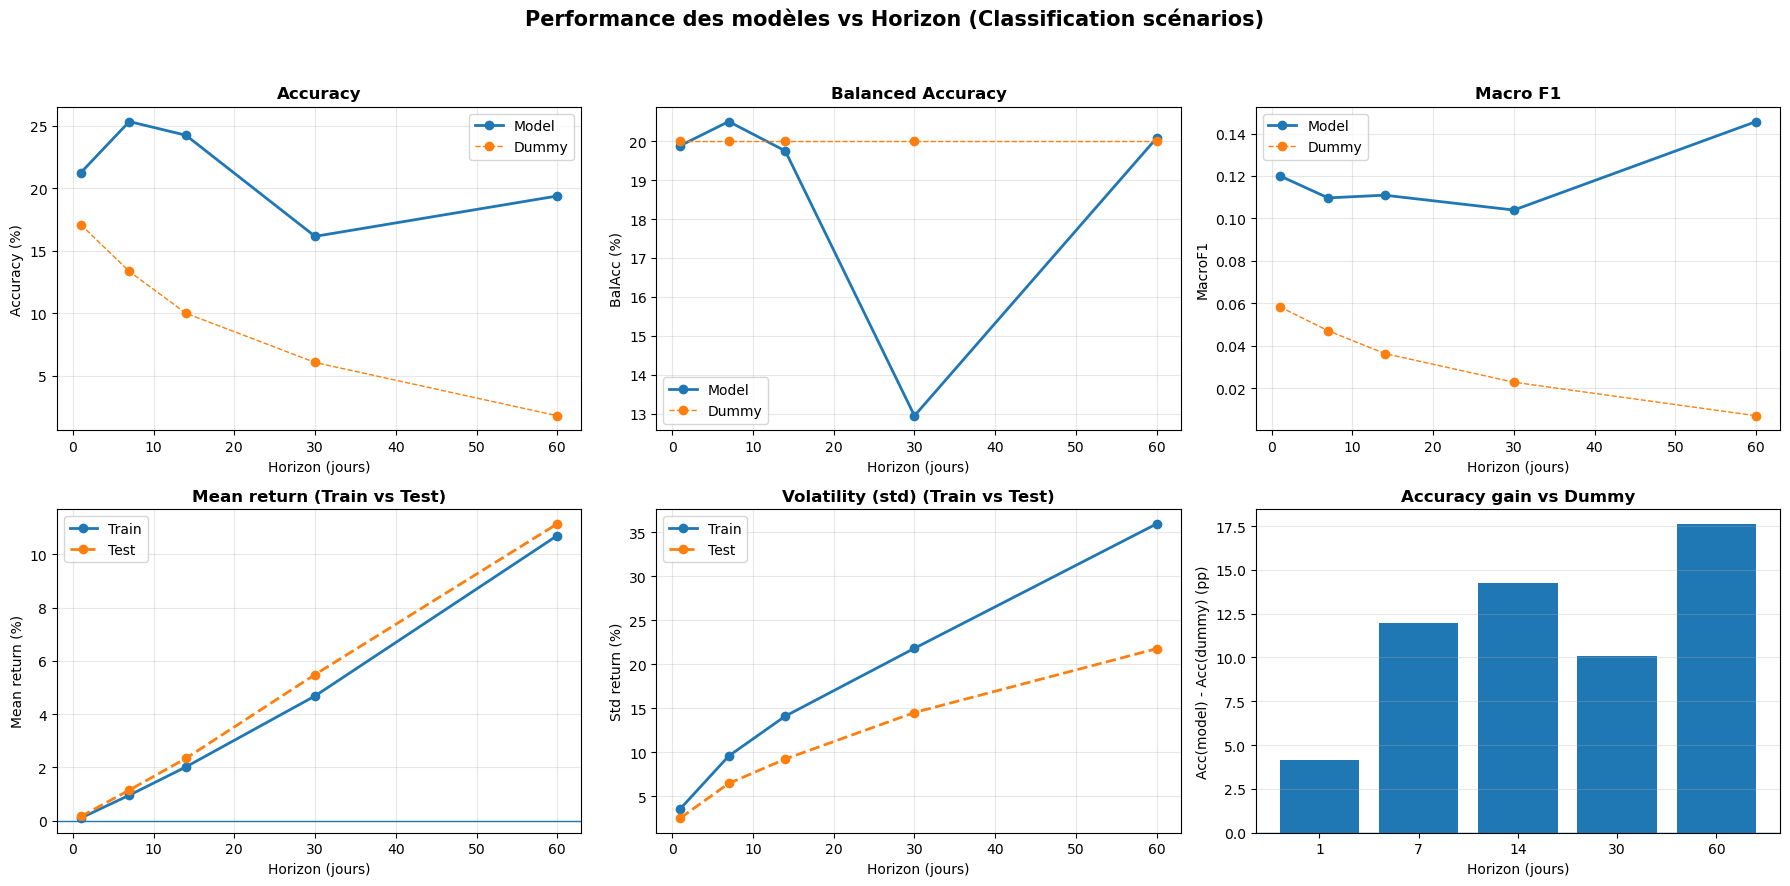

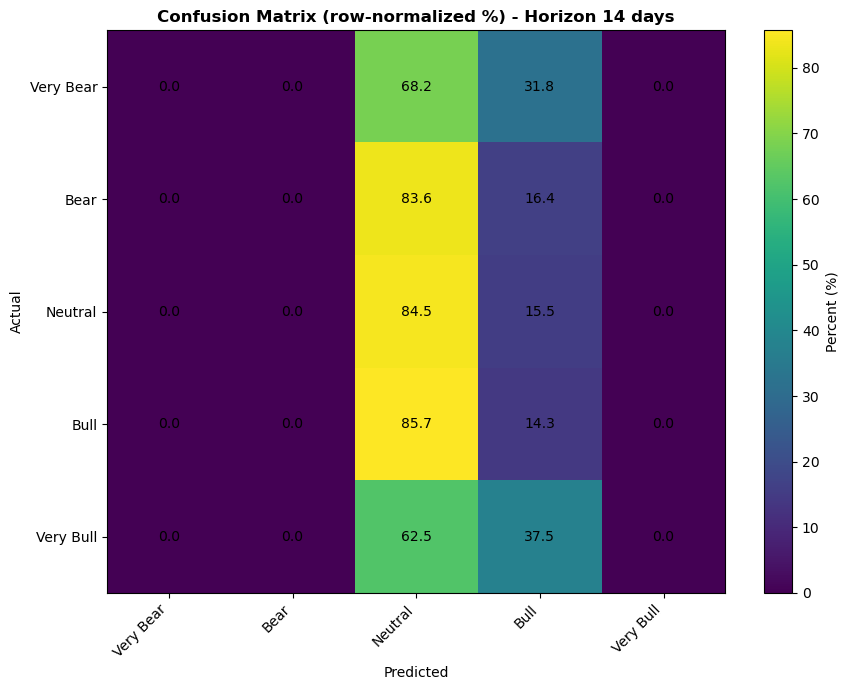

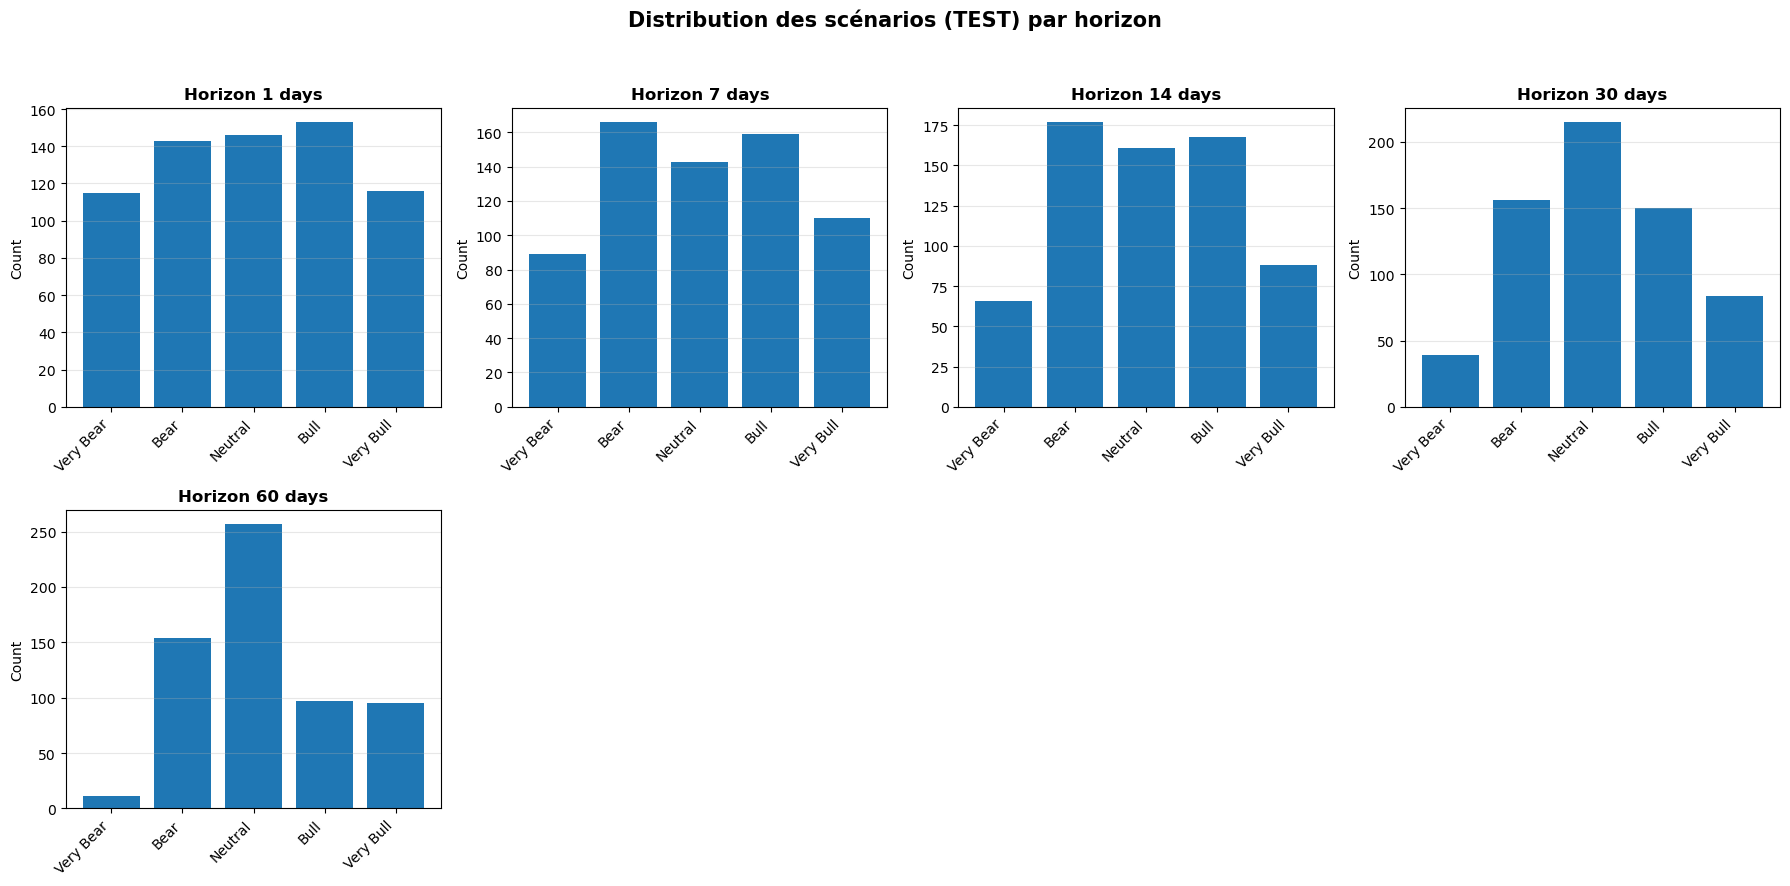

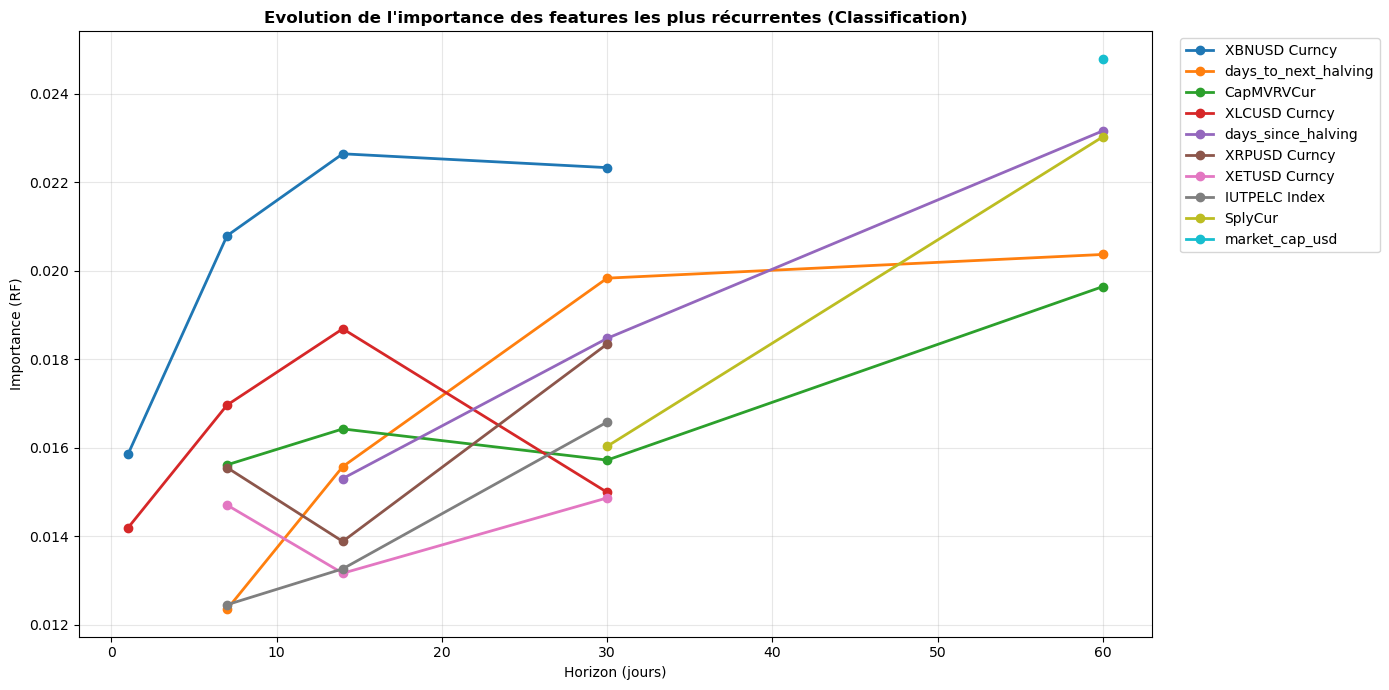

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# VISUALISATIONS (COMPATIBLES AVEC TON NOUVEAU CODE leak-free)
# - all_results : liste de dicts renvoyés par evaluate_horizon_classification_leakfree()
# - feature_tracker : defaultdict(list) rempli dans la boucle (feature -> [(horizon, imp), ...])
# ============================================================

print("="*80)
print(" GENERATION DES VISUALISATIONS (NEW PIPELINE)")
print("="*80)

# Sécurité
if "all_results" not in globals() or len(all_results) == 0:
    raise ValueError("all_results est vide ou non défini. Lance d'abord l'exécution multi-horizons.")
if "feature_tracker" not in globals():
    feature_tracker = None  # certaines figures seront désactivées

# Tri par horizon
all_results_sorted = sorted(all_results, key=lambda r: r["horizon"])

horizons = [r["horizon"] for r in all_results_sorted]
acc = [r["acc"] * 100 for r in all_results_sorted]
bal_acc = [r["bal_acc"] * 100 for r in all_results_sorted]
macro_f1 = [r["macro_f1"] for r in all_results_sorted]
dummy_acc = [r["dummy_acc"] * 100 for r in all_results_sorted]
dummy_bal_acc = [r["dummy_bal_acc"] * 100 for r in all_results_sorted]
dummy_macro_f1 = [r["dummy_macro_f1"] for r in all_results_sorted]

# Returns stats (train/test séparées)
train_mean = [r["ret_stats_train"]["mean"] * 100 for r in all_results_sorted]
train_std = [r["ret_stats_train"]["std"] * 100 for r in all_results_sorted]
test_mean = [r["ret_stats_test"]["mean"] * 100 for r in all_results_sorted]
test_std = [r["ret_stats_test"]["std"] * 100 for r in all_results_sorted]

# ============================================================
# FIGURE 1 : PERFORMANCE VS HORIZON (CLASSIFICATION ONLY)
# ============================================================

fig1, axes = plt.subplots(2, 3, figsize=(18, 9))
fig1.suptitle("Performance des modèles vs Horizon (Classification scénarios)", fontsize=15, fontweight="bold")

# 1) Accuracy
axes[0, 0].plot(horizons, acc, marker="o", linewidth=2)
axes[0, 0].plot(horizons, dummy_acc, marker="o", linewidth=1, linestyle="--")
axes[0, 0].set_title("Accuracy", fontweight="bold")
axes[0, 0].set_xlabel("Horizon (jours)")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(["Model", "Dummy"], loc="best")

# 2) Balanced Accuracy
axes[0, 1].plot(horizons, bal_acc, marker="o", linewidth=2)
axes[0, 1].plot(horizons, dummy_bal_acc, marker="o", linewidth=1, linestyle="--")
axes[0, 1].set_title("Balanced Accuracy", fontweight="bold")
axes[0, 1].set_xlabel("Horizon (jours)")
axes[0, 1].set_ylabel("BalAcc (%)")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(["Model", "Dummy"], loc="best")

# 3) Macro F1
axes[0, 2].plot(horizons, macro_f1, marker="o", linewidth=2)
axes[0, 2].plot(horizons, dummy_macro_f1, marker="o", linewidth=1, linestyle="--")
axes[0, 2].set_title("Macro F1", fontweight="bold")
axes[0, 2].set_xlabel("Horizon (jours)")
axes[0, 2].set_ylabel("MacroF1")
axes[0, 2].grid(alpha=0.3)
axes[0, 2].legend(["Model", "Dummy"], loc="best")

# 4) Mean return train vs test
axes[1, 0].plot(horizons, train_mean, marker="o", linewidth=2)
axes[1, 0].plot(horizons, test_mean, marker="o", linewidth=2, linestyle="--")
axes[1, 0].axhline(0, linewidth=1)
axes[1, 0].set_title("Mean return (Train vs Test)", fontweight="bold")
axes[1, 0].set_xlabel("Horizon (jours)")
axes[1, 0].set_ylabel("Mean return (%)")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(["Train", "Test"], loc="best")

# 5) Std return train vs test
axes[1, 1].plot(horizons, train_std, marker="o", linewidth=2)
axes[1, 1].plot(horizons, test_std, marker="o", linewidth=2, linestyle="--")
axes[1, 1].set_title("Volatility (std) (Train vs Test)", fontweight="bold")
axes[1, 1].set_xlabel("Horizon (jours)")
axes[1, 1].set_ylabel("Std return (%)")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(["Train", "Test"], loc="best")

# 6) Gap model - dummy
gap = [a - d for a, d in zip(acc, dummy_acc)]
axes[1, 2].bar([str(h) for h in horizons], gap)
axes[1, 2].axhline(0, linewidth=1)
axes[1, 2].set_title("Accuracy gain vs Dummy", fontweight="bold")
axes[1, 2].set_xlabel("Horizon (jours)")
axes[1, 2].set_ylabel("Acc(model) - Acc(dummy) (pp)")
axes[1, 2].grid(alpha=0.3, axis="y")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ============================================================
# HELPER : Confusion matrix plot (matplotlib, normalisée)
# ============================================================

def plot_confusion_matrix_percent(cm, title, class_names):
    cm = np.asarray(cm)
    # normalisation par ligne
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_pct = cm / row_sums * 100.0

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_pct, aspect="auto")

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    # annotations
    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            ax.text(j, i, f"{cm_pct[i, j]:.1f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, label="Percent (%)")
    ax.grid(False)
    plt.tight_layout()
    return fig, ax

# ============================================================
# FIGURE 2 : MATRICE DE CONFUSION (choix horizon)
# - Ton nouveau code n'a PAS 7 jours dans HORIZONS, donc on prend 14 par défaut si dispo,
#   sinon le premier horizon.
# ============================================================

scenario_names = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

preferred_h = 14 if any(r["horizon"] == 14 for r in all_results_sorted) else all_results_sorted[0]["horizon"]
res_h = next(r for r in all_results_sorted if r["horizon"] == preferred_h)

plot_confusion_matrix_percent(
    res_h["cm"],
    title=f"Confusion Matrix (row-normalized %) - Horizon {preferred_h} days",
    class_names=scenario_names
)

# ============================================================
# FIGURE 3 : DISTRIBUTION DES SCENARIOS (TEST) PAR HORIZON
# ============================================================

n = len(all_results_sorted)
cols = 4
rows = int(np.ceil(n / cols))
fig3, axes = plt.subplots(rows, cols, figsize=(18, 4.5 * rows))
fig3.suptitle("Distribution des scénarios (TEST) par horizon", fontsize=15, fontweight="bold")

axes = np.array(axes).reshape(-1)

for i, res in enumerate(all_results_sorted):
    ax = axes[i]
    dist = res["dist_test"]
    full_dist = pd.Series([0]*5, index=range(5), dtype=float)
    for k, v in dist.items():
        full_dist[int(k)] = float(v)

    ax.bar(range(5), full_dist.values)
    ax.set_title(f"Horizon {res['horizon']} days", fontweight="bold")
    ax.set_xticks(range(5))
    ax.set_xticklabels(scenario_names, rotation=45, ha="right")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3, axis="y")

# hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ============================================================
# FIGURE 4 : EVOLUTION DES TOP FEATURES (classification)
# - basé sur feature_tracker (top récurrentes)
# ============================================================

if feature_tracker is not None and len(feature_tracker) > 0:
    # score de récurrence + importance moyenne
    feat_summary = []
    for feat, vals in feature_tracker.items():
        hs = [h for h, _ in vals]
        imps = [imp for _, imp in vals]
        feat_summary.append({
            "feature": feat,
            "count": len(set(hs)),
            "avg_imp": float(np.mean(imps))
        })
    feat_summary = pd.DataFrame(feat_summary).sort_values(["count", "avg_imp"], ascending=[False, False])

    top_feats = feat_summary.head(10)["feature"].tolist()

    fig4, ax = plt.subplots(figsize=(14, 7))
    for feat in top_feats:
        vals = sorted(feature_tracker[feat], key=lambda x: x[0])
        hs = [h for h, _ in vals]
        imps = [imp for _, imp in vals]
        ax.plot(hs, imps, marker="o", linewidth=2, label=feat)

    ax.set_title("Evolution de l'importance des features les plus récurrentes (Classification)", fontweight="bold")
    ax.set_xlabel("Horizon (jours)")
    ax.set_ylabel("Importance (RF)")
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
else:
    print("feature_tracker non disponible -> Figure 4 ignorée.")

print("\n" + "="*80)
print(" TOUTES LES VISUALISATIONS ONT ETE GENEREES")
print("="*80)


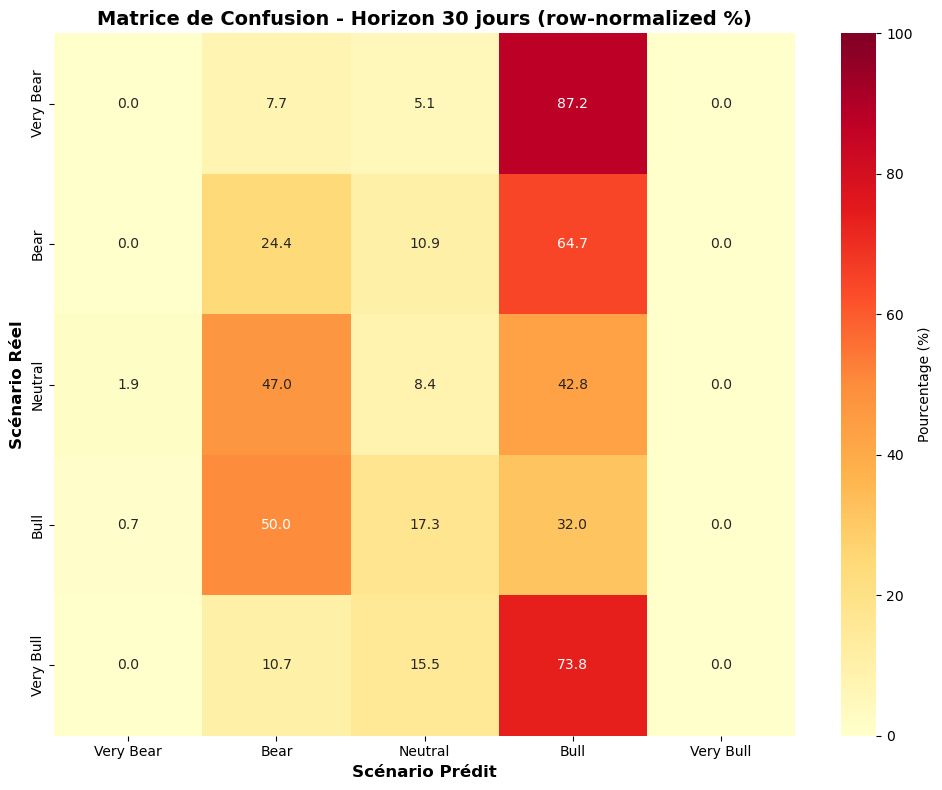


Matrice brute (counts):
[[  0   3   2  34   0]
 [  0  38  17 101   0]
 [  4 101  18  92   0]
 [  1  75  26  48   0]
 [  0   9  13  62   0]]

Accuracy (from cm): 16.1%
Accuracy (from res['acc']): 16.1%
Balanced Accuracy (res['bal_acc']): 12.9%
Macro F1 (res['macro_f1']): 0.104


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Choisis l'horizon que tu veux voir
horizon_choisi = 30  # ex: 1, 14, 30, 60

# Trouve les résultats pour cet horizon
res = next((r for r in all_results if r["horizon"] == horizon_choisi), None)

if res is not None:
    # Récupère la matrice de confusion (dans ton nouveau code: clé = "cm")
    cm = np.array(res["cm"])

    # Noms des scénarios
    scenario_names = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

    # Normalise par ligne (pourcentage par classe réelle)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # évite division par 0 si une classe est absente
    cm_normalized = cm / row_sums * 100

    # Crée la figure
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        xticklabels=scenario_names,
        yticklabels=scenario_names,
        cbar_kws={"label": "Pourcentage (%)"},
        vmin=0,
        vmax=100
    )

    plt.xlabel("Scénario Prédit", fontsize=12, fontweight="bold")
    plt.ylabel("Scénario Réel", fontsize=12, fontweight="bold")
    plt.title(
        f"Matrice de Confusion - Horizon {horizon_choisi} jours (row-normalized %)",
        fontsize=14,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # Matrice brute
    print("\nMatrice brute (counts):")
    print(cm)

    # Accuracy (tu peux aussi juste afficher res['acc'])
    accuracy = np.trace(cm) / np.sum(cm) * 100 if np.sum(cm) > 0 else 0.0
    print(f"\nAccuracy (from cm): {accuracy:.1f}%")
    print(f"Accuracy (from res['acc']): {res['acc']*100:.1f}%")
    print(f"Balanced Accuracy (res['bal_acc']): {res['bal_acc']*100:.1f}%")
    print(f"Macro F1 (res['macro_f1']): {res['macro_f1']:.3f}")

else:
    print(f"Pas de résultats pour horizon {horizon_choisi}j. Horizons dispo: {[r['horizon'] for r in all_results]}")


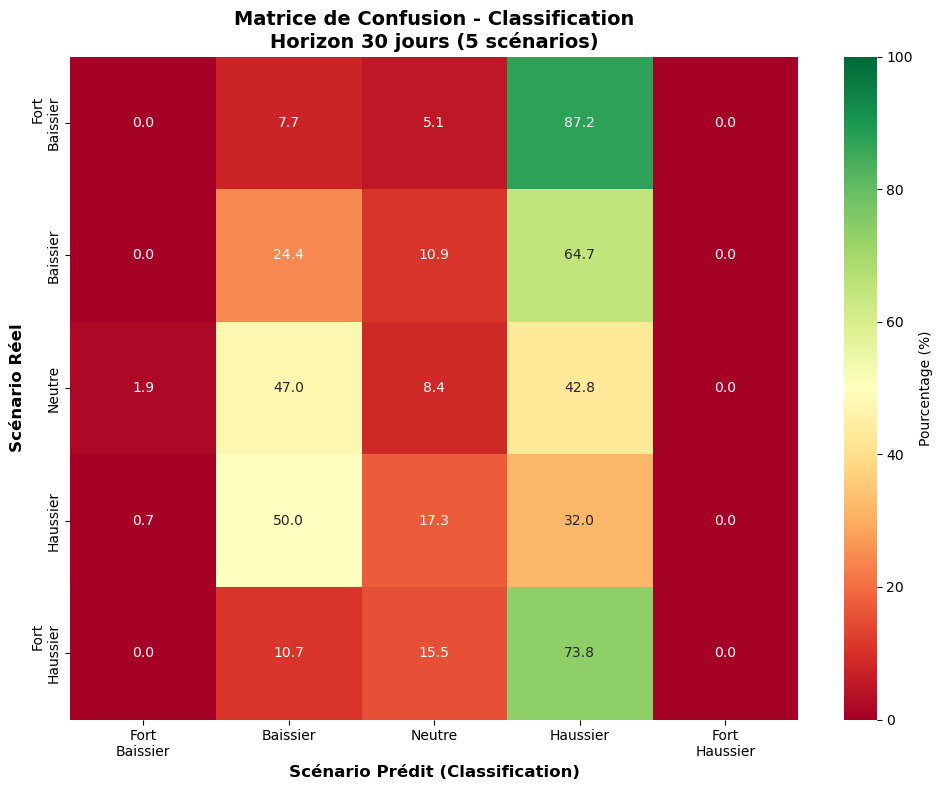


Accuracy (from cm): 16.1%
Accuracy (res['acc']): 16.1%
Balanced Accuracy (res['bal_acc']): 12.9%
Macro F1 (res['macro_f1']): 0.104
Nombre total d'échantillons: 644

Distribution des PRÉDICTIONS:
  Fort Baissier: 5 (0.8%)
  Baissier: 226 (35.1%)
  Neutre: 76 (11.8%)
  Haussier: 337 (52.3%)
  Fort Haussier: 0 (0.0%)

Distribution des RÉALITÉS:
  Fort Baissier: 39 (6.1%)
  Baissier: 156 (24.2%)
  Neutre: 215 (33.4%)
  Haussier: 150 (23.3%)
  Fort Haussier: 84 (13.0%)


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Choisis ton horizon
horizon_choisi = 30  # 1, 14, 30, 60

# Trouve les résultats
res = next((r for r in all_results if r["horizon"] == horizon_choisi), None)

if res is None:
    print(f"Pas de résultats pour horizon {horizon_choisi}j. Horizons dispo: {[r['horizon'] for r in all_results]}")
else:
    # Dans ton nouveau code leak-free: la clé s'appelle "cm"
    cm = np.array(res["cm"])

    # Noms fixes (toujours 5 scénarios)
    scenario_names = ["Fort Baissier", "Baissier", "Neutre", "Haussier", "Fort Haussier"]
    scenario_names_plot = [s.replace(" ", "\n") for s in scenario_names]

    # Normalisation par ligne (% par classe réelle)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # évite division par 0 si classe absente
    cm_normalized = cm / row_sums * 100

    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        xticklabels=scenario_names_plot,
        yticklabels=scenario_names_plot,
        cbar_kws={"label": "Pourcentage (%)"},
        vmin=0, vmax=100
    )

    plt.xlabel("Scénario Prédit (Classification)", fontsize=12, fontweight="bold")
    plt.ylabel("Scénario Réel", fontsize=12, fontweight="bold")
    plt.title(f"Matrice de Confusion - Classification\nHorizon {horizon_choisi} jours (5 scénarios)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Stats cohérentes
    total = cm.sum()
    accuracy_from_cm = (np.trace(cm) / total * 100) if total > 0 else 0.0

    print(f"\nAccuracy (from cm): {accuracy_from_cm:.1f}%")
    print(f"Accuracy (res['acc']): {res['acc']*100:.1f}%")
    print(f"Balanced Accuracy (res['bal_acc']): {res['bal_acc']*100:.1f}%")
    print(f"Macro F1 (res['macro_f1']): {res['macro_f1']:.3f}")
    print(f"Nombre total d'échantillons: {int(total)}")

    # Distribution prédictions
    print("\nDistribution des PRÉDICTIONS:")
    pred_dist = cm.sum(axis=0)
    for i, v in enumerate(pred_dist):
        pct = (v / pred_dist.sum() * 100) if pred_dist.sum() > 0 else 0.0
        print(f"  {scenario_names[i]}: {int(v)} ({pct:.1f}%)")

    # Distribution réalités
    print("\nDistribution des RÉALITÉS:")
    real_dist = cm.sum(axis=1)
    for i, v in enumerate(real_dist):
        pct = (v / real_dist.sum() * 100) if real_dist.sum() > 0 else 0.0
        print(f"  {scenario_names[i]}: {int(v)} ({pct:.1f}%)")

    # Classes absentes (réel)
    absent_real = [scenario_names[i] for i in range(5) if real_dist[i] == 0]
    if absent_real:
        print("\nScénarios ABSENTS du test set (en réel):")
        for m in absent_real:
            print(f"  - {m}")


## Scénarios de rendement MEAN/STD 
En complément de l’approche par quantiles, nous considérons une définition alternative des
scénarios de rendement fondée sur la **moyenne et l’écart-type des rendements futurs**.

Pour un horizon donné, les rendements futurs du Bitcoin sont classés en cinq scénarios selon
leur écart à la moyenne observée sur la période d’entraînement :

- Very Bear : rendement < μ − 1σ  
- Bear : μ − 1σ ≤ rendement < μ − 0.5σ  
- Neutral : μ − 0.5σ ≤ rendement ≤ μ + 0.5σ  
- Bull : μ + 0.5σ < rendement ≤ μ + 1σ  
- Very Bull : rendement > μ + 1σ  

Les paramètres μ (moyenne) et σ (écart-type) sont **calculés exclusivement sur le jeu
d’entraînement**, puis appliqués au jeu de test, afin de garantir l’absence de fuite
d’information.

Cette approche permet d’interpréter les scénarios comme des **déviations absolues autour
d’un régime moyen**, mais peut conduire à des classes déséquilibrées dans le cas de
distributions asymétriques ou à queues épaisses, comme c’est le cas pour les rendements
financiers.

In [37]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"

SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type="simple"):
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    else:
        return np.log(future_price / prices)

# ============================================================
# SCENARIOS: MEAN / STD (TRAIN ONLY)
# ============================================================

def fit_mean_std_thresholds(train_returns: pd.Series):
    x = train_returns.dropna()
    if len(x) < 50:
        raise ValueError("Not enough data for mean/std")
    return {"mu": float(x.mean()), "sigma": float(x.std())}

def apply_mean_std_scenarios(returns: pd.Series, thresholds: dict):
    mu, sigma = thresholds["mu"], thresholds["sigma"]
    s = pd.Series(index=returns.index, dtype="Int64")

    s[returns < mu - 1.0 * sigma] = 0
    s[(returns >= mu - 1.0 * sigma) & (returns < mu - 0.5 * sigma)] = 1
    s[(returns >= mu - 0.5 * sigma) & (returns <= mu + 0.5 * sigma)] = 2
    s[(returns > mu + 0.5 * sigma) & (returns <= mu + 1.0 * sigma)] = 3
    s[returns > mu + 1.0 * sigma] = 4

    return s

# ============================================================
# EVALUATION FUNCTION (LEAKAGE-FREE, DATE SPLIT)
# ============================================================

def evaluate_horizon_mean_std(
    pivot_df: pd.DataFrame,
    horizon: int
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= START_DATE]

    btc_col = "XBTUSD Curncy" if "XBTUSD Curncy" in df.columns else "XBTUSD"

    # ---------- Features ----------
    df_feat = df.ffill()
    thresh = int(MIN_NON_NA_FRAC * len(df_feat))
    df_feat = df_feat.dropna(axis=1, thresh=thresh)

    # ---------- Target ----------
    returns = calculate_returns(df[btc_col], horizon, RETURN_TYPE)

    df_model = df_feat.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS:
        return None

    # ---------- Date split ----------
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X = df_model.drop(columns=["target_return"])
    y = df_model["target_return"]

    # Remove BTC level
    if btc_col in X.columns:
        X = X.drop(columns=[btc_col])

    # Split
    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train_ret, y_test_ret = y.loc[train_mask], y.loc[test_mask]

    # ---------- Scenarios (train only) ----------
    thresholds = fit_mean_std_thresholds(y_train_ret)
    y_train = apply_mean_std_scenarios(y_train_ret, thresholds).dropna().astype(int)
    y_test = apply_mean_std_scenarios(y_test_ret, thresholds).dropna().astype(int)

    X_train = X_train.loc[y_train.index]
    X_test = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # ---------- Scaling ----------
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # ---------- Model ----------
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    # ---------- Metrics ----------
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred, labels=range(5))

    # ---------- Feature importance ----------
    imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp) + 1)

    return {
        "horizon": horizon,
        "n_train": len(y_train),
        "n_test": len(y_test),
        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,
        "imp_full": imp,
        "top_features": imp.head(10)
    }

# ============================================================
# RUN MULTI-HORIZONS
# ============================================================

print("=" * 95)
print("BTC SCENARIO CLASSIFICATION — MEAN / STD (LEAKAGE-FREE, DATE SPLIT)")
print(f"Train ≤ {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print(f"\n{'='*95}\nHorizon = {h} days\n{'='*95}")
    res = evaluate_horizon_mean_std(pivot_df, h)

    if res is None:
        print("Not enough data.")
        continue

    all_results.append(res)

    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print("\nTop 10 features:")
    print(res["top_features"][["rank","feature","importance"]].to_string(index=False))

    for _, r in res["top_features"].iterrows():
        feature_tracker[r["feature"]].append((h, r["importance"]))

# ============================================================
# SUMMARY
# ============================================================

summary = pd.DataFrame([{
    "Horizon": r["horizon"],
    "Train N": r["n_train"],
    "Test N": r["n_test"],
    "Accuracy (%)": r["acc"] * 100,
    "Balanced Acc (%)": r["bal_acc"] * 100,
    "Macro F1": r["macro_f1"]
} for r in all_results])

print("\n" + "="*95)
print("SUMMARY")
print("="*95)
print(summary.to_string(index=False))


BTC SCENARIO CLASSIFICATION — MEAN / STD (LEAKAGE-FREE, DATE SPLIT)
Train ≤ 2023-12-31 | Test > 2023-12-31

Horizon = 1 days
Train=1938 | Test=673
Acc=62.3% | BalAcc=20.2% | MacroF1=0.159

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.017593
    2 active_addr_ratio    0.017041
    3            BlkCnt    0.015452
    4     tx_per_second    0.015410
    5               NVT    0.015121
    6    mempool_growth    0.014945
    7     XBNUSD Curncy    0.014296
    8     XLCUSD Curncy    0.013747
    9          TxTfrCnt    0.013470
   10        NVT_Signal    0.013459

Horizon = 14 days
Train=2035 | Test=660
Acc=58.8% | BalAcc=20.0% | MacroF1=0.148

Top 10 features:
 rank              feature  importance
    1        XBNUSD Curncy    0.020477
    2        XETUSD Curncy    0.015679
    3           CapMVRVCur    0.015664
    4        XLCUSD Curncy    0.015633
    5 days_to_next_halving    0.015013
    6   days_since_halving    0.014795
    7       CPI XYOY Inde

## Loi de student
Dans cette approche, les rendements futurs du Bitcoin sont modélisés à l’aide d’une loi de Student afin de définir les différents scénarios de marché. La loi de Student est particulièrement adaptée aux séries financières car elle permet de mieux capturer les événements extrêmes (queues épaisses) que la loi normale. Les paramètres de la loi (degrés de liberté, moyenne et écart-type) sont estimés uniquement sur l’échantillon d’entraînement afin d’éviter toute fuite d’information. Les scénarios (« Very Bear » à « Very Bull ») sont ensuite définis à partir des quantiles théoriques de cette distribution ajustée, garantissant une classification robuste et cohérente face à la volatilité élevée des rendements financiers.

In [38]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

from scipy.stats import t as student_t  # Student-t distribution

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"   # train <= this date, test > this date

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"          # "simple" or "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70          # after ffill
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Student-t thresholds: equal-probability bins (same as quantiles, but from fitted Student-t)
# 5 bins -> probabilities [0, 0.2, 0.4, 0.6, 0.8, 1]
BIN_PROBS = np.linspace(0, 1, N_BINS + 1)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)

    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# STUDENT-T BINNING (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_student_t_bins(train_returns: pd.Series, probs: np.ndarray) -> dict:
    """
    Fit a Student-t distribution on TRAIN returns only, then compute bin edges
    using the fitted distribution's quantiles.

    Returns a dict containing:
      - df, loc, scale (fitted params)
      - edges (np.ndarray) of length N_BINS+1 with [-inf, ..., +inf]
    """
    x = train_returns.dropna().astype(float).values
    if len(x) < 200:
        raise ValueError("Not enough training returns to fit Student-t robustly (need ~200+).")

    # Fit Student-t: returns df, loc, scale (MLE)
    df_hat, loc_hat, scale_hat = student_t.fit(x)

    # Compute edges from fitted distribution quantiles
    edges = student_t.ppf(probs, df_hat, loc=loc_hat, scale=scale_hat)
    edges[0], edges[-1] = -np.inf, np.inf

    # Guard against numerical non-monotonicity
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = edges[i - 1] + 1e-12

    return {"df": df_hat, "loc": loc_hat, "scale": scale_hat, "edges": edges}

def apply_bins_from_edges(returns: pd.Series, edges: np.ndarray) -> pd.Series:
    """
    Apply precomputed edges to returns -> labels 0..N_BINS-1
    """
    return pd.cut(returns.astype(float), bins=edges, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# EVALUATION (CLASSIFICATION ONLY, LEAKAGE SAFE, DATE SPLIT)
# ============================================================

def evaluate_horizon_student_t_by_date(
    pivot_df: pd.DataFrame,
    horizon: int,
    return_type: str = "simple",
    train_end_date: str = TRAIN_END_DATE,
    start_date: str = START_DATE
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(start_date)]

    # Detect BTC column
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("BTC column not found (expected 'XBTUSD Curncy' or 'XBTUSD').")

    # ---------- Features: ffill ONLY (NO bfill) ----------
    df_features = df.ffill()

    # Drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # ---------- Target returns ----------
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    # Build model frame (features + target)
    df_model = df_features.copy()
    df_model["target_return"] = returns

    # Remove rows where future target not available
    df_model = df_model.dropna(subset=["target_return"])
    if len(df_model) < MIN_ROWS:
        return None

    # Date split
    cut = pd.to_datetime(train_end_date)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut

    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # Safety: remove return-like engineered columns if they exist
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()],
        errors="ignore"
    )

    # Remove BTC level column exactly
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # Split
    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # ---------- Student-t bins fitted on TRAIN ONLY ----------
    tfit = fit_student_t_bins(y_ret_train, BIN_PROBS)
    edges = tfit["edges"]

    y_train = apply_bins_from_edges(y_ret_train, edges).dropna().astype(int)
    y_test  = apply_bins_from_edges(y_ret_test, edges).dropna().astype(int)

    # Align X with y indices (in case of dropped rows)
    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    # Scaling (fit train only)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Model
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Metrics
    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # Feature importances (full)
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # Return stats
    ret_stats_train = {"mean": float(y_ret_train.mean()), "std": float(y_ret_train.std())}
    ret_stats_test  = {"mean": float(y_ret_test.mean()),  "std": float(y_ret_test.std())}

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": str(train_end_date),

        # Student-t params for reporting
        "student_t_df": float(tfit["df"]),
        "student_t_loc": float(tfit["loc"]),
        "student_t_scale": float(tfit["scale"]),
        "student_t_edges": edges,

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "ret_stats_train": ret_stats_train,
        "ret_stats_test": ret_stats_test
    }

# ============================================================
# RUN MULTI-HORIZONS + SUMMARY
# ============================================================

print("=" * 110)
print("MULTI-HORIZON BTC SCENARIO CLASSIFICATION (Student-t bins, leakage-free, DATE SPLIT)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print("Bins: fitted Student-t on TRAIN returns, then 0/20/40/60/80/100% thresholds from fitted distribution")
print("=" * 110)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 110)
    print(f"Horizon = {h} days")
    print("=" * 110)

    res = evaluate_horizon_student_t_by_date(
        pivot_df,
        horizon=h,
        return_type=RETURN_TYPE,
        train_end_date=TRAIN_END_DATE,
        start_date=START_DATE
    )

    if res is None:
        print("-> Not enough data / too few usable features with this date split.")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Student-t fit (train): df={res['student_t_df']:.2f}, loc={res['student_t_loc']:.6f}, scale={res['student_t_scale']:.6f}")
    print("Student-t bin edges:", np.round(res["student_t_edges"], 6))
    print(f"Train N={res['n_train']} | Test N={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")

    print("\nTop 10 features:")
    print(res["top_features"][["rank","feature","importance"]].to_string(index=False))

    for _, row in res["imp_full"].head(10).iterrows():
        feature_tracker[row["feature"]].append((h, float(row["importance"])))

if all_results:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "t_df": r["student_t_df"],
        "t_loc": r["student_t_loc"],
        "t_scale": r["student_t_scale"],
        "Train mean ret": r["ret_stats_train"]["mean"],
        "Train std ret": r["ret_stats_train"]["std"],
        "Test mean ret": r["ret_stats_test"]["mean"],
        "Test std ret": r["ret_stats_test"]["std"],
    } for r in all_results]).sort_values("Horizon (d)")

    print("\n" + "=" * 110)
    print("SUMMARY")
    print("=" * 110)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 110)
    print("MOST RECURRENT FEATURES (top-20 across horizons, from top-10 each horizon)")
    print("=" * 110)

    feat_counts = {feat: len(v) for feat, v in feature_tracker.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:20]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")
else:
    print("No results (all horizons failed).")

# ============================================================
# OPTIONAL: check ranks for specific features (RIOT, DXY)
# Example:
# r = all_results[0]
# r["imp_full"][r["imp_full"]["feature"].str.contains("RIOT|DXY", case=False, na=False)][["rank","feature","importance"]]
# ============================================================


MULTI-HORIZON BTC SCENARIO CLASSIFICATION (Student-t bins, leakage-free, DATE SPLIT)
Train <= 2023-12-31 | Test > 2023-12-31
Bins: fitted Student-t on TRAIN returns, then 0/20/40/60/80/100% thresholds from fitted distribution

Horizon = 1 days
BTC col used: XBTUSD Curncy
Student-t fit (train): df=2.27, loc=0.000746, scale=0.019570
Student-t bin edges: [     -inf -0.019424 -0.004821  0.006312  0.020915       inf]
Train N=1938 | Test N=673
Acc=23.3% | BalAcc=20.6% | MacroF1=0.129

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.019956
    2 active_addr_ratio    0.018267
    3            BlkCnt    0.016764
    4          TxTfrCnt    0.015918
    5     XLCUSD Curncy    0.015612
    6               NVT    0.014738
    7         AdrActCnt    0.014577
    8     XBNUSD Curncy    0.014535
    9    mempool_growth    0.013840
   10             TxCnt    0.013833

Horizon = 14 days
BTC col used: XBTUSD Curncy
Student-t fit (train): df=4.09, loc=0.011845, scale=0.10

## Loi de Pareto
Cette approche s’appuie sur la loi de Pareto pour modéliser spécifiquement les rendements extrêmes du Bitcoin, c’est-à-dire les variations les plus fortes à la hausse ou à la baisse. La loi de Pareto est utilisée uniquement sur les queues de la distribution, au-delà d’un seuil élevé défini sur les données d’entraînement. Les rendements extrêmes positifs et négatifs sont ainsi traités séparément, tandis que la partie centrale de la distribution est conservée telle quelle. Cette méthode permet de mieux caractériser les phases de marché rares mais économiquement significatives, en mettant l’accent sur les chocs majeurs plutôt que sur les fluctuations ordinaires.

In [39]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from collections import defaultdict

from scipy.stats import t as student_t
from scipy.stats import pareto

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"   # "simple" or "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS = 300

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

BIN_PROBS = np.linspace(0, 1, N_BINS + 1)  # [0, .2, .4, .6, .8, 1]

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)
    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

def apply_bins_from_edges(returns: pd.Series, edges: np.ndarray) -> pd.Series:
    return pd.cut(returns.astype(float), bins=edges, labels=False, include_lowest=True).astype("Int64")

def _monotone_edges(edges: np.ndarray) -> np.ndarray:
    edges = edges.astype(float).copy()
    edges[0], edges[-1] = -np.inf, np.inf
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + 1e-12
    return edges

# ============================================================
# STUDENT-T BINS (TRAIN ONLY)
# ============================================================

def fit_student_t_edges(train_returns: pd.Series, probs: np.ndarray) -> dict:
    x = train_returns.dropna().astype(float).values
    if len(x) < 200:
        raise ValueError("Not enough training returns to fit Student-t robustly (need ~200+).")
    df_hat, loc_hat, scale_hat = student_t.fit(x)
    edges = student_t.ppf(probs, df_hat, loc=loc_hat, scale=scale_hat)
    edges = _monotone_edges(edges)
    return {"method": "student_t", "df": df_hat, "loc": loc_hat, "scale": scale_hat, "edges": edges}

# ============================================================
# PARETO TAIL BINS (TRAIN ONLY)
#   - central bins from empirical quantiles (q20,q40,q60,q80)
#   - replace extreme tails using fitted Pareto on:
#       upper tail: (r - u_high) for r >= u_high
#       lower tail: (-r - u_low) for r <= -u_low_threshold (i.e. very negative)
# ============================================================

def fit_pareto_tail_edges(train_returns: pd.Series,
                          probs: np.ndarray,
                          tail_u_prob: float = 0.80,
                          min_tail_n: int = 80) -> dict:
    """
    Build 5-bin edges:
      [-inf, edge20, edge40, edge60, edge80, +inf]
    where edge20/40/60/80 come mostly from empirical quantiles,
    but edge20 and edge80 can be "tail-adjusted" using Pareto fitted on tails.

    tail_u_prob = threshold quantile for defining the tail (e.g. 0.80 means top 20% is tail for upper side)
    """
    x = train_returns.dropna().astype(float)
    if len(x) < 500:
        raise ValueError("Not enough training returns to fit Pareto tails robustly (need ~500+).")

    # Base empirical edges (balanced bins on train)
    q_edges = np.quantile(x.values, probs)
    # We'll potentially replace q_edges[1] (20%) and q_edges[4] (80%) using Pareto tail fits.
    # Keep middle edges as empirical:
    edge40 = q_edges[2]
    edge60 = q_edges[3]

    # -------- Upper tail fit --------
    u_high = np.quantile(x.values, tail_u_prob)
    upper = x[x >= u_high]
    upper_excess = (upper - u_high).values  # >=0

    # -------- Lower tail fit (on negative side) --------
    # Define a threshold for large negative moves using symmetric probability (1-tail_u_prob)
    u_low = -np.quantile((-x).values, tail_u_prob)  # negative threshold
    lower = x[x <= u_low]
    lower_excess = ((-lower) - (-u_low)).values  # >=0 (amount beyond threshold)

    # Initialize edges from empirical
    edge20 = q_edges[1]
    edge80 = q_edges[4]

    pareto_params = {}

    # Fit Pareto on upper excess if enough points
    if len(upper_excess) >= min_tail_n and np.all(upper_excess >= 0):
        # pareto.fit returns shape(b), loc, scale; for excess we force loc=0 (more stable)
        b_u, loc_u, scale_u = pareto.fit(upper_excess, floc=0)
        # Replace the 80% threshold using Pareto-implied quantile for p=0.80 within full distribution:
        # Within our scheme, edge80 is just the boundary between bin3 and bin4.
        # But to use tail model, we compute the (tail_u_prob) quantile by definition is u_high,
        # so it doesn't change; instead we can refine the boundary at 80% by choosing u_high itself
        # OR slightly adjust to match the same bin prob. Practical: keep edge80 = u_high (more principled).
        edge80 = float(u_high)
        pareto_params["upper"] = {"b": float(b_u), "scale": float(scale_u), "u": float(u_high), "n": int(len(upper_excess))}
    else:
        pareto_params["upper"] = {"skipped": True, "n": int(len(upper_excess))}

    # Fit Pareto on lower excess if enough points
    if len(lower_excess) >= min_tail_n and np.all(lower_excess >= 0):
        b_l, loc_l, scale_l = pareto.fit(lower_excess, floc=0)
        # Similarly, take edge20 as the lower tail threshold u_low
        edge20 = float(u_low)
        pareto_params["lower"] = {"b": float(b_l), "scale": float(scale_l), "u": float(u_low), "n": int(len(lower_excess))}
    else:
        pareto_params["lower"] = {"skipped": True, "n": int(len(lower_excess))}

    edges = np.array([-np.inf, edge20, edge40, edge60, edge80, np.inf], dtype=float)
    edges = _monotone_edges(edges)

    return {"method": "pareto_tails", "edges": edges, "tail_u_prob": tail_u_prob, "min_tail_n": min_tail_n, "params": pareto_params}

# ============================================================
# CORE EVALUATION (shared)
# ============================================================

def evaluate_horizon_by_date_with_edges(
    pivot_df: pd.DataFrame,
    horizon: int,
    edges_fitter,                 # function(train_returns)-> dict with "edges"
    return_type: str = "simple",
    train_end_date: str = TRAIN_END_DATE,
    start_date: str = START_DATE
):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(start_date)]

    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("BTC column not found (expected 'XBTUSD Curncy' or 'XBTUSD').")

    # Features: ffill only
    df_features = df.ffill()
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    df_model = df_features.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])
    if len(df_model) < MIN_ROWS:
        return None

    cut = pd.to_datetime(train_end_date)
    train_mask = df_model.index <= cut
    test_mask = df_model.index > cut
    if train_mask.sum() < MIN_ROWS or test_mask.sum() < 50:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # safety removals
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()],
        errors="ignore"
    )
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    X_train = X_full.loc[train_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # Fit edges on train only
    fit_info = edges_fitter(y_ret_train)
    edges = fit_info["edges"]

    y_train = apply_bins_from_edges(y_ret_train, edges).dropna().astype(int)
    y_test  = apply_bins_from_edges(y_ret_test, edges).dropna().astype(int)

    X_train = X_train.loc[y_train.index]
    X_test  = X_test.loc[y_test.index]
    if X_train.shape[1] < 5:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    return {
        "method": fit_info.get("method", "custom"),
        "fit_info": fit_info,
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": str(train_end_date),

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "train_mean_ret": float(y_ret_train.mean()),
        "train_std_ret": float(y_ret_train.std()),
        "test_mean_ret": float(y_ret_test.mean()),
        "test_std_ret": float(y_ret_test.std()),
    }

# ============================================================
# RUN: Student-t then Pareto tails
# ============================================================

def run_experiment(method_name: str, edges_fitter):
    print("\n" + "=" * 120)
    print(f"METHOD = {method_name} | leakage-free | date split train<={TRAIN_END_DATE} test>{TRAIN_END_DATE}")
    print("=" * 120)

    results = []
    feat_track = defaultdict(list)

    for h in HORIZONS:
        print("\n" + "-" * 120)
        print(f"Horizon={h}d")
        print("-" * 120)

        res = evaluate_horizon_by_date_with_edges(
            pivot_df,
            horizon=h,
            edges_fitter=edges_fitter,
            return_type=RETURN_TYPE,
            train_end_date=TRAIN_END_DATE,
            start_date=START_DATE
        )

        if res is None:
            print("-> Not enough data / too few features.")
            continue

        results.append(res)

        print(f"BTC: {res['btc_col_used']} | Train={res['n_train']} | Test={res['n_test']}")
        print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
        print("Edges:", np.round(res["fit_info"]["edges"], 6))

        # Print fit params if available
        if res["method"] == "student_t":
            fi = res["fit_info"]
            print(f"Student-t fit: df={fi['df']:.2f}, loc={fi['loc']:.6f}, scale={fi['scale']:.6f}")
        if res["method"] == "pareto_tails":
            fi = res["fit_info"]
            print("Pareto tails fit info:", fi["params"])

        print("\nTop 10 features:")
        print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))

        for _, row in res["imp_full"].head(10).iterrows():
            feat_track[row["feature"]].append((h, float(row["importance"])))

    if results:
        summary = pd.DataFrame([{
            "Method": r["method"],
            "Horizon(d)": r["horizon"],
            "Train N": r["n_train"],
            "Test N": r["n_test"],
            "Acc(%)": r["acc"]*100,
            "BalAcc(%)": r["bal_acc"]*100,
            "MacroF1": r["macro_f1"],
            "Train mean": r["train_mean_ret"],
            "Train std": r["train_std_ret"],
            "Test mean": r["test_mean_ret"],
            "Test std": r["test_std_ret"],
        } for r in results]).sort_values(["Horizon(d)"])

        print("\n" + "=" * 120)
        print("SUMMARY")
        print("=" * 120)
        print(summary.to_string(index=False))

        print("\n" + "=" * 120)
        print("MOST RECURRENT FEATURES (top-20 across horizons, from top-10 each horizon)")
        print("=" * 120)
        counts = {k: len(v) for k, v in feat_track.items()}
        for feat, c in sorted(counts.items(), key=lambda x: x[1], reverse=True)[:20]:
            horizons_str = ", ".join([f"{h}d" for h, _ in feat_track[feat]])
            avg_imp = float(np.mean([imp for _, imp in feat_track[feat]]))
            print(f"{feat:35s} -> {c}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")

    return results

# Student-t experiment
student_results = run_experiment(
    "Student-t quantile edges (fitted on train)",
    edges_fitter=lambda y_train: fit_student_t_edges(y_train, BIN_PROBS)
)

# Pareto tails experiment
pareto_results = run_experiment(
    "Pareto tails + empirical middle edges (train-only)",
    edges_fitter=lambda y_train: fit_pareto_tail_edges(y_train, BIN_PROBS, tail_u_prob=0.80, min_tail_n=80)
)



METHOD = Student-t quantile edges (fitted on train) | leakage-free | date split train<=2023-12-31 test>2023-12-31

------------------------------------------------------------------------------------------------------------------------
Horizon=1d
------------------------------------------------------------------------------------------------------------------------
BTC: XBTUSD Curncy | Train=1938 | Test=673
Acc=23.3% | BalAcc=20.6% | MacroF1=0.129
Edges: [     -inf -0.019424 -0.004821  0.006312  0.020915       inf]
Student-t fit: df=2.27, loc=0.000746, scale=0.019570

Top 10 features:
 rank           feature  importance
    1   hashrate_7d_pct    0.019956
    2 active_addr_ratio    0.018267
    3            BlkCnt    0.016764
    4          TxTfrCnt    0.015918
    5     XLCUSD Curncy    0.015612
    6               NVT    0.014738
    7         AdrActCnt    0.014577
    8     XBNUSD Curncy    0.014535
    9    mempool_growth    0.013840
   10             TxCnt    0.013833

----------

## 3 scénarios

In [40]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 14, 30, 60]
RETURN_TYPE = "simple"

THRESH_NEUTRAL = 0.01
SCENARIO_NAMES = ["Bear", "Neutral", "Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS_TOTAL = 300
MIN_ROWS_TRAIN = 300
MIN_ROWS_TEST = 50

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

def enrich_features(df):
    df = df.copy()
    if "mempool_count" in df.columns:
        df["mempool_growth"] = df["mempool_count"].pct_change().replace([np.inf, -np.inf], np.nan)
    if "AdrActCnt" in df.columns and "TxCnt" in df.columns:
        df["tx_per_addr"] = df["TxCnt"] / df["AdrActCnt"]
    if "BlkSizeMean" in df.columns and "BlkCnt" in df.columns:
        df["avg_block_size"] = df["BlkSizeMean"] / df["BlkCnt"]
    return df

# ============================================================
# TARGET BINNING (3 classes based on thresholds)
# ============================================================

def binarize_return_thresholds(ret: pd.Series, thresh: float = 0.01) -> pd.Series:
    return pd.cut(ret,
                  bins=[-np.inf, -thresh, thresh, np.inf],
                  labels=[0, 1, 2], include_lowest=True).astype("Int64")

# ============================================================
# MAIN MODELING FUNCTION
# ============================================================

def evaluate_rf_btc_threshold_based(pivot_df: pd.DataFrame, horizon: int, return_type: str = "simple"):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable.")

    df = enrich_features(df)
    df_features = df.ffill()
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)
    df_model = df_features.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS_TOTAL:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    X_full = X_full.drop(columns=[c for c in X_full.columns if "logret" in c.lower() or "logreturn" in c.lower()], errors="ignore")
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS_TRAIN or test_mask.sum() < MIN_ROWS_TEST:
        return None

    X_train = X_full.loc[train_mask].copy()
    X_test = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test = y_ret_full.loc[test_mask].copy()

    y_train = binarize_return_thresholds(y_ret_train, thresh=THRESH_NEUTRAL).dropna().astype(int)
    y_test = binarize_return_thresholds(y_ret_test, thresh=THRESH_NEUTRAL).dropna().astype(int)

    X_train = X_train.loc[y_train.index]
    X_test = X_test.loc[y_test.index]

    if X_train.shape[1] < 5:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(3)))

    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)
    y_dummy = dummy.predict(X_test_scaled)

    dummy_acc = float(accuracy_score(y_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

    imp = pd.DataFrame({"feature": X_train.columns, "importance": clf.feature_importances_})
    imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
    imp["rank"] = np.arange(1, len(imp) + 1)

    dist_test = y_test.value_counts().sort_index()

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,
        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,
        "top_features": imp.head(10),
        "imp_full": imp,
        "dist_test": dist_test
    }

# ============================================================
# MAIN EXECUTION
# ============================================================

print("=" * 95)
print("CLASSIFICATION BTC – 3 SCÉNARIOS (Bear / Neutral / Bull) – SÉPARATION TEMPORALE")
print("=" * 95)

all_results = []
feature_tracker = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_rf_btc_threshold_based(pivot_df, h, return_type=RETURN_TYPE)
    if res is None:
        print("-> Not enough data / features.")
        continue

    all_results.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print(f"Dummy Acc={res['dummy_acc']*100:.1f}% | Dummy BalAcc={res['dummy_bal_acc']*100:.1f}% | Dummy MacroF1={res['dummy_macro_f1']:.3f}")

    print("\nTest Scenario Distribution:")
    total = res["dist_test"].sum()
    for i in range(3):
        name = SCENARIO_NAMES[i]
        val = int(res["dist_test"].get(i, 0))
        print(f"  {i} {name:<8}: {val:4d} ({val/total*100:.1f}%)")

    print("\nTop 10 Features:")
    print(res["top_features"]["rank feature importance".split()].to_string(index=False))

    for _, row in res["top_features"].iterrows():
        feature_tracker[row["feature"]].append((h, row["importance"]))


CLASSIFICATION BTC – 3 SCÉNARIOS (Bear / Neutral / Bull) – SÉPARATION TEMPORALE

Horizon = 1 days
BTC col used: XBTUSD Curncy
Train=1938 | Test=673
Acc=39.2% | BalAcc=33.6% | MacroF1=0.203
Dummy Acc=39.1% | Dummy BalAcc=33.3% | Dummy MacroF1=0.187

Test Scenario Distribution:
  0 Bear    :  195 (29.0%)
  1 Neutral :  263 (39.1%)
  2 Bull    :  215 (31.9%)

Top 10 Features:
 rank           feature  importance
    1   hashrate_7d_pct    0.018346
    2 active_addr_ratio    0.016245
    3     XBNUSD Curncy    0.016093
    4         AdrActCnt    0.015404
    5            BlkCnt    0.015101
    6     tx_per_second    0.015000
    7          TxTfrCnt    0.014517
    8      GJGB3M Index    0.014496
    9          HashRate    0.014414
   10     XLCUSD Curncy    0.013759

Horizon = 14 days
BTC col used: XBTUSD Curncy
Train=2035 | Test=660
Acc=50.9% | BalAcc=33.8% | MacroF1=0.235
Dummy Acc=50.5% | Dummy BalAcc=33.3% | Dummy MacroF1=0.224

Test Scenario Distribution:
  0 Bear    :  248 (37.6%)
  1

## Causalité

In [41]:
pip install dowhy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
print(pivot_df.columns.tolist())

['AdrActCnt', 'BASPTDSP Index', 'BDIY Index', 'BOJDPBAL Index', 'BlkCnt', 'CCMP Index', 'CESICNY Index', 'CESIEUR Index', 'CESIJPY Index', 'CESIUSD Index', 'CFC5QNCN Index', 'CFC5QOIN Index', 'CFC5RCOL Index', 'CFC5RNCN Index', 'CFC5ROIN Index', 'CFC5RTCL Index', 'CFF5QOIN Index', 'CFF5RCON Index', 'CFF5RNCL Index', 'CFF5RNCN Index', 'CFF5RNCS Index', 'CFF5RNRN Index', 'CFF5ROIN Index', 'CFF5RTLL Index', 'CFF5RTLN Index', 'CFF5RTLS Index', 'CHRRDEPC Index', 'CHVAICY Index', 'CIFR US Equity', 'CL1 COMB Comdty', 'CNBMTTAS Index', 'CNCPCRY Index', 'CNH Curncy', 'CNMSM2 Index', 'CNRSCONS Index', 'CO1 COMB Comdty', 'CORZ US Equity', 'CPEXEMUY Index', 'CPI XYOY Index', 'CRY Index', 'CVIX Index', 'CapMVRVCur', 'DEYC2Y10 Index', 'DXY Curncy', 'EBBSTOTA Index', 'ECMAM2 Index', 'EUITEMU Index', 'EURR002W Index', 'EURUSD Curncy', 'European_News_Index', 'FARBAST Index', 'FDTR Index', 'France_News_Index', 'GCNY3M Index', 'GETB1 Index', 'GJGB3M Index', 'Germany_News_Index', 'HashRate', 'IP Index', '

TEST DE CAUSALITÉ DE GRANGER

hashrate_7d_pct -> btc_return_14d
P-values (lags 1 à 7): [np.float64(0.0543), np.float64(0.1553), np.float64(0.2774), np.float64(0.4477), np.float64(0.1721), np.float64(0.0543), np.float64(0.0734)]
-> Pas de causalité de Granger significative (p_min=0.0543)

CapMVRVCur -> btc_return_14d
P-values (lags 1 à 7): [np.float64(0.4051), np.float64(0.0502), np.float64(0.0255), np.float64(0.0282), np.float64(0.0314), np.float64(0.0081), np.float64(0.0135)]
-> Causalité détectée au lag 6 (p=0.0081)

XBNUSD Curncy -> btc_return_14d
P-values (lags 1 à 7): [np.float64(0.0615), np.float64(0.1129), np.float64(0.2978), np.float64(0.3926), np.float64(0.6039), np.float64(0.8855), np.float64(0.749)]
-> Pas de causalité de Granger significative (p_min=0.0615)

days_to_next_halving -> btc_return_14d
P-values (lags 1 à 7): [np.float64(0.6861), np.float64(0.8866), np.float64(0.7128), np.float64(0.7355), np.float64(0.7425), np.float64(0.8301), np.float64(0.8588)]
-> Pas de causal

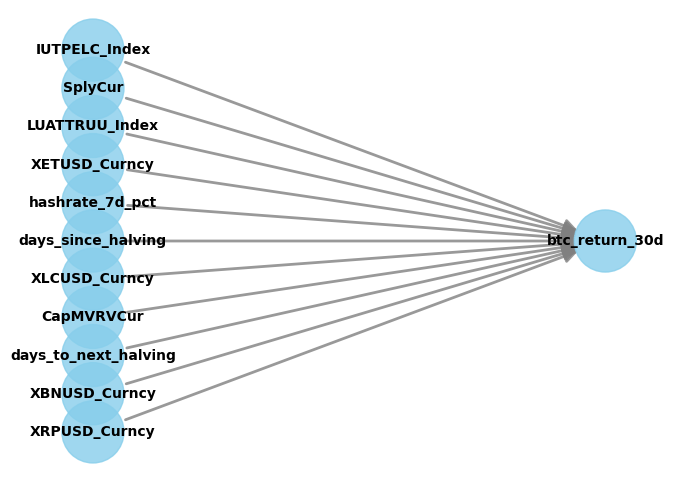

ATE estimé de CapMVRVCur sur btc_return_30d: 0.030633


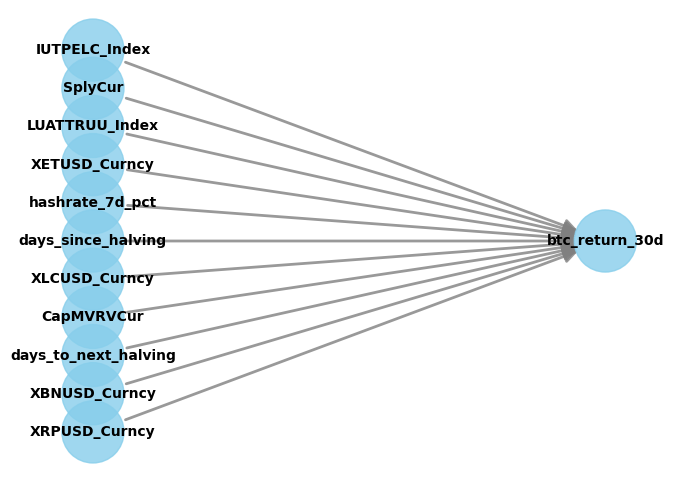

ATE estimé de hashrate_7d_pct sur btc_return_30d: -0.000052


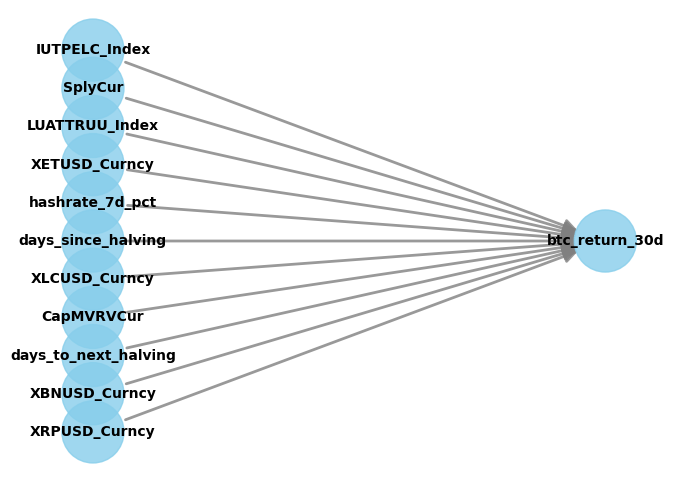

ATE estimé de days_to_next_halving sur btc_return_30d: 0.000014


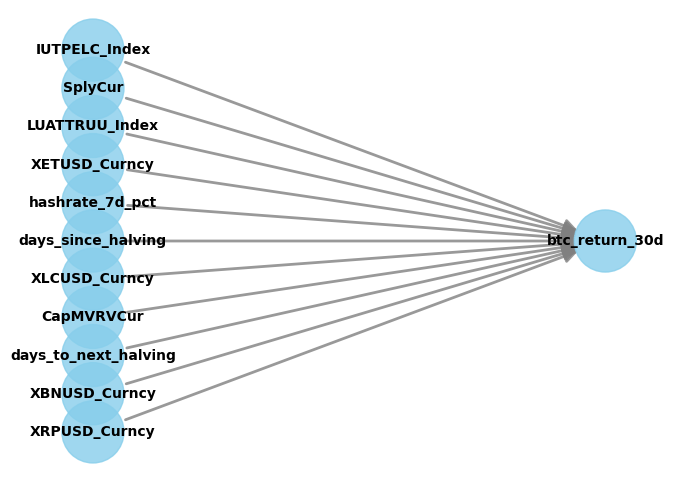

ATE estimé de days_since_halving sur btc_return_30d: -0.000151


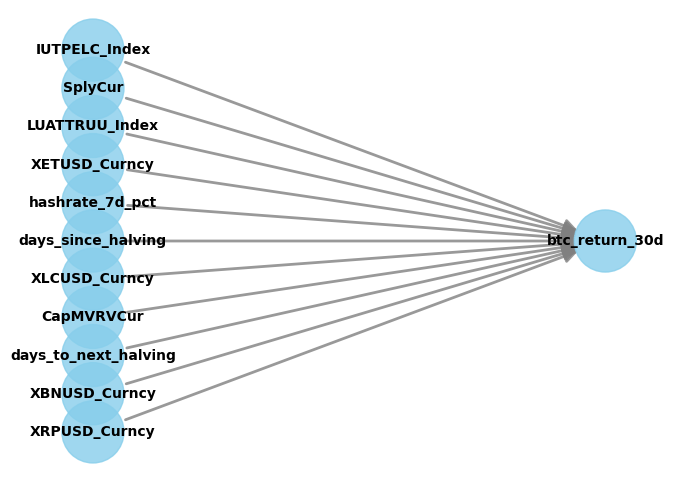

ATE estimé de XRPUSD_Curncy sur btc_return_30d: -0.088667


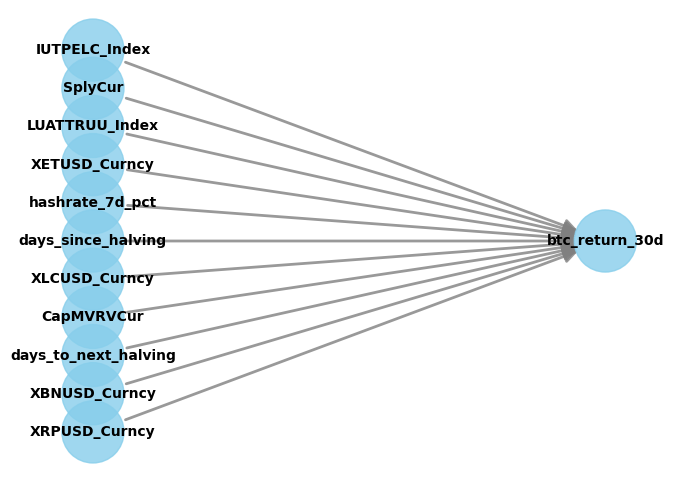

ATE estimé de LUATTRUU_Index sur btc_return_30d: 0.000251


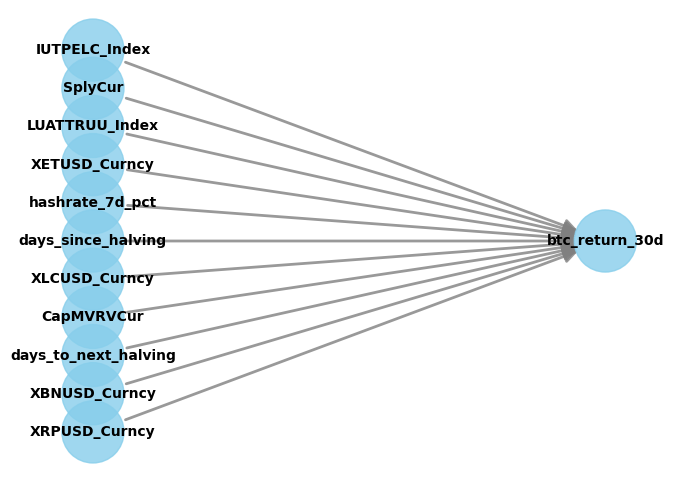

ATE estimé de IUTPELC_Index sur btc_return_30d: -0.004652


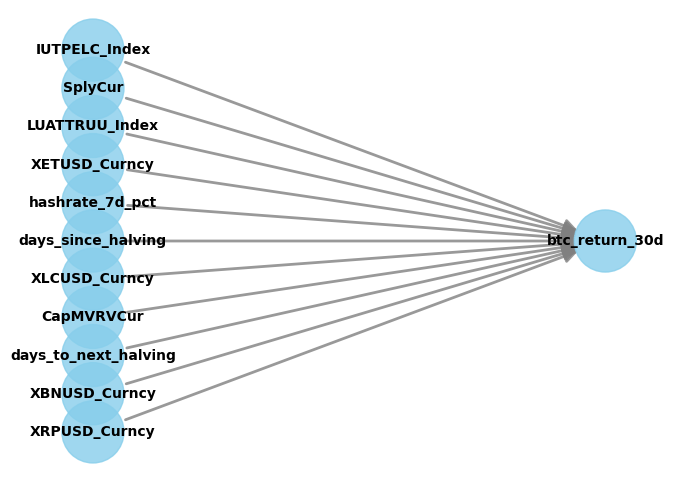

ATE estimé de SplyCur sur btc_return_30d: -0.000000


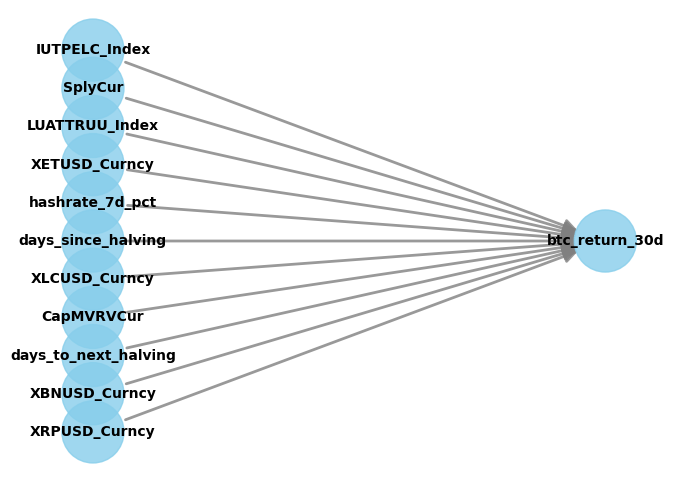

ATE estimé de XLCUSD_Curncy sur btc_return_30d: 0.000352


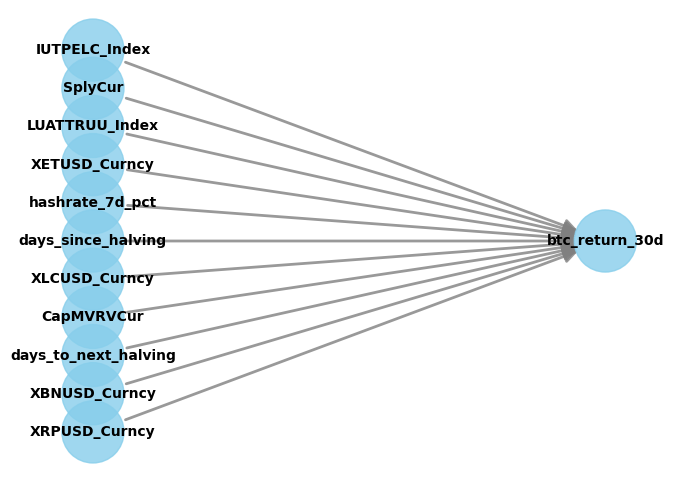

ATE estimé de XETUSD_Curncy sur btc_return_30d: -0.000164


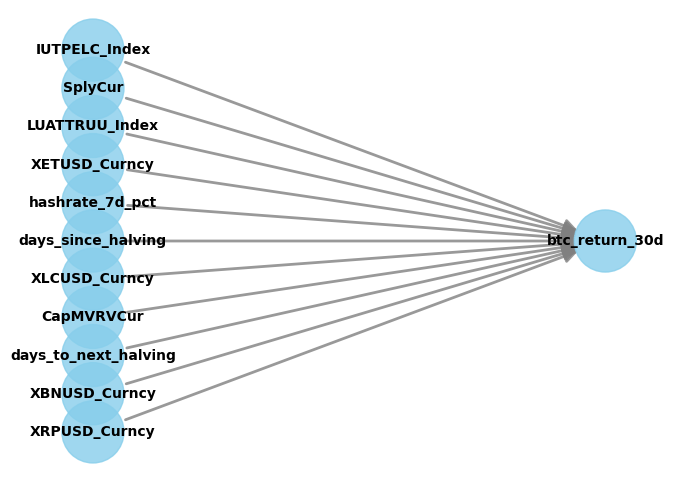

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from dowhy import CausalModel

# ============================================================
# 1. PRÉTRAITEMENT : Nettoyage, création des variables
# ============================================================

# Vérification du nom de la colonne BTC
btc_col = "XBTUSD Curncy"
if btc_col not in pivot_df.columns:
    raise ValueError("Colonne de prix BTC 'XBTUSD Curncy' introuvable dans pivot_df")

# Calcul du rendement futur BTC (30 jours)
pivot_df["btc_return_30d"] = np.log(pivot_df[btc_col].shift(-30) / pivot_df[btc_col])

# Calcul de hashrate_7d_pct si HashRate est présent
if "HashRate" in pivot_df.columns:
    pivot_df["hashrate_7d_pct"] = pivot_df["HashRate"].pct_change(periods=7) * 100
else:
    pivot_df["hashrate_7d_pct"] = np.nan
    print(" 'HashRate' non présent. La variable hashrate_7d_pct sera NaN.")

# Drop des lignes incomplètes
pivot_df.dropna(subset=["btc_return_30d", "hashrate_7d_pct"], inplace=True)

# ============================================================
# 2. GRANGER CAUSALITY TEST
# ============================================================

features = [
    "hashrate_7d_pct",
    "CapMVRVCur",
    "XBNUSD Curncy",
    "days_to_next_halving",
    "days_since_halving",
    "XRPUSD Curncy",
    "LUATTRUU Index",
    "IUTPELC Index",
    "SplyCur",
    "XLCUSD Curncy",
    "XETUSD Curncy"
]

print("=" * 60)
print("TEST DE CAUSALITÉ DE GRANGER")
print("=" * 60)

maxlag = 7
for var in features:
    print(f"\n{var} -> btc_return_14d")
    try:
        data = pivot_df[["btc_return_30d", var]].dropna()
        result = sm.tsa.stattools.grangercausalitytests(data, maxlag=maxlag, verbose=False)
        p_values = [round(result[lag][0]["ssr_ftest"][1], 4) for lag in range(1, maxlag + 1)]
        min_p = min(p_values)
        best_lag = p_values.index(min_p) + 1
        print(f"P-values (lags 1 à {maxlag}): {p_values}")
        if min_p < 0.05:
            print(f"-> Causalité détectée au lag {best_lag} (p={min_p})")
        else:
            print(f"-> Pas de causalité de Granger significative (p_min={min_p})")
    except Exception as e:
        print(f"Erreur pour {var}: {e}")

# ============================================================
# 3. ESTIMATION CAUSALE AVEC DOWHY
# ============================================================

print("\n" + "=" * 60)
print("ESTIMATION CAUSALE (DoWhy)")
print("=" * 60)

# Colonnes à utiliser
cols_needed = [
    "btc_return_30d",
    "XBNUSD Curncy",
    "CapMVRVCur",
    "hashrate_7d_pct",
    "days_to_next_halving",
    "days_since_halving",
    "XRPUSD Curncy",
    "LUATTRUU Index",
    "IUTPELC Index",
    "SplyCur",
    "XLCUSD Curncy",
    "XETUSD Curncy"
]

# Vérifier leur présence réelle
available_cols = [col for col in cols_needed if col in pivot_df.columns]
pivot_df_clean = pivot_df[available_cols].replace([np.inf, -np.inf], np.nan).dropna()

# Remplacer les espaces par underscores pour DoWhy
pivot_df_clean = pivot_df_clean.rename(columns={
    "XBNUSD Curncy": "XBNUSD_Curncy",
    "LUATTRUU Index": "LUATTRUU_Index",
    "XRPUSD Curncy": "XRPUSD_Curncy",
    "IUTPELC Index": "IUTPELC_Index",
    "XLCUSD Curncy": "XLCUSD_Curncy",
    "XETUSD Curncy": "XETUSD_Curncy"
})
pivot_df = pivot_df_clean.copy()

# Graphe causal
causal_graph = """
digraph {
    XBNUSD_Curncy -> btc_return_30d;
    CapMVRVCur -> btc_return_30d;
    hashrate_7d_pct -> btc_return_30d;
    days_to_next_halving -> btc_return_30d;
    days_since_halving -> btc_return_30d;
    XRPUSD_Curncy -> btc_return_30d;
    LUATTRUU_Index -> btc_return_30d;
    IUTPELC_Index -> btc_return_30d;
    SplyCur -> btc_return_30d;
    XLCUSD_Curncy -> btc_return_30d;
    XETUSD_Curncy -> btc_return_30d;
}
"""

# Fonction d’estimation ATE
def estimate_ate(treatment: str):
    try:
        model = CausalModel(
            data=pivot_df,
            treatment=treatment,
            outcome="btc_return_30d",
            graph=causal_graph
        )
        identified_estimand = model.identify_effect()
        estimate = model.estimate_effect(identified_estimand, method_name="backdoor.linear_regression")
        print(f"ATE estimé de {treatment} sur btc_return_30d: {estimate.value:.6f}")
        model.view_model()
    except Exception as e:
        print(f"[Erreur ATE] {treatment} -> {e}")

# Lancer les estimations
treatments = [
    "XBNUSD_Curncy",
    "CapMVRVCur",
    "hashrate_7d_pct",
    "days_to_next_halving",
    "days_since_halving",
    "XRPUSD_Curncy",
    "LUATTRUU_Index",
    "IUTPELC_Index",
    "SplyCur",
    "XLCUSD_Curncy",
    "XETUSD_Curncy"
]

for var in treatments:
    estimate_ate(var)


Dans les résultats précédemment obtenus, nous avons appliqué une analyse de causalité entre plusieurs variables explicatives (ou "features") et les rendements futurs du Bitcoin à 14 jours (btc_return_14d). Concrètement, cela signifie que nous cherchions à identifier si certaines variables, comme hashrate_7d_pct, CapMVRVCur ou XBNUSD Curncy, avaient une influence causale sur l'évolution du prix du Bitcoin deux semaines plus tard.

Pour cela, deux méthodes complémentaires ont été utilisées :

Le test de Granger : pour détecter si une variable passée aide statistiquement à prédire les rendements futurs. Ce test a mis en évidence une causalité temporelle pour les trois variables analysées (avec des lags significatifs différents).

Le framework causal DoWhy : qui, à partir d’un graphe causal défini manuellement, a permis d’estimer l’effet de traitement moyen (ATE) de chaque variable sur btc_return_14d, en isolant les biais potentiels de confusion.

En résumé, on a donc cherché à identifier des relations de causalité économique structurelle et temporelle entre certains indicateurs et les rendements du BTC à 14 jours.

## Test causality

[OK] Using outcome column: btc_return_30d
Existing candidate factors: ['hashrate_7d_pct', 'CapMVRVCur', 'XBNUSD_Curncy', 'days_to_next_halving', 'days_since_halving', 'XRPUSD_Curncy', 'LUATTRUU_Index', 'IUTPELC_Index', 'SplyCur', 'XLCUSD_Curncy', 'XETUSD_Curncy']
Missing candidates (ignored): ['XBNUSD Curncy', 'market_cap_usd', 'price_usd', 'XRPUSD Curncy', 'LUATTRUU Index', 'IUTPELC Index', 'EBBSTOTA Index', 'FARBAST Index', 'JPYUSD Curncy', 'CPEXEMUY Index', 'XLCUSD Curncy', 'XETUSD Curncy']

STATIONARITY CHECK (ADF p-value; p<0.05 => stationary)
             feature  ADF_p_raw   ADF_p_diff    ADF_p_pct
     hashrate_7d_pct   0.000000 3.804162e-28          NaN
          CapMVRVCur   0.188148 7.351504e-24 0.000000e+00
       XBNUSD_Curncy   0.056121 2.175766e-17 6.185757e-27
days_to_next_halving   0.153572 0.000000e+00 0.000000e+00
  days_since_halving   0.147414 0.000000e+00          NaN
       XRPUSD_Curncy   0.950709 7.231345e-19 1.471901e-26
      LUATTRUU_Index   0.497030 0.00000

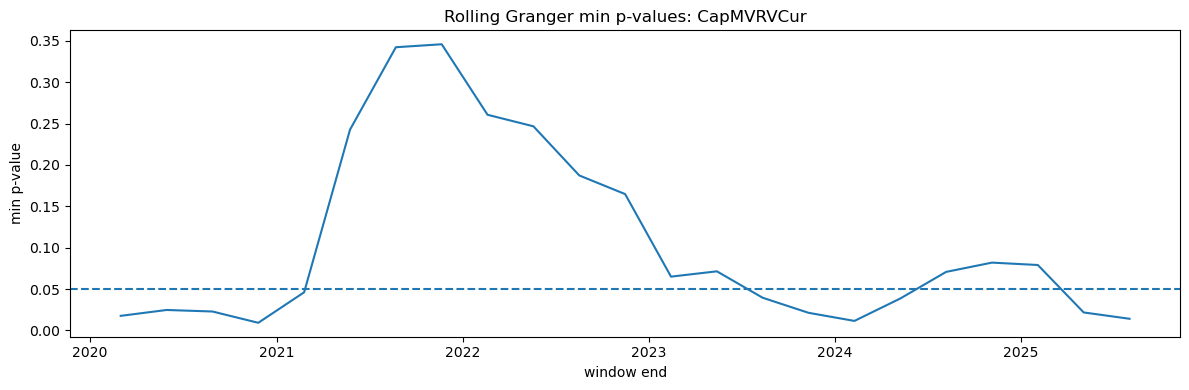


Pipeline complete.


In [13]:
# ============================================================
# CAUSALITY PIPELINE WITHOUT BTC PRICE (uses existing btc_return_* column)
# Granger -> DoWhy -> Rolling robustness
# Idempotent: does NOT mutate your original pivot_df
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from dowhy import CausalModel

# =========================
# 0) SETTINGS
# =========================
MAXLAG = 7
ALPHA = 0.05
START_DATE = "2018-03-01"

# If you want a specific outcome, set it here:
# OUTCOME_COL = "btc_return_14d"
OUTCOME_COL = None  # auto-detect

"""
Top 10 features:
 rank              feature  importance
    1       market_cap_usd    0.024793
    2   days_since_halving    0.023166
    3              SplyCur    0.023032
    4 days_to_next_halving    0.020370
    5            price_usd    0.020042
    6           CapMVRVCur    0.019645
    7       EBBSTOTA Index    0.019059
    8        FARBAST Index    0.018738
    9        JPYUSD Curncy    0.015736
   10       CPEXEMUY Index    0.015466
"""


# Candidate factors: put BOTH possible name styles (with spaces and with underscores)
CANDIDATES = [
    "hashrate_7d_pct",
    "CapMVRVCur",

    "XBNUSD Curncy", "XBNUSD_Curncy",
    "days_to_next_halving",
    "days_since_halving",
    "market_cap_usd",
    "price_usd",

    "XRPUSD Curncy", "XRPUSD_Curncy",

    "LUATTRUU Index", "LUATTRUU_Index",
    "IUTPELC Index", "IUTPELC_Index",

    "SplyCur",
    "EBBSTOTA Index",
    "FARBAST Index",
    "JPYUSD Curncy",
    "CPEXEMUY Index",

    "XLCUSD Curncy", "XLCUSD_Curncy",
    "XETUSD Curncy", "XETUSD_Curncy",
]

# =========================
# 1) HELPERS
# =========================
def _ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = pd.to_datetime(out.index)
    out = out.sort_index()
    return out

def find_first_existing_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def autodetect_outcome(df: pd.DataFrame) -> str:
    # prefer 14d if present, otherwise pick the first btc_return_* found
    prefer = ["btc_return_14d", "btc_return_30d", "btc_return_60d", "btc_return_1d"]
    for c in prefer:
        if c in df.columns:
            return c
    # fallback: any column starting with btc_return_
    for c in df.columns:
        if isinstance(c, str) and c.startswith("btc_return_"):
            return c
    raise ValueError("No outcome column found. Expected something like btc_return_14d or btc_return_30d.")

def adf_stationarity_pvalue(series: pd.Series) -> float:
    s = series.dropna().astype(float)
    if len(s) < 50:
        return np.nan
    try:
        return float(adfuller(s, autolag="AIC")[1])
    except Exception:
        return np.nan

def make_stationary(series: pd.Series, method: str) -> pd.Series:
    s = series.astype(float)
    if method == "diff":
        return s.diff(1)
    if method == "pct":
        return s.pct_change(1)
    return s  # raw

def granger_test(df_xy: pd.DataFrame, maxlag: int):
    df_xy = df_xy.dropna()
    if len(df_xy) < 100:
        return {"ok": False, "reason": "too_few_rows"}
    try:
        res = sm.tsa.stattools.grangercausalitytests(df_xy, maxlag=maxlag, verbose=False)
        pvals = [float(res[l][0]["ssr_ftest"][1]) for l in range(1, maxlag + 1)]
        min_p = float(np.min(pvals))
        best_lag = int(np.argmin(pvals) + 1)
        return {"ok": True, "pvals": pvals, "min_p": min_p, "best_lag": best_lag}
    except Exception as e:
        return {"ok": False, "reason": str(e)}

def sanitize_colname(name: str) -> str:
    out = []
    for ch in name:
        out.append(ch if (ch.isalnum() or ch == "_") else "_")
    s = "".join(out)
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

def build_simple_dag(treatments_safe, outcome_safe):
    edges = "\n".join([f"    {t} -> {outcome_safe};" for t in treatments_safe])
    return f"digraph {{\n{edges}\n}}"

def rolling_granger(df_transformed, outcome, feature, window_days=365*2, step_days=90, maxlag=7):
    idx = df_transformed.index
    start = idx.min()
    end = idx.max()

    rows = []
    cur = start
    while cur + pd.Timedelta(days=window_days) <= end:
        w_end = cur + pd.Timedelta(days=window_days)
        chunk = df_transformed.loc[cur:w_end, [outcome, feature]].dropna()
        out = granger_test(chunk, maxlag=maxlag)
        if out["ok"]:
            rows.append({
                "window_start": cur,
                "window_end": w_end,
                "min_p": out["min_p"],
                "best_lag": out["best_lag"],
                "n": len(chunk),
            })
        cur = cur + pd.Timedelta(days=step_days)
    return pd.DataFrame(rows)

# =========================
# 2) DATA PREP (NO MUTATION)
# =========================
df0 = _ensure_datetime_index(pivot_df)
df0 = df0[df0.index >= pd.to_datetime(START_DATE)].copy()
df0 = df0.replace([np.inf, -np.inf], np.nan)

# Outcome selection
if OUTCOME_COL is None:
    OUTCOME_COL = autodetect_outcome(df0)
else:
    if OUTCOME_COL not in df0.columns:
        raise ValueError(f"Outcome column '{OUTCOME_COL}' not found in pivot_df.")

print(f"[OK] Using outcome column: {OUTCOME_COL}")

# Keep candidates that exist
existing_candidates = [c for c in CANDIDATES if c in df0.columns]
existing_candidates = list(dict.fromkeys(existing_candidates))  # unique preserving order
missing_candidates = [c for c in CANDIDATES if c not in df0.columns]

print("Existing candidate factors:", existing_candidates)
if missing_candidates:
    # keep short print
    print("Missing candidates (ignored):", list(dict.fromkeys(missing_candidates)))

if len(existing_candidates) == 0:
    raise ValueError("None of the candidate features exist in pivot_df. Check your column names.")

df_base = df0[[OUTCOME_COL] + existing_candidates].dropna(subset=[OUTCOME_COL]).copy()

# =========================
# 3) STATIONARITY CHECK (ADF)
# =========================
print("\n" + "="*70)
print("STATIONARITY CHECK (ADF p-value; p<0.05 => stationary)")
print("="*70)

rows = []
for col in existing_candidates:
    p_raw  = adf_stationarity_pvalue(df_base[col])
    p_diff = adf_stationarity_pvalue(make_stationary(df_base[col], "diff"))
    p_pct  = adf_stationarity_pvalue(make_stationary(df_base[col], "pct"))
    rows.append([col, p_raw, p_diff, p_pct])

adf_df = pd.DataFrame(rows, columns=["feature", "ADF_p_raw", "ADF_p_diff", "ADF_p_pct"])
print(adf_df.to_string(index=False))

# Transformation policy for Granger (stationarity matters)
TRANSFORM_POLICY = {}
for _, r in adf_df.iterrows():
    feat = r["feature"]
    if np.isnan(r["ADF_p_raw"]):
        TRANSFORM_POLICY[feat] = "raw"
    elif r["ADF_p_raw"] < 0.05:
        TRANSFORM_POLICY[feat] = "raw"
    elif r["ADF_p_diff"] < 0.05:
        TRANSFORM_POLICY[feat] = "diff"
    elif r["ADF_p_pct"] < 0.05:
        TRANSFORM_POLICY[feat] = "pct"
    else:
        TRANSFORM_POLICY[feat] = "diff"

print("\nChosen transform policy (for Granger):", TRANSFORM_POLICY)

df_t = pd.DataFrame(index=df_base.index)
df_t[OUTCOME_COL] = df_base[OUTCOME_COL].astype(float)

for feat in existing_candidates:
    method = TRANSFORM_POLICY.get(feat, "raw")
    df_t[feat] = make_stationary(df_base[feat], method)

df_t = df_t.dropna(subset=[OUTCOME_COL])

# =========================
# 4) GRANGER FILTER
# =========================
print("\n" + "="*70)
print(f"GRANGER CAUSALITY TESTS (X -> Y), maxlag={MAXLAG}, alpha={ALPHA}")
print("="*70)

granger_rows = []
for feat in existing_candidates:
    dxy = df_t[[OUTCOME_COL, feat]].dropna()
    out = granger_test(dxy, maxlag=MAXLAG)
    if out["ok"]:
        sig = out["min_p"] < ALPHA
        granger_rows.append([feat, out["min_p"], out["best_lag"], sig, TRANSFORM_POLICY[feat]])
        print(f"{feat:28s} min_p={out['min_p']:.4g} | best_lag={out['best_lag']} | sig={sig} | transform={TRANSFORM_POLICY[feat]}")
    else:
        granger_rows.append([feat, np.nan, np.nan, False, TRANSFORM_POLICY[feat]])
        print(f"{feat:28s} failed: {out['reason']}")

granger_df = pd.DataFrame(granger_rows, columns=["feature", "min_p", "best_lag", "significant", "transform"])\
            .sort_values(["significant", "min_p"], ascending=[False, True])

selected = granger_df[granger_df["significant"]]["feature"].tolist()
print("\nSelected for DoWhy:", selected if selected else "None (you can loosen alpha or change maxlag)")

# =========================
# 5) DOWHY (ATE) ON SELECTED
# =========================
print("\n" + "="*70)
print("DOWHY ATE ESTIMATION (simple prior DAG: treatment -> outcome)")
print("="*70)

if selected:
    cols_for_dowhy = [OUTCOME_COL] + selected
    df_causal = df0[cols_for_dowhy].dropna().copy()

    # sanitize names for DoWhy graph
    rename_map = {c: sanitize_colname(c) for c in cols_for_dowhy}
    df_safe = df_causal.rename(columns=rename_map)

    outcome_safe = rename_map[OUTCOME_COL]
    treatments_safe = [rename_map[c] for c in selected]

    dag = build_simple_dag(treatments_safe, outcome_safe)
    print("\nDAG used:\n", dag)

    ate_rows = []
    for t in treatments_safe:
        try:
            model = CausalModel(data=df_safe, treatment=t, outcome=outcome_safe, graph=dag)
            estimand = model.identify_effect()
            estimate = model.estimate_effect(estimand, method_name="backdoor.linear_regression")
            ate_rows.append([t, float(estimate.value)])
            print(f"{t:28s} ATE={float(estimate.value): .6f}")
        except Exception as e:
            print(f"[DoWhy error] {t}: {e}")

    if ate_rows:
        ate_df = pd.DataFrame(ate_rows, columns=["treatment", "ATE"])
        print("\nATE summary:")
        print(ate_df.to_string(index=False))

# =========================
# 6) ROLLING GRANGER ROBUSTNESS
# =========================
print("\n" + "="*70)
print("ROBUSTNESS: Rolling Granger (stability over time)")
print("="*70)

if selected:
    feat0 = selected[0]
    roll = rolling_granger(df_t, OUTCOME_COL, feat0, window_days=365*2, step_days=90, maxlag=MAXLAG)
    if roll.empty:
        print("No rolling results (maybe too few rows per window).")
    else:
        print(f"Rolling Granger for: {feat0}")
        print(roll.head(10).to_string(index=False))
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(12,4))
            plt.plot(roll["window_end"], roll["min_p"])
            plt.axhline(ALPHA, linestyle="--")
            plt.title(f"Rolling Granger min p-values: {feat0}")
            plt.ylabel("min p-value")
            plt.xlabel("window end")
            plt.tight_layout()
            plt.show()
        except Exception:
            pass

print("\nPipeline complete.")

In [25]:
import numpy as np
import pandas as pd

# =========================
# =========================

OUTCOME = "btc_return_30d"
HORIZON = 30

# 1) If btc_return_30d already exists, keep it
if OUTCOME in pivot_df.columns:
    print(f"[OK] {OUTCOME} already exists. No need to create it.")

else:
    # 2) Try many BTC price column name variants
    BTC_PRICE_CANDIDATES = [
        "XBTUSD Curncy",   # most likely in your data
        "XBTUSD_Curncy",
        "XBTUSD",
        "BTCUSD",
        "BTCUSD Curncy",
        "price_usd",
        "PriceUSD",
        "price",
    ]

    btc_price_col = next((c for c in BTC_PRICE_CANDIDATES if c in pivot_df.columns), None)

    # 3) If still not found, try heuristic search (contains BTC/XBT)
    if btc_price_col is None:
        like_btc = [c for c in pivot_df.columns if isinstance(c, str) and ("XBTUSD" in c or "BTC" in c)]
        print("[ERROR] No BTC price column found from candidates.")
        print("Columns that look like BTC/XBTUSD:", like_btc[:30])
        raise ValueError(
            "No BTC price column found in pivot_df. "
            "Check the printed candidates above and add the exact name to BTC_PRICE_CANDIDATES."
        )

    # Create btc_return_30d (log return)
    pivot_df = pivot_df.sort_index()
    pivot_df[OUTCOME] = np.log(pivot_df[btc_price_col].shift(-HORIZON) / pivot_df[btc_price_col])

    print("[OK] BTC price column used:", btc_price_col)
    print("[OK] btc_return_30d created:", OUTCOME in pivot_df.columns)


# =========================
# 0) CONFIG
# =========================
CANDIDATES = [
    "hashrate_7d_pct",
    "CapMVRVCur",

    "XBNUSD Curncy", "XBNUSD_Curncy",
    "days_to_next_halving",
    "days_since_halving",
    "market_cap_usd",
    "price_usd",

    "XRPUSD Curncy", "XRPUSD_Curncy",

    "LUATTRUU Index", "LUATTRUU_Index",
    "IUTPELC Index", "IUTPELC_Index",

    "SplyCur",
    "EBBSTOTA Index",
    "FARBAST Index",
    "JPYUSD Curncy",
    "CPEXEMUY Index",

    "XLCUSD Curncy", "XLCUSD_Curncy",
    "XETUSD Curncy", "XETUSD_Curncy",
]

LAGS = [1, 2, 3, 4, 5, 6, 7]   # past days used as candidate causes
STANDARDIZE = True
DROPNA = True


# =========================
# 1) BUILD LAGGED DATASET
# =========================
def build_lagged_df(df: pd.DataFrame, outcome: str, candidates: list, lags: list) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # Keep only existing columns
    keep = [c for c in [outcome] + candidates if c in df.columns]
    if outcome not in keep:
        raise ValueError(f"Outcome '{outcome}' not found in pivot_df.")
    if len(keep) < 2:
        raise ValueError("Not enough candidate columns found in pivot_df.")

    base = df[keep].replace([np.inf, -np.inf], np.nan)

    lagged = {}
    for c in keep:
        if c == outcome:
            continue
        for L in lags:
            lagged[f"{c}_lag{L}"] = base[c].shift(L)

    out = pd.concat([base[[outcome]], pd.DataFrame(lagged, index=base.index)], axis=1)

    if DROPNA:
        out = out.dropna()

    return out

lag_df = build_lagged_df(pivot_df, OUTCOME, CANDIDATES, LAGS)

# Optional standardization (helps conditional independence tests)
if STANDARDIZE:
    X = lag_df.values.astype(float)
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd == 0] = 1.0
    lag_df = pd.DataFrame((X - mu) / sd, index=lag_df.index, columns=lag_df.columns)

print("Lagged dataset shape:", lag_df.shape)
print("Columns example:", lag_df.columns[:10].tolist())


# =========================
# 2) RUN PC (causal-learn)
# =========================
# pip install causal-learn
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

data = lag_df.values.astype(float)

alpha = 0.1  # stricter => fewer edges
cg = pc(data, alpha=alpha, indep_test=fisherz, stable=True, uc_rule=0, uc_priority=2)


# =========================
# 3) EXTRACT DIRECTED EDGES (FIXED for causal-learn)
# =========================
colnames = lag_df.columns.tolist()
g = cg.G

# depending on causal-learn version, nodes can be in g.nodes or g.get_nodes()
nodes = getattr(g, "nodes", None)
if nodes is None:
    nodes = g.get_nodes()

edges = []
for i in range(len(colnames)):
    for j in range(len(colnames)):
        if i == j:
            continue
        ni, nj = nodes[i], nodes[j]
        if g.is_directed_from_to(ni, nj):
            edges.append((colnames[i], colnames[j]))

print("\nLearned directed edges (PC):")
for a, b in edges:
    print(f"  {a} -> {b}")

# =========================
# 4) FILTER: ONLY CAUSES OF OUTCOME
# =========================
target_edges = [(a, b) for (a, b) in edges if b == OUTCOME]

print(f"\nEdges pointing to {OUTCOME}:")
if not target_edges:
    print("  (none found — try alpha=0.05 or add more lags/features)")
else:
    for a, b in target_edges:
        print(f"  {a} -> {b}")



# =========================
# 4) FILTER: ONLY CAUSES OF OUTCOME
# =========================
target_edges = [(a, b) for (a, b) in edges if b == OUTCOME]

print(f"\nEdges pointing to {OUTCOME}:")
if not target_edges:
    print("  (none found — try alpha=0.05 or add more lags/features)")
else:
    for a, b in target_edges:
        print(f"  {a} -> {b}")


[OK] btc_return_30d already exists. No need to create it.
Lagged dataset shape: (1595, 78)
Columns example: ['btc_return_30d', 'hashrate_7d_pct_lag1', 'hashrate_7d_pct_lag2', 'hashrate_7d_pct_lag3', 'hashrate_7d_pct_lag4', 'hashrate_7d_pct_lag5', 'hashrate_7d_pct_lag6', 'hashrate_7d_pct_lag7', 'CapMVRVCur_lag1', 'CapMVRVCur_lag2']


  0%|          | 0/78 [00:00<?, ?it/s]


Learned directed edges (PC):
  hashrate_7d_pct_lag1 -> hashrate_7d_pct_lag5
  hashrate_7d_pct_lag3 -> hashrate_7d_pct_lag1
  hashrate_7d_pct_lag4 -> hashrate_7d_pct_lag2
  hashrate_7d_pct_lag4 -> hashrate_7d_pct_lag3
  hashrate_7d_pct_lag5 -> hashrate_7d_pct_lag4
  hashrate_7d_pct_lag6 -> hashrate_7d_pct_lag1
  hashrate_7d_pct_lag6 -> hashrate_7d_pct_lag2
  hashrate_7d_pct_lag6 -> hashrate_7d_pct_lag4
  hashrate_7d_pct_lag7 -> hashrate_7d_pct_lag2
  hashrate_7d_pct_lag7 -> hashrate_7d_pct_lag3
  hashrate_7d_pct_lag7 -> hashrate_7d_pct_lag5
  CapMVRVCur_lag7 -> days_to_next_halving_lag1
  XBNUSD_Curncy_lag1 -> btc_return_30d
  XBNUSD_Curncy_lag2 -> XBNUSD_Curncy_lag1
  XBNUSD_Curncy_lag3 -> XBNUSD_Curncy_lag2
  XBNUSD_Curncy_lag4 -> XBNUSD_Curncy_lag1
  XBNUSD_Curncy_lag4 -> XBNUSD_Curncy_lag3
  XBNUSD_Curncy_lag5 -> XBNUSD_Curncy_lag2
  XBNUSD_Curncy_lag5 -> XBNUSD_Curncy_lag4
  XBNUSD_Curncy_lag6 -> XBNUSD_Curncy_lag3
  XBNUSD_Curncy_lag6 -> XBNUSD_Curncy_lag5
  XBNUSD_Curncy_lag7 ->

In [27]:
!pip install git+https://github.com/xunzheng/notears.git

  Cloning https://github.com/xunzheng/notears.git to c:\users\marce\appdata\local\temp\pip-req-build-6alu0m9t
  Resolved https://github.com/xunzheng/notears.git to commit eb06eaf08ca90501a8caa4062d62466747ba3cec
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   -------------------------------- ------- 2.6/3.2 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 16.9 MB/s  0:00:00
  Created wheel for notears: filename=notears-3.0-py3-none-any.whl size=17679 sha256=81449a10518753b7560cfd48a99d3ee2bfc0a1958a3e6c179fbb3256afd2047a
  Stored in directory: C:\Users\marce\AppData\Local\Temp\pip-ephem-wheel-cache-g2936tfl\

  Running command git clone --filter=blob:none --quiet https://github.com/xunzheng/notears.git 'C:\Users\marce\AppData\Local\Temp\pip-req-build-6alu0m9t'

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import numpy as np
import pandas as pd
from notears.linear import notears_linear

# =========================
# 1) PREP DATA
# =========================

OUTCOME = "btc_return_30d"

# lag_df doit déjà exister (dataset laggé que tu as utilisé pour PC)
data = lag_df.values.astype(float)
colnames = lag_df.columns.tolist()

print("Data shape:", data.shape)

# =========================
# 2) RUN NOTEARS
# =========================

# lambda1 = sparsity penalty (plus grand = moins d’edges)
W_est = notears_linear(data, lambda1=0.01, loss_type='l2')

print("Estimated adjacency matrix shape:", W_est.shape)

# =========================
# 3) EXTRACT EDGES
# =========================

threshold = 0.01  # remove tiny weights
edges = []

for i in range(W_est.shape[0]):
    for j in range(W_est.shape[1]):
        if abs(W_est[i, j]) > threshold:
            edges.append((colnames[i], colnames[j], W_est[i, j]))

print("\nLearned edges (NOTEARS):")
for a, b, w in edges:
    print(f"{a} -> {b} | weight={w:.4f}")

# =========================
# 4) FILTER CAUSES OF BTC
# =========================

target_edges = [(a, b, w) for (a, b, w) in edges if b == OUTCOME]

print(f"\nEdges pointing to {OUTCOME}:")
for a, b, w in target_edges:
    print(f"{a} -> {b} | weight={w:.4f}")

Data shape: (1595, 78)
Estimated adjacency matrix shape: (78, 78)

Learned edges (NOTEARS):
CapMVRVCur_lag2 -> CapMVRVCur_lag1 | weight=0.8758
CapMVRVCur_lag3 -> CapMVRVCur_lag2 | weight=0.8424
CapMVRVCur_lag4 -> CapMVRVCur_lag3 | weight=0.7900
CapMVRVCur_lag5 -> CapMVRVCur_lag6 | weight=0.9524
CapMVRVCur_lag6 -> CapMVRVCur_lag4 | weight=0.4726
CapMVRVCur_lag6 -> CapMVRVCur_lag7 | weight=0.9324
XBNUSD_Curncy_lag2 -> XBNUSD_Curncy_lag1 | weight=0.8964
XBNUSD_Curncy_lag3 -> XBNUSD_Curncy_lag2 | weight=0.9657
XBNUSD_Curncy_lag3 -> XBNUSD_Curncy_lag4 | weight=0.7017
XBNUSD_Curncy_lag4 -> XBNUSD_Curncy_lag5 | weight=0.8861
XBNUSD_Curncy_lag5 -> XBNUSD_Curncy_lag6 | weight=0.9093
XBNUSD_Curncy_lag6 -> XBNUSD_Curncy_lag7 | weight=0.9680
days_to_next_halving_lag1 -> days_since_halving_lag4 | weight=-0.6995
days_to_next_halving_lag2 -> days_since_halving_lag2 | weight=-0.5532
days_to_next_halving_lag3 -> days_to_next_halving_lag2 | weight=0.3360
days_to_next_halving_lag3 -> days_to_next_halving

## Test PDF Causality

In [10]:
OUTCOME_COL = "btc_return_30d"

B_COLS = [
    OUTCOME_COL,
    "CapMVRVCur",
    "XBNUSD_Curncy",
    "XLCUSD_Curncy",
    "IUTPELC_Index",
    "hashrate_7d_pct",
    "days_to_next_halving",
    "days_since_halving",
    "LUATTRUU_Index",
    "SplyCur",
    "XETUSD_Curncy",
    "XRPUSD_Curncy",
]
B_COLS = [c for c in B_COLS if c in pivot_df.columns]


In [11]:
import numpy as np
import pandas as pd

def build_causality_matrix_boot_ols(
    df: pd.DataFrame,
    max_lag: int = 7,
    n_boot: int = 200,
    random_state: int = 42,
    standardize: bool = True,
):
    """
    Returns A (KxK) where A[i,j] ~ strength of i -> j.
    Technique: bootstrap + random lag + OLS + abs(coef) aggregation.
    (Inspired by the PDF technique / SLARAC-style construction.)
    """
    rng = np.random.default_rng(random_state)

    # clean & align
    Xdf = df.copy()
    Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna()
    Xdf = Xdf.sort_index()

    cols = list(Xdf.columns)
    X = Xdf.values.astype(float)
    T, K = X.shape

    if T < (max_lag + 50):
        raise ValueError(f"Too few rows after dropna: T={T}, need > max_lag+50.")

    # standardize (helps compare coefficients across variables)
    if standardize:
        mu = X.mean(axis=0, keepdims=True)
        sd = X.std(axis=0, keepdims=True) + 1e-12
        X = (X - mu) / sd

    # store best per lag then aggregate (max across lags like in the doc’s composition idea)
    A_per_lag = []

    for lag in range(1, max_lag + 1):
        A_acc = np.zeros((K, K), dtype=float)

        # Build lagged design for this lag:
        # Y = X[lag:]
        # Z = [X[lag-1], X[lag-2], ..., X[0]] stacked horizontally
        Y_full = X[lag:, :]                         # (T-lag, K)
        Z_blocks = [X[lag - h: T - h, :] for h in range(1, lag + 1)]
        Z_full = np.concatenate(Z_blocks, axis=1)    # (T-lag, K*lag)

        n_rows = Y_full.shape[0]
        idx_all = np.arange(n_rows)

        for _ in range(n_boot):
            # bootstrap rows with replacement
            idx = rng.choice(idx_all, size=n_rows, replace=True)

            Yb = Y_full[idx, :]          # (n_rows, K)
            Zb = Z_full[idx, :]          # (n_rows, K*lag)

            # OLS: Beta = (Z'Z)^(-1) Z'Y  -> shape (K*lag, K)
            # use lstsq for stability
            Beta, *_ = np.linalg.lstsq(Zb, Yb, rcond=None)

            # Beta is stacked by lag blocks:
            # block 0 = coefficients from X(t-1) to X(t)
            # block 1 = coefficients from X(t-2) to X(t), etc.
            # We collapse across lags by taking max(abs) per (source, target)
            Beta_abs = np.abs(Beta)  # (K*lag, K)

            # reshape to (lag, K, K): [lag_block, source, target]
            Beta_abs_reshaped = Beta_abs.reshape(lag, K, K)

            # take max over lag dimension for this bootstrap draw
            # so we keep the strongest lag influence i->j in this draw
            Bmax = Beta_abs_reshaped.max(axis=0)  # (K, K)

            A_acc += Bmax

        A_acc /= float(n_boot)
        np.fill_diagonal(A_acc, 0.0)
        A_per_lag.append(A_acc)

    # aggregate across lags (max keeps strongest lag influence overall)
    A = np.max(np.stack(A_per_lag, axis=0), axis=0)
    A_df = pd.DataFrame(A, index=cols, columns=cols)
    return A_df

In [12]:
df_B = pivot_df[B_COLS].copy()
A_causal = build_causality_matrix_boot_ols(df_B, max_lag=7, n_boot=200, random_state=42)
A_causal

,CapMVRVCur,hashrate_7d_pct,days_to_next_halving,days_since_halving,SplyCur
CapMVRVCur,0.000000e+00,1.107434e-01,0.060294,0.021813,0.000078
hashrate_7d_pct,1.587183e-02,0.000000e+00,0.197617,0.074842,0.000042
days_to_next_halving,9.339942e+05,3.322159e+06,0.000000,5533.566579,3404.678178
days_since_halving,2.769599e+06,1.108781e+07,53980.566023,0.000000,11883.916119
SplyCur,4.920439e+01,1.801522e+02,32.464044,13.098098,0.000000


In [13]:
top_k = 8
incoming = A_causal[OUTCOME_COL].sort_values(ascending=False)

# remove self if present (should already be 0)
incoming = incoming.drop(labels=[OUTCOME_COL], errors="ignore")

print("Top incoming causes of", OUTCOME_COL)
print(incoming.head(top_k))

KeyError: 'btc_return_30d'

In [ ]:
selected_from_causality = incoming.head(top_k).index.tolist()

# Option 1: use only these
selected = selected_from_causality

# Option 2: union with your Granger-selected set
# selected = sorted(set(selected_granger).union(selected_from_causality))

In [ ]:
def to_safe(name: str) -> str:
    # same sanitization style you used
    out = []
    for ch in name:
        out.append(ch if (ch.isalnum() or ch == "_") else "_")
    s = "".join(out)
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

cols_for_dowhy = [OUTCOME_COL] + selected
df_causal = pivot_df[cols_for_dowhy].replace([np.inf, -np.inf], np.nan).dropna().copy()

rename_map = {c: to_safe(c) for c in cols_for_dowhy}
df_safe = df_causal.rename(columns=rename_map)

outcome_safe = rename_map[OUTCOME_COL]
treatments_safe = [rename_map[c] for c in selected]

dag = "digraph {\n" + "\n".join([f"  {t} -> {outcome_safe};" for t in treatments_safe]) + "\n}"
print(dag)

In [ ]:
# ============================================================
# NEXT STEPS CODE: clean causal-matrix ranking -> (optional) Granger confirm
# -> build final DAG -> DoWhy ATE on filtered parents
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from dowhy import CausalModel

# -------------------------
# 0) SETTINGS
# -------------------------
OUTCOME_COL = "btc_return_30d"
MAX_LAG_CAUSAL = 7
N_BOOT = 200
RANDOM_STATE = 42

# Deterministic/calendar-like vars to exclude from causal parents
EXCLUDE_FROM_CAUSAL = {
    "days_to_next_halving",
    "days_since_halving",
}

# Top-k parents to keep from causal matrix (after exclusion)
TOP_K_PARENTS = 8

# Optional: confirm parents with Granger before DoWhy
RUN_GRANGER_CONFIRM = True
GRANGER_MAXLAG = 7
GRANGER_ALPHA = 0.05

# -------------------------
# 1) CANDIDATE SET (Choice B: restricted columns)
#    -> adapt if needed
# -------------------------
B_COLS = [
    OUTCOME_COL,
    "CapMVRVCur",
    "XBNUSD_Curncy",
    "XLCUSD_Curncy",
    "IUTPELC_Index",
    "hashrate_7d_pct",
    "days_to_next_halving",
    "days_since_halving",
    "LUATTRUU_Index",
    "SplyCur",
    "XETUSD_Curncy",
    "XRPUSD_Curncy",
]
B_COLS = [c for c in B_COLS if c in pivot_df.columns]

# -------------------------
# 2) CAUSALITY MATRIX (bootstrap + OLS + abs-coef aggregation)
#    (same technique you used, but we’ll rely on STANDARDIZE=True)
# -------------------------
def build_causality_matrix_boot_ols(
    df: pd.DataFrame,
    max_lag: int = 7,
    n_boot: int = 200,
    random_state: int = 42,
    standardize: bool = True,
):
    rng = np.random.default_rng(random_state)

    Xdf = df.copy()
    Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna()
    Xdf = Xdf.sort_index()

    cols = list(Xdf.columns)
    X = Xdf.values.astype(float)
    T, K = X.shape

    if T < (max_lag + 50):
        raise ValueError(f"Too few rows after dropna: T={T}, need > max_lag+50.")

    # Standardize so OLS coefficients are comparable across variables
    if standardize:
        mu = X.mean(axis=0, keepdims=True)
        sd = X.std(axis=0, keepdims=True) + 1e-12
        X = (X - mu) / sd

    A_per_lag = []
    for lag in range(1, max_lag + 1):
        A_acc = np.zeros((K, K), dtype=float)

        Y_full = X[lag:, :]  # (T-lag, K)
        Z_blocks = [X[lag - h: T - h, :] for h in range(1, lag + 1)]
        Z_full = np.concatenate(Z_blocks, axis=1)  # (T-lag, K*lag)

        n_rows = Y_full.shape[0]
        idx_all = np.arange(n_rows)

        for _ in range(n_boot):
            idx = rng.choice(idx_all, size=n_rows, replace=True)
            Yb = Y_full[idx, :]
            Zb = Z_full[idx, :]

            Beta, *_ = np.linalg.lstsq(Zb, Yb, rcond=None)  # (K*lag, K)
            Beta_abs = np.abs(Beta).reshape(lag, K, K)      # (lag, source, target)
            Bmax = Beta_abs.max(axis=0)                     # (K, K) max across lags
            A_acc += Bmax

        A_acc /= float(n_boot)
        np.fill_diagonal(A_acc, 0.0)
        A_per_lag.append(A_acc)

    A = np.max(np.stack(A_per_lag, axis=0), axis=0)  # max across lags
    return pd.DataFrame(A, index=cols, columns=cols)

df_B = pivot_df[B_COLS].copy()
A_causal = build_causality_matrix_boot_ols(
    df_B,
    max_lag=MAX_LAG_CAUSAL,
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
    standardize=True
)

# -------------------------
# 3) INCOMING PARENTS OF OUTCOME (EXCLUDING deterministic vars)
# -------------------------
incoming = A_causal[OUTCOME_COL].sort_values(ascending=False)
incoming = incoming.drop(labels=[OUTCOME_COL], errors="ignore")
incoming = incoming.drop(labels=[c for c in EXCLUDE_FROM_CAUSAL if c in incoming.index], errors="ignore")

selected_causal = incoming.head(TOP_K_PARENTS).index.tolist()

print("\nTop incoming causes of", OUTCOME_COL, "(after exclusion):")
print(incoming.head(TOP_K_PARENTS))

# -------------------------
# 4) (OPTIONAL) GRANGER CONFIRM on selected_causal
# -------------------------
def granger_test(df_xy: pd.DataFrame, maxlag: int):
    df_xy = df_xy.dropna()
    if len(df_xy) < 100:
        return {"ok": False, "reason": "too_few_rows"}
    try:
        res = sm.tsa.stattools.grangercausalitytests(df_xy, maxlag=maxlag, verbose=False)
        pvals = [float(res[l][0]["ssr_ftest"][1]) for l in range(1, maxlag + 1)]
        min_p = float(np.min(pvals))
        best_lag = int(np.argmin(pvals) + 1)
        return {"ok": True, "pvals": pvals, "min_p": min_p, "best_lag": best_lag}
    except Exception as e:
        return {"ok": False, "reason": str(e)}

def make_stationary(series: pd.Series, method: str) -> pd.Series:
    s = series.astype(float)
    if method == "diff":
        return s.diff(1)
    if method == "pct":
        return s.pct_change(1)
    return s

# Simple policy: use diff for level-like series; keep raw for returns/pct variables
# (You can plug your ADF-based policy here if you want; this keeps it short.)
STATIONARY_POLICY = {
    "hashrate_7d_pct": "raw",
    "SplyCur": "raw",
}

def get_policy(col: str) -> str:
    return STATIONARY_POLICY.get(col, "diff")

selected_final = selected_causal.copy()

if RUN_GRANGER_CONFIRM:
    df0 = pivot_df[[OUTCOME_COL] + selected_causal].replace([np.inf, -np.inf], np.nan).dropna(subset=[OUTCOME_COL]).copy()
    df_t = pd.DataFrame(index=df0.index)
    df_t[OUTCOME_COL] = df0[OUTCOME_COL].astype(float)

    for c in selected_causal:
        df_t[c] = make_stationary(df0[c], get_policy(c))

    granger_keep = []
    print("\nGRANGER CONFIRM (only on causal-matrix selected parents):")
    for feat in selected_causal:
        out = granger_test(df_t[[OUTCOME_COL, feat]], maxlag=GRANGER_MAXLAG)
        if out["ok"]:
            sig = out["min_p"] < GRANGER_ALPHA
            print(f"{feat:22s} min_p={out['min_p']:.4g} | best_lag={out['best_lag']} | keep={sig}")
            if sig:
                granger_keep.append(feat)
        else:
            print(f"{feat:22s} failed: {out['reason']}")

    if len(granger_keep) > 0:
        selected_final = granger_keep
    else:
        # if none pass, fallback to causal selection (don’t end up with empty set)
        selected_final = selected_causal

print("\nSelected parents for DoWhy:", selected_final)

# -------------------------
# 5) BUILD FINAL DAG (parents -> outcome) and RUN DoWhy ATE
# -------------------------
def sanitize_colname(name: str) -> str:
    out = []
    for ch in name:
        out.append(ch if (ch.isalnum() or ch == "_") else "_")
    s = "".join(out)
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

cols_for_dowhy = [OUTCOME_COL] + selected_final
df_causal = pivot_df[cols_for_dowhy].replace([np.inf, -np.inf], np.nan).dropna().copy()

rename_map = {c: sanitize_colname(c) for c in cols_for_dowhy}
df_safe = df_causal.rename(columns=rename_map)

outcome_safe = rename_map[OUTCOME_COL]
treatments_safe = [rename_map[c] for c in selected_final]

dag = "digraph {\n" + "\n".join([f"  {t} -> {outcome_safe};" for t in treatments_safe]) + "\n}"
print("\nDAG used:\n", dag)

ate_rows = []
for t in treatments_safe:
    try:
        model = CausalModel(data=df_safe, treatment=t, outcome=outcome_safe, graph=dag)
        estimand = model.identify_effect()
        estimate = model.estimate_effect(estimand, method_name="backdoor.linear_regression")
        ate_rows.append([t, float(estimate.value)])
        print(f"{t:22s} ATE={float(estimate.value): .6f}")
    except Exception as e:
        print(f"[DoWhy error] {t}: {e}")

if ate_rows:
    ate_df = pd.DataFrame(ate_rows, columns=["treatment", "ATE"]).sort_values("ATE", ascending=False)
    print("\nATE summary:")
    print(ate_df.to_string(index=False))


In [14]:
# ============================================================
# MODEL 2 = GRANGER-FILTERED ML (Leakage-safe)
# For each horizon:
#   1) Build features + target_return (future)
#   2) Split by date
#   3) On TRAIN ONLY: ADF -> transform policy -> Granger (X -> target_return)
#   4) Keep only Granger-significant features
#   5) Train RF on filtered features, evaluate on TEST
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION (same spirit as your Model 1 code)
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 7, 14, 30, 60]
RETURN_TYPE = "simple"  # "simple" or "log"

N_BINS = 5
SCENARIO_NAMES = ["Very Bear", "Bear", "Neutral", "Bull", "Very Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS_TOTAL = 300
MIN_ROWS_TRAIN = 300
MIN_ROWS_TEST = 50

# Granger filtering
GRANGER_MAXLAG = 7
GRANGER_ALPHA = 0.05

# Speed guard: don't test absurd numbers of features if you have thousands
MAX_FEATURES_TO_TEST = None  # e.g. 300 to cap; None = test all

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# TARGET: FUTURE RETURNS (NO LEAKAGE)
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)
    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# SCENARIO BINS (TRAIN-ONLY) -> NO LEAKAGE
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")
    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12
    return qs

def apply_bins(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

# ============================================================
# ADF + TRANSFORM POLICY (TRAIN ONLY)
# ============================================================

def adf_pvalue(series: pd.Series) -> float:
    s = series.dropna().astype(float)
    if len(s) < 80:
        return np.nan
    try:
        return float(adfuller(s, autolag="AIC")[1])
    except Exception:
        return np.nan

def make_stationary(series: pd.Series, method: str) -> pd.Series:
    s = series.astype(float)
    if method == "diff":
        return s.diff(1)
    if method == "pct":
        return s.pct_change(1)
    return s  # raw

def choose_transform_policy_trainonly(X_train: pd.DataFrame, alpha: float = 0.05) -> dict:
    policy = {}
    for col in X_train.columns:
        s = X_train[col]
        p_raw = adf_pvalue(s)
        if np.isnan(p_raw):
            policy[col] = "raw"
            continue
        if p_raw < alpha:
            policy[col] = "raw"
            continue
        p_diff = adf_pvalue(make_stationary(s, "diff"))
        if not np.isnan(p_diff) and p_diff < alpha:
            policy[col] = "diff"
            continue
        p_pct = adf_pvalue(make_stationary(s, "pct"))
        if not np.isnan(p_pct) and p_pct < alpha:
            policy[col] = "pct"
            continue
        policy[col] = "diff"
    return policy

# ============================================================
# GRANGER TEST (TRAIN ONLY)
# ============================================================

def granger_min_p(df_yx: pd.DataFrame, maxlag: int = 7):
    df_yx = df_yx.dropna()
    if len(df_yx) < 120:
        return None
    try:
        res = sm.tsa.stattools.grangercausalitytests(df_yx, maxlag=maxlag, verbose=False)
        pvals = [float(res[l][0]["ssr_ftest"][1]) for l in range(1, maxlag + 1)]
        min_p = float(np.min(pvals))
        best_lag = int(np.argmin(pvals) + 1)
        return min_p, best_lag
    except Exception:
        return None

def granger_filter_trainonly(
    X_train_raw: pd.DataFrame,
    y_train_ret: pd.Series,
    maxlag: int = 7,
    alpha: float = 0.05,
    max_features_to_test=None
):
    """
    Returns selected_features, diagnostics_df, transform_policy
    """
    # Transform policy from TRAIN only (ADF-based)
    policy = choose_transform_policy_trainonly(X_train_raw, alpha=0.05)

    # Build transformed X for Granger on TRAIN only
    X_t = pd.DataFrame(index=X_train_raw.index)
    for c in X_train_raw.columns:
        X_t[c] = make_stationary(X_train_raw[c], policy[c])

    # Make y stationary? y_train_ret is already a return (typically stationary-ish).
    # We'll keep raw returns for y.
    y = y_train_ret.astype(float)

    # Optionally cap number of features to test (for speed)
    cols = list(X_t.columns)
    if max_features_to_test is not None and len(cols) > max_features_to_test:
        cols = cols[:max_features_to_test]

    rows = []
    selected = []

    for c in cols:
        # dataframe order IMPORTANT: [y, x] because statsmodels expects first column as y
        test_df = pd.concat([y.rename("y"), X_t[c].rename("x")], axis=1)
        out = granger_min_p(test_df, maxlag=maxlag)
        if out is None:
            rows.append([c, np.nan, np.nan, False, policy[c]])
            continue
        min_p, best_lag = out
        sig = bool(min_p < alpha)
        rows.append([c, min_p, best_lag, sig, policy[c]])
        if sig:
            selected.append(c)

    diag = pd.DataFrame(rows, columns=["feature", "min_p", "best_lag", "significant", "transform"])\
            .sort_values(["significant", "min_p"], ascending=[False, True])

    return selected, diag, policy

# ============================================================
# MODEL 2 EVALUATION PER HORIZON
# ============================================================

def evaluate_horizon_model2_granger_filtered(pivot_df: pd.DataFrame, horizon: int, return_type: str = "simple"):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    # BTC detection
    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("Colonne BTC introuvable (attendu: 'XBTUSD Curncy' ou 'XBTUSD').")

    # Leakage-safe feature filling: ffill only
    df_features = df.ffill()

    # Drop columns too incomplete after ffill
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # Target returns (future)
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    df_model = df_features.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS_TOTAL:
        return None

    # X/y
    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # Safety: remove return-like columns
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in str(c).lower() or "logreturn" in str(c).lower()],
        errors="ignore"
    )

    # Remove BTC level from features
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # Date split
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS_TRAIN or test_mask.sum() < MIN_ROWS_TEST:
        return None

    X_train_raw = X_full.loc[train_mask].copy()
    X_test_raw  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # ---- TRAIN-ONLY bins -> labels (no leakage) ----
    bins = fit_quantile_bins(y_ret_train, n_bins=N_BINS)
    y_train = apply_bins(y_ret_train, bins).dropna().astype(int)
    y_test  = apply_bins(y_ret_test, bins).dropna().astype(int)

    # Align X with label indices
    X_train_raw = X_train_raw.loc[y_train.index]
    X_test_raw  = X_test_raw.loc[y_test.index]
    y_ret_train = y_ret_train.loc[y_train.index]  # for Granger filtering alignment

    if X_train_raw.shape[1] < 5:
        return None

    # ============================================================
    # MODEL 2 CORE: GRANGER FILTER ON TRAIN ONLY
    # ============================================================
    selected_feats, granger_diag, transform_policy = granger_filter_trainonly(
        X_train_raw=X_train_raw,
        y_train_ret=y_ret_train,
        maxlag=GRANGER_MAXLAG,
        alpha=GRANGER_ALPHA,
        max_features_to_test=MAX_FEATURES_TO_TEST
    )

    # If nothing selected, fallback to top-N by smallest p-value (still train-only)
    if len(selected_feats) == 0:
        top_fallback = granger_diag.dropna(subset=["min_p"]).head(20)["feature"].tolist()
        selected_feats = top_fallback

    # Keep only selected
    X_train = X_train_raw[selected_feats].copy()
    X_test  = X_test_raw[selected_feats].copy()

    # If too few features survive, stop
    if X_train.shape[1] < 5:
        return None

    # ---- Scaling (fit train only) ----
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # ---- RF model ----
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_BINS)))

    # ---- Dummy baseline ----
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)
    y_dummy = dummy.predict(X_test_scaled)

    dummy_acc = float(accuracy_score(y_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

    # ---- Feature importance (within selected set) ----
    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    # Distributions
    dist_train = y_train.value_counts().sort_index()
    dist_test = y_test.value_counts().sort_index()

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": TRAIN_END_DATE,

        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),

        "n_features_before": int(X_train_raw.shape[1]),
        "n_features_after_granger": int(X_train.shape[1]),
        "selected_features": selected_feats,
        "granger_diag_top20": granger_diag.head(20),

        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,

        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,

        "top_features": imp_full.head(10),
        "imp_full": imp_full,

        "dist_train": dist_train,
        "dist_test": dist_test,
    }

# ============================================================
# RUN MODEL 2 (ALL HORIZONS)
# ============================================================

print("=" * 95)
print("MODEL 2: GRANGER-FILTERED RF (LEAKAGE-FREE, TRAIN-ONLY GRANGER)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print(f"Granger: maxlag={GRANGER_MAXLAG}, alpha={GRANGER_ALPHA}")
print("=" * 95)

all_results_m2 = []
feature_tracker_m2 = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_model2_granger_filtered(pivot_df, h, return_type=RETURN_TYPE)
    if res is None:
        print("-> Not enough data / too few usable features after Granger.")
        continue

    all_results_m2.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Features: before={res['n_features_before']} | after_granger={res['n_features_after_granger']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print(f"Dummy Acc={res['dummy_acc']*100:.1f}% | Dummy BalAcc={res['dummy_bal_acc']*100:.1f}% | Dummy MacroF1={res['dummy_macro_f1']:.3f}")

    print("\nScenario distribution (TEST):")
    total = res["dist_test"].sum()
    for i in range(N_BINS):
        c = int(res["dist_test"].get(i, 0))
        name = SCENARIO_NAMES[i]
        print(f"  {i} {name:10s}: {c:4d} ({(c/total*100 if total else 0):5.1f}%)")

    print("\nTop 10 features (within Granger-selected set):")
    print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))

    # track recurrent top features
    for _, row in res["top_features"].iterrows():
        feature_tracker_m2[row["feature"]].append((h, float(row["importance"])))

# ============================================================
# SUMMARY TABLE (MODEL 2)
# ============================================================

if all_results_m2:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Feat before": r["n_features_before"],
        "Feat after": r["n_features_after_granger"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Dummy Acc (%)": r["dummy_acc"] * 100,
        "Dummy BalAcc (%)": r["dummy_bal_acc"] * 100,
        "Dummy MacroF1": r["dummy_macro_f1"],
    } for r in all_results_m2]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("MODEL 2 SUMMARY")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MODEL 2: MOST RECURRENT FEATURES (top-10 across horizons)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker_m2.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:25]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker_m2[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker_m2[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")
else:
    print("No results for Model 2 (all horizons failed).")


MODEL 2: GRANGER-FILTERED RF (LEAKAGE-FREE, TRAIN-ONLY GRANGER)
Train <= 2023-12-31 | Test > 2023-12-31
Granger: maxlag=7, alpha=0.05

Horizon = 1 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

BTC col used: XBTUSD Curncy
Train=1938 | Test=673
Features: before=138 | after_granger=22
Acc=21.4% | BalAcc=20.3% | MacroF1=0.141
Dummy Acc=17.1% | Dummy BalAcc=20.0% | Dummy MacroF1=0.058

Scenario distribution (TEST):
  0 Very Bear :  115 ( 17.1%)
  1 Bear      :  143 ( 21.2%)
  2 Neutral   :  146 ( 21.7%)
  3 Bull      :  153 ( 22.7%)
  4 Very Bull :  116 ( 17.2%)

Top 10 features (within Granger-selected set):
 rank        feature  importance
    1  XLCUSD Curncy    0.070050
    2  IUTPELC Index    0.055838
    3 LUATTRUU Index    0.055415
    4  CESIJPY Index    0.053979
    5  CESIUSD Index    0.053596
    6 DEYC2Y10 Index    0.052821
    7 market_cap_usd    0.052180
    8     MOVE Index    0.051859
    9 LUACTRUU Index    0.050732
   10     SXXP Index    0.050259

Horizon = 7 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

BTC col used: XBTUSD Curncy
Train=2035 | Test=667
Features: before=138 | after_granger=32
Acc=23.2% | BalAcc=22.5% | MacroF1=0.167
Dummy Acc=13.3% | Dummy BalAcc=20.0% | Dummy MacroF1=0.047

Scenario distribution (TEST):
  0 Very Bear :   89 ( 13.3%)
  1 Bear      :  166 ( 24.9%)
  2 Neutral   :  143 ( 21.4%)
  3 Bull      :  159 ( 23.8%)
  4 Very Bull :  110 ( 16.5%)

Top 10 features (within Granger-selected set):
 rank         feature  importance
    1   XBNUSD Curncy    0.050999
    2   XLCUSD Curncy    0.045841
    3      CapMVRVCur    0.042533
    4   IUTPELC Index    0.041191
    5    USGG3M Index    0.040461
    6   XRPUSD Curncy    0.040451
    7   XETUSD Curncy    0.039661
    8 NG1 COMB Comdty    0.036989
    9  CFC5ROIN Index    0.035822
   10   CESIUSD Index    0.034647

Horizon = 14 days


...

BTC col used: XBTUSD Curncy
Train=2035 | Test=660
Features: before=138 | after_granger=26
Acc=16.4% | BalAcc=23.9% | MacroF1=0.127
Dummy Acc=10.0% | Dummy BalAcc=20.0% | Dummy MacroF1=0.036

Scenario distribution (TEST):
  0 Very Bear :   66 ( 10.0%)
  1 Bear      :  177 ( 26.8%)
  2 Neutral   :  161 ( 24.4%)
  3 Bull      :  168 ( 25.5%)
  4 Very Bull :   88 ( 13.3%)

Top 10 features (within Granger-selected set):
 rank        feature  importance
    1  XBNUSD Curncy    0.079012
    2  XLCUSD Curncy    0.062952
    3  IUTPELC Index    0.059747
    4     CapMVRVCur    0.053595
    5  JPYUSD Curncy    0.048545
    6 CFF5RNCN Index    0.045042
    7     SXXP Index    0.042744
    8 JPMVXYGL Index    0.042524
    9     CVIX Index    0.042483
   10     NVT_Signal    0.040721

Horizon = 30 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

BTC col used: XBTUSD Curncy
Train=1942 | Test=644
Features: before=138 | after_granger=19
Acc=15.2% | BalAcc=21.6% | MacroF1=0.093
Dummy Acc=6.1% | Dummy BalAcc=20.0% | Dummy MacroF1=0.023

Scenario distribution (TEST):
  0 Very Bear :   39 (  6.1%)
  1 Bear      :  156 ( 24.2%)
  2 Neutral   :  215 ( 33.4%)
  3 Bull      :  150 ( 23.3%)
  4 Very Bull :   84 ( 13.0%)

Top 10 features (within Granger-selected set):
 rank        feature  importance
    1        SplyCur    0.091002
    2  FARBAST Index    0.071124
    3     CapMVRVCur    0.068454
    4  XLCUSD Curncy    0.065814
    5 CPEXEMUY Index    0.065400
    6     XAU Curncy    0.058685
    7  CESIJPY Index    0.058233
    8 market_cap_usd    0.054185
    9     NVT_Signal    0.054121
   10   SHCOMP Index    0.053983

Horizon = 60 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\769807856.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

BTC col used: XBTUSD Curncy
Train=1947 | Test=614
Features: before=138 | after_granger=15
Acc=2.8% | BalAcc=21.2% | MacroF1=0.024
Dummy Acc=1.8% | Dummy BalAcc=20.0% | Dummy MacroF1=0.007

Scenario distribution (TEST):
  0 Very Bear :   11 (  1.8%)
  1 Bear      :  154 ( 25.1%)
  2 Neutral   :  257 ( 41.9%)
  3 Bull      :   97 ( 15.8%)
  4 Very Bull :   95 ( 15.5%)

Top 10 features (within Granger-selected set):
 rank        feature  importance
    1  FARBAST Index    0.132411
    2 CPEXEMUY Index    0.089754
    3 market_cap_usd    0.087133
    4      price_usd    0.081389
    5  XBNUSD Curncy    0.079823
    6     CapMVRVCur    0.079179
    7  JPYUSD Curncy    0.073758
    8     CVIX Index    0.058808
    9   SHCOMP Index    0.056145
   10 JPMVXYGL Index    0.054485

MODEL 2 SUMMARY
 Horizon (d)  Train N  Test N  Feat before  Feat after   Acc (%)  BalAcc (%)  MacroF1  Dummy Acc (%)  Dummy BalAcc (%)  Dummy MacroF1
           1     1938     673          138          22 21.396731   20

In [15]:
# ============================================================
# OPTION 1 CHECK: Turn the 5-class setup into a 3-class setup
# (Bear / Neutral / Bull) and re-run Model 2 (Granger-filtered)
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from collections import defaultdict

# ============================================================
# CONFIGURATION
# ============================================================

START_DATE = "2018-03-01"
TRAIN_END_DATE = "2023-12-31"

HORIZONS = [1, 7, 14, 30, 60]
RETURN_TYPE = "simple"

# ---- 3-class config ----
N_BINS_5 = 5
N_CLASSES_3 = 3
SCENARIO_3_NAMES = ["Bear", "Neutral", "Bull"]

MIN_NON_NA_FRAC = 0.70
MIN_ROWS_TOTAL = 300
MIN_ROWS_TRAIN = 300
MIN_ROWS_TEST = 50

# Granger filtering
GRANGER_MAXLAG = 7
GRANGER_ALPHA = 0.05
MAX_FEATURES_TO_TEST = None  # set e.g. 300 if you want to cap

RF_CLASS_PARAMS = dict(
    n_estimators=400,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# RETURNS
# ============================================================

def calculate_returns(prices: pd.Series, horizon: int, return_type: str = "simple") -> pd.Series:
    prices = prices.astype(float)
    future_price = prices.shift(-horizon)
    if return_type == "simple":
        return (future_price - prices) / prices
    elif return_type == "log":
        return np.log(future_price / prices)
    else:
        raise ValueError("return_type must be 'simple' or 'log'")

# ============================================================
# TRAIN-ONLY 5-QUANTILE BINS -> THEN MERGE INTO 3 CLASSES
# ============================================================

def fit_quantile_bins(train_returns: pd.Series, n_bins: int = 5) -> np.ndarray:
    x = train_returns.dropna().values
    if len(x) < 50:
        raise ValueError("Not enough training returns to fit bins")
    qs = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    for i in range(1, len(qs)):
        if qs[i] <= qs[i - 1]:
            qs[i] = qs[i - 1] + 1e-12
    return qs

def apply_bins_5(returns: pd.Series, bins: np.ndarray) -> pd.Series:
    return pd.cut(returns, bins=bins, labels=False, include_lowest=True).astype("Int64")

def merge_5_to_3(y5: pd.Series) -> pd.Series:
    """
    Map 5 quantile classes -> 3 classes:
      0,1 -> 0 (Bear)
      2   -> 1 (Neutral)
      3,4 -> 2 (Bull)
    """
    y3 = y5.copy()
    y3 = y3.map(lambda v: 0 if v in [0,1] else (1 if v == 2 else (2 if v in [3,4] else pd.NA)))
    return y3.astype("Int64")

# ============================================================
# ADF + TRANSFORM POLICY (TRAIN ONLY)
# ============================================================

def adf_pvalue(series: pd.Series) -> float:
    s = series.dropna().astype(float)
    if len(s) < 80:
        return np.nan
    try:
        return float(adfuller(s, autolag="AIC")[1])
    except Exception:
        return np.nan

def make_stationary(series: pd.Series, method: str) -> pd.Series:
    s = series.astype(float)
    if method == "diff":
        return s.diff(1)
    if method == "pct":
        return s.pct_change(1)
    return s

def choose_transform_policy_trainonly(X_train: pd.DataFrame, alpha: float = 0.05) -> dict:
    policy = {}
    for col in X_train.columns:
        s = X_train[col]
        p_raw = adf_pvalue(s)
        if np.isnan(p_raw):
            policy[col] = "raw"
            continue
        if p_raw < alpha:
            policy[col] = "raw"
            continue
        p_diff = adf_pvalue(make_stationary(s, "diff"))
        if not np.isnan(p_diff) and p_diff < alpha:
            policy[col] = "diff"
            continue
        p_pct = adf_pvalue(make_stationary(s, "pct"))
        if not np.isnan(p_pct) and p_pct < alpha:
            policy[col] = "pct"
            continue
        policy[col] = "diff"
    return policy

# ============================================================
# GRANGER TEST (TRAIN ONLY)
# ============================================================

def granger_min_p(df_yx: pd.DataFrame, maxlag: int = 7):
    df_yx = df_yx.dropna()
    if len(df_yx) < 120:
        return None
    try:
        res = sm.tsa.stattools.grangercausalitytests(df_yx, maxlag=maxlag, verbose=False)
        pvals = [float(res[l][0]["ssr_ftest"][1]) for l in range(1, maxlag + 1)]
        min_p = float(np.min(pvals))
        best_lag = int(np.argmin(pvals) + 1)
        return min_p, best_lag
    except Exception:
        return None

def granger_filter_trainonly(
    X_train_raw: pd.DataFrame,
    y_train_ret: pd.Series,
    maxlag: int = 7,
    alpha: float = 0.05,
    max_features_to_test=None
):
    policy = choose_transform_policy_trainonly(X_train_raw, alpha=0.05)

    X_t = pd.DataFrame(index=X_train_raw.index)
    for c in X_train_raw.columns:
        X_t[c] = make_stationary(X_train_raw[c], policy[c])

    y = y_train_ret.astype(float)

    cols = list(X_t.columns)
    if max_features_to_test is not None and len(cols) > max_features_to_test:
        cols = cols[:max_features_to_test]

    rows = []
    selected = []

    for c in cols:
        test_df = pd.concat([y.rename("y"), X_t[c].rename("x")], axis=1)
        out = granger_min_p(test_df, maxlag=maxlag)
        if out is None:
            rows.append([c, np.nan, np.nan, False, policy[c]])
            continue
        min_p, best_lag = out
        sig = bool(min_p < alpha)
        rows.append([c, min_p, best_lag, sig, policy[c]])
        if sig:
            selected.append(c)

    diag = pd.DataFrame(rows, columns=["feature", "min_p", "best_lag", "significant", "transform"])\
            .sort_values(["significant", "min_p"], ascending=[False, True])

    return selected, diag, policy

# ============================================================
# MODEL 2 (3-CLASS) PER HORIZON
# ============================================================

def evaluate_horizon_model2_granger_filtered_3class(pivot_df: pd.DataFrame, horizon: int, return_type: str = "simple"):
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[df.index >= pd.to_datetime(START_DATE)]

    btc_candidates = ["XBTUSD Curncy", "XBTUSD"]
    btc_col = next((c for c in btc_candidates if c in df.columns), None)
    if btc_col is None:
        raise ValueError("BTC column not found (expected 'XBTUSD Curncy' or 'XBTUSD').")

    # leakage-safe fill
    df_features = df.ffill()

    # drop incomplete cols
    thresh = int(MIN_NON_NA_FRAC * len(df_features))
    df_features = df_features.dropna(axis=1, thresh=thresh)

    # target return
    returns = calculate_returns(df[btc_col], horizon, return_type=return_type)

    df_model = df_features.copy()
    df_model["target_return"] = returns
    df_model = df_model.dropna(subset=["target_return"])

    if len(df_model) < MIN_ROWS_TOTAL:
        return None

    X_full = df_model.drop(columns=["target_return"])
    y_ret_full = df_model["target_return"].astype(float)

    # drop return-like cols
    X_full = X_full.drop(
        columns=[c for c in X_full.columns if "logret" in str(c).lower() or "logreturn" in str(c).lower()],
        errors="ignore"
    )

    # drop BTC level
    if btc_col in X_full.columns:
        X_full = X_full.drop(columns=[btc_col], errors="ignore")

    # date split
    cut = pd.to_datetime(TRAIN_END_DATE)
    train_mask = X_full.index <= cut
    test_mask = X_full.index > cut

    if train_mask.sum() < MIN_ROWS_TRAIN or test_mask.sum() < MIN_ROWS_TEST:
        return None

    X_train_raw = X_full.loc[train_mask].copy()
    X_test_raw  = X_full.loc[test_mask].copy()
    y_ret_train = y_ret_full.loc[train_mask].copy()
    y_ret_test  = y_ret_full.loc[test_mask].copy()

    # ---- train-only 5-quantiles then merge -> 3 classes ----
    bins5 = fit_quantile_bins(y_ret_train, n_bins=N_BINS_5)
    y5_train = apply_bins_5(y_ret_train, bins5).dropna()
    y5_test  = apply_bins_5(y_ret_test, bins5).dropna()

    y_train = merge_5_to_3(y5_train).dropna().astype(int)
    y_test  = merge_5_to_3(y5_test).dropna().astype(int)

    # align
    X_train_raw = X_train_raw.loc[y_train.index]
    X_test_raw  = X_test_raw.loc[y_test.index]
    y_ret_train = y_ret_train.loc[y_train.index]  # for granger on train

    if X_train_raw.shape[1] < 5:
        return None

    # ---- granger filter on TRAIN ONLY ----
    selected_feats, granger_diag, _ = granger_filter_trainonly(
        X_train_raw=X_train_raw,
        y_train_ret=y_ret_train,
        maxlag=GRANGER_MAXLAG,
        alpha=GRANGER_ALPHA,
        max_features_to_test=MAX_FEATURES_TO_TEST
    )

    # fallback if empty
    if len(selected_feats) == 0:
        selected_feats = granger_diag.dropna(subset=["min_p"]).head(20)["feature"].tolist()

    X_train = X_train_raw[selected_feats].copy()
    X_test  = X_test_raw[selected_feats].copy()

    if X_train.shape[1] < 5:
        return None

    # scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # model
    clf = RandomForestClassifier(**RF_CLASS_PARAMS)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = float(accuracy_score(y_test, y_pred))
    bal_acc = float(balanced_accuracy_score(y_test, y_pred))
    macro_f1 = float(f1_score(y_test, y_pred, average="macro"))
    cm = confusion_matrix(y_test, y_pred, labels=list(range(N_CLASSES_3)))

    # dummy
    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)
    y_dummy = dummy.predict(X_test_scaled)

    dummy_acc = float(accuracy_score(y_test, y_dummy))
    dummy_bal_acc = float(balanced_accuracy_score(y_test, y_dummy))
    dummy_macro_f1 = float(f1_score(y_test, y_dummy, average="macro"))

    imp_full = pd.DataFrame({
        "feature": X_train.columns,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp_full["rank"] = np.arange(1, len(imp_full) + 1)

    dist_train = y_train.value_counts().sort_index()
    dist_test = y_test.value_counts().sort_index()

    return {
        "horizon": horizon,
        "btc_col_used": btc_col,
        "train_end_date": TRAIN_END_DATE,
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "n_features_before": int(X_train_raw.shape[1]),
        "n_features_after_granger": int(X_train.shape[1]),
        "acc": acc,
        "bal_acc": bal_acc,
        "macro_f1": macro_f1,
        "cm": cm,
        "dummy_acc": dummy_acc,
        "dummy_bal_acc": dummy_bal_acc,
        "dummy_macro_f1": dummy_macro_f1,
        "top_features": imp_full.head(10),
        "imp_full": imp_full,
        "dist_train": dist_train,
        "dist_test": dist_test,
        "granger_diag_top20": granger_diag.head(20),
        "selected_features": selected_feats,
    }

# ============================================================
# RUN OPTION 1 (3-CLASS MODEL 2)
# ============================================================

print("=" * 95)
print("MODEL 2 (OPTION 1 CHECK): GRANGER-FILTERED RF with 3 CLASSES (Bear/Neutral/Bull)")
print(f"Train <= {TRAIN_END_DATE} | Test > {TRAIN_END_DATE}")
print(f"Granger: maxlag={GRANGER_MAXLAG}, alpha={GRANGER_ALPHA}")
print("=" * 95)

all_results_m2_3c = []
feature_tracker_m2_3c = defaultdict(list)

for h in HORIZONS:
    print("\n" + "=" * 95)
    print(f"Horizon = {h} days")
    print("=" * 95)

    res = evaluate_horizon_model2_granger_filtered_3class(pivot_df, h, return_type=RETURN_TYPE)
    if res is None:
        print("-> Not enough data / too few usable features after Granger.")
        continue

    all_results_m2_3c.append(res)

    print(f"BTC col used: {res['btc_col_used']}")
    print(f"Train={res['n_train']} | Test={res['n_test']}")
    print(f"Features: before={res['n_features_before']} | after_granger={res['n_features_after_granger']}")
    print(f"Acc={res['acc']*100:.1f}% | BalAcc={res['bal_acc']*100:.1f}% | MacroF1={res['macro_f1']:.3f}")
    print(f"Dummy Acc={res['dummy_acc']*100:.1f}% | Dummy BalAcc={res['dummy_bal_acc']*100:.1f}% | Dummy MacroF1={res['dummy_macro_f1']:.3f}")

    print("\nClass distribution (TEST):")
    total = res["dist_test"].sum()
    for i, name in enumerate(SCENARIO_3_NAMES):
        c = int(res["dist_test"].get(i, 0))
        print(f"  {i} {name:7s}: {c:4d} ({(c/total*100 if total else 0):5.1f}%)")

    print("\nTop 10 features:")
    print(res["top_features"][["rank", "feature", "importance"]].to_string(index=False))

    for _, row in res["top_features"].iterrows():
        feature_tracker_m2_3c[row["feature"]].append((h, float(row["importance"])))

# Summary
if all_results_m2_3c:
    summary_df = pd.DataFrame([{
        "Horizon (d)": r["horizon"],
        "Train N": r["n_train"],
        "Test N": r["n_test"],
        "Feat before": r["n_features_before"],
        "Feat after": r["n_features_after_granger"],
        "Acc (%)": r["acc"] * 100,
        "BalAcc (%)": r["bal_acc"] * 100,
        "MacroF1": r["macro_f1"],
        "Dummy Acc (%)": r["dummy_acc"] * 100,
        "Dummy BalAcc (%)": r["dummy_bal_acc"] * 100,
        "Dummy MacroF1": r["dummy_macro_f1"],
    } for r in all_results_m2_3c]).sort_values("Horizon (d)")

    print("\n" + "=" * 95)
    print("SUMMARY (3-CLASS MODEL 2)")
    print("=" * 95)
    print(summary_df.to_string(index=False))

    print("\n" + "=" * 95)
    print("MOST RECURRENT FEATURES (top-10 across horizons)")
    print("=" * 95)

    feat_counts = {feat: len(v) for feat, v in feature_tracker_m2_3c.items()}
    for feat, count in sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:25]:
        horizons_str = ", ".join([f"{h}d" for h, _ in feature_tracker_m2_3c[feat]])
        avg_imp = float(np.mean([imp for _, imp in feature_tracker_m2_3c[feat]]))
        print(f"{feat:35s} -> {count}/{len(HORIZONS)} horizons | avg_imp={avg_imp:.4f} | {horizons_str}")
else:
    print("No results (all horizons failed).")

MODEL 2 (OPTION 1 CHECK): GRANGER-FILTERED RF with 3 CLASSES (Bear/Neutral/Bull)
Train <= 2023-12-31 | Test > 2023-12-31
Granger: maxlag=7, alpha=0.05

Horizon = 1 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

BTC col used: XBTUSD Curncy
Train=1938 | Test=673
Features: before=138 | after_granger=22
Acc=34.3% | BalAcc=34.6% | MacroF1=0.272
Dummy Acc=38.3% | Dummy BalAcc=33.3% | Dummy MacroF1=0.185

Class distribution (TEST):
  0 Bear   :  258 ( 38.3%)
  1 Neutral:  146 ( 21.7%)
  2 Bull   :  269 ( 40.0%)

Top 10 features:
 rank        feature  importance
    1  XLCUSD Curncy    0.066319
    2  CESIUSD Index    0.058670
    3 LUATTRUU Index    0.056305
    4 market_cap_usd    0.053920
    5  IUTPELC Index    0.052145
    6 LUACTRUU Index    0.051594
    7  CESICNY Index    0.051246
    8  CESIJPY Index    0.050371
    9 DEYC2Y10 Index    0.049978
   10     MOVE Index    0.049975

Horizon = 7 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

BTC col used: XBTUSD Curncy
Train=2035 | Test=667
Features: before=138 | after_granger=32
Acc=38.7% | BalAcc=33.6% | MacroF1=0.215
Dummy Acc=38.2% | Dummy BalAcc=33.3% | Dummy MacroF1=0.184

Class distribution (TEST):
  0 Bear   :  255 ( 38.2%)
  1 Neutral:  143 ( 21.4%)
  2 Bull   :  269 ( 40.3%)

Top 10 features:
 rank         feature  importance
    1   XBNUSD Curncy    0.046464
    2   IUTPELC Index    0.043869
    3   XRPUSD Curncy    0.043729
    4    USGG3M Index    0.043125
    5      CapMVRVCur    0.042186
    6   XLCUSD Curncy    0.041500
    7 NG1 COMB Comdty    0.040564
    8   XETUSD Curncy    0.038286
    9  CFC5ROIN Index    0.036256
   10   CESIUSD Index    0.034860

Horizon = 14 days


...

BTC col used: XBTUSD Curncy
Train=2035 | Test=660
Features: before=138 | after_granger=26
Acc=39.2% | BalAcc=35.9% | MacroF1=0.292
Dummy Acc=36.8% | Dummy BalAcc=33.3% | Dummy MacroF1=0.179

Class distribution (TEST):
  0 Bear   :  243 ( 36.8%)
  1 Neutral:  161 ( 24.4%)
  2 Bull   :  256 ( 38.8%)

Top 10 features:
 rank                        feature  importance
    1                  XBNUSD Curncy    0.073772
    2                  XLCUSD Curncy    0.061937
    3                     CapMVRVCur    0.055263
    4 News_Based_Policy_Uncert_Index    0.049706
    5                  JPYUSD Curncy    0.049687
    6                  IUTPELC Index    0.048588
    7             difficulty_14d_pct    0.043259
    8                 market_cap_usd    0.042827
    9                     CVIX Index    0.042321
   10                     NVT_Signal    0.041669

Horizon = 30 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

BTC col used: XBTUSD Curncy
Train=1942 | Test=644
Features: before=138 | after_granger=19
Acc=29.8% | BalAcc=32.8% | MacroF1=0.158
Dummy Acc=30.3% | Dummy BalAcc=33.3% | Dummy MacroF1=0.155

Class distribution (TEST):
  0 Bear   :  195 ( 30.3%)
  1 Neutral:  215 ( 33.4%)
  2 Bull   :  234 ( 36.3%)

Top 10 features:
 rank        feature  importance
    1        SplyCur    0.093407
    2 CPEXEMUY Index    0.071964
    3  FARBAST Index    0.070262
    4     CapMVRVCur    0.067702
    5  XLCUSD Curncy    0.063797
    6     CCMP Index    0.054692
    7      SPX Index    0.053821
    8 market_cap_usd    0.053757
    9     XAU Curncy    0.053443
   10  CESIJPY Index    0.052898

Horizon = 60 days


C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_t[c] = make_stationary(X_train_raw[c], policy[c])
C:\Users\marce\AppData\Local\Temp\ipykernel_18204\1474377101.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

BTC col used: XBTUSD Curncy
Train=1947 | Test=614
Features: before=138 | after_granger=15
Acc=34.2% | BalAcc=41.1% | MacroF1=0.277
Dummy Acc=26.9% | Dummy BalAcc=33.3% | Dummy MacroF1=0.141

Class distribution (TEST):
  0 Bear   :  165 ( 26.9%)
  1 Neutral:  257 ( 41.9%)
  2 Bull   :  192 ( 31.3%)

Top 10 features:
 rank        feature  importance
    1  FARBAST Index    0.140604
    2  XBNUSD Curncy    0.088680
    3 CPEXEMUY Index    0.086563
    4      price_usd    0.078869
    5 market_cap_usd    0.077912
    6     CapMVRVCur    0.073762
    7  JPYUSD Curncy    0.065873
    8 JPMVXYGL Index    0.064910
    9     CVIX Index    0.063563
   10   SHCOMP Index    0.055955

SUMMARY (3-CLASS MODEL 2)
 Horizon (d)  Train N  Test N  Feat before  Feat after   Acc (%)  BalAcc (%)  MacroF1  Dummy Acc (%)  Dummy BalAcc (%)  Dummy MacroF1
           1     1938     673          138          22 34.323923   34.565332 0.272262      38.335810         33.333333       0.184748
           7     2035    

## ignore

In [61]:
# ===============================
# CAUSAL PIPELINE (DoWhy) - VERSION CORRIGÉE v2
# ===============================

import pandas as pd
import numpy as np

# 1) Base DF
df = pivot_df.copy()

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# 2) Create BTC log-return + horizon target (choose one)
HORIZON = 7  # change to 1, 7, 30, etc.

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()

# Target = cumulative log-return over next HORIZON days
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)

# Drop only where target or BTC is missing
df = df.dropna(subset=["BTC_logret", "target"])

# 3) OPTIONAL: filter date (if you want after 2018)
# df = df[df.index >= "2018-03-01"]

# 4) Fill missing values in features (important for macro series)
df = df.ffill().bfill()

# Remove columns you don't want as features
drop_cols = ["BTC_logret", "XBTUSD Curncy"]  # keep target

# -------------------------------
# Choose treatment candidates
# -------------------------------
treatments = [
    "VIX Index",
    "MOVE Index",
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]

# keep only treatments present
treatments = [t for t in treatments if t in df.columns]
print("Treatments available:", treatments)

# -------------------------------
# Choose confounders (controls)
# -------------------------------
confounders = []
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]

confounders = [c for c in candidate_confounders if c in df.columns]
print("Confounders used:", confounders)

# -------------------------------
# Make causal dataset
# -------------------------------
causal_df = df[["target"] + treatments + confounders].copy()

# Ensure numeric
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")

causal_df = causal_df.dropna()
print("Causal df shape:", causal_df.shape)

# ===============================
# DoWhy Causal Estimation - SOLUTION GML FORMAT
# ===============================
from dowhy import CausalModel

results = []

for T in treatments:
    print("\n==============================")
    print("Treatment:", T, "| Outcome: target | Horizon:", HORIZON)

    # --------------------------
    # Créer le graphe en format GML (celui qui marche!)
    # --------------------------
    gml_graph = "graph [\n  directed 1\n"
    
    # Ajouter les nœuds
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    # Ajouter les arêtes
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Créer le modèle avec le graphe GML
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("Identified estimand:", identified_estimand)

    # --------------------------
    # Estimate effect (backdoor)
    # --------------------------
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    print("Causal estimate (ATE):", estimate.value)

    # --------------------------
    # Refutation tests
    # --------------------------
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = None
        if hasattr(ref_placebo, 'refutation_result'):
            placebo_p = ref_placebo.refutation_result.get('p_value', None)
        print("\nRefutation — placebo:", ref_placebo)
    except Exception as e:
        print(f"Placebo test failed: {e}")
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
        print("Refutation — random common cause:", ref_randomcc)
    except Exception as e:
        print(f"Random common cause test failed: {e}")
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
        print("Refutation — data subset:", ref_subset)
    except Exception as e:
        print(f"Subset test failed: {e}")
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })

# ===============================
# Results table
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)
print("\n=== SUMMARY RESULTS ===")
display(results_df)

# Optional: save
# results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
# print(f"Saved: causal_results_h{HORIZON}.csv")

ValueError: BTC price column 'XBTUSD Curncy' missing.

In [ ]:
# ===============================
# CAUSAL PIPELINE
# ===============================

import pandas as pd
import numpy as np
from dowhy import CausalModel

# 1) Base DF
df = pivot_df.copy()
df.index = pd.to_datetime(df.index)

# =================================
HORIZON = 30  # 1, 7, 30, 90, etc.
# =================================

if "XBTUSD Curncy" not in df.columns:
    raise ValueError("BTC price column 'XBTUSD Curncy' missing.")

df["BTC_logret"] = np.log(df["XBTUSD Curncy"]).diff()
df["target"] = df["BTC_logret"].rolling(HORIZON).sum().shift(-HORIZON)
df = df.dropna(subset=["BTC_logret", "target"])
df = df.ffill().bfill()

# Treatments
treatments = [
    "VIX Index",
    "MOVE Index", 
    "DXY Curncy",
    "USYC2Y10 Index",
    "DEYC2Y10 Index"
]
treatments = [t for t in treatments if t in df.columns]

# Confounders
candidate_confounders = [
    "SPX Index", "CCMP Index", "RTY Index",
    "CL1 COMB Comdty", "NG1 COMB Comdty",
    "EURUSD Curncy", "JPYUSD Curncy", "CNH Curncy",
    "M2 Index", "ECMAM2 Index",
    "WGDPUS Index", "WGDPEURO Index"
]
confounders = [c for c in candidate_confounders if c in df.columns]

# Causal dataset
causal_df = df[["target"] + treatments + confounders].copy()
for col in causal_df.columns:
    causal_df[col] = pd.to_numeric(causal_df[col], errors="coerce")
causal_df = causal_df.dropna()

print(f"\n{'='*50}")
print(f"HORIZON: {HORIZON} days | Sample size: {len(causal_df)}")
print(f"{'='*50}\n")

# ===============================
# LOOP - AFFICHAGE MINIMAL
# ===============================

results = []

for T in treatments:
    # Build GML graph
    gml_graph = "graph [\n  directed 1\n"
    gml_graph += f'  node [ id "{T}" label "{T}" ]\n'
    gml_graph += f'  node [ id "target" label "target" ]\n'
    
    for c in confounders:
        gml_graph += f'  node [ id "{c}" label "{c}" ]\n'
    
    for c in confounders:
        gml_graph += f'  edge [ source "{c}" target "{T}" ]\n'
        gml_graph += f'  edge [ source "{c}" target "target" ]\n'
    
    gml_graph += f'  edge [ source "{T}" target "target" ]\n'
    gml_graph += "]\n"

    # Causal model
    model = CausalModel(
        data=causal_df,
        treatment=T,
        outcome="target",
        graph=gml_graph
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )

    # Refutation tests (silent)
    try:
        ref_placebo = model.refute_estimate(
            identified_estimand, estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute"
        )
        placebo_new_est = getattr(ref_placebo, "new_effect", None)
        placebo_p = ref_placebo.refutation_result.get('p_value', None) if hasattr(ref_placebo, 'refutation_result') else None
    except:
        placebo_new_est = None
        placebo_p = None

    try:
        ref_randomcc = model.refute_estimate(
            identified_estimand, estimate,
            method_name="random_common_cause"
        )
        randomcc_new_est = getattr(ref_randomcc, "new_effect", None)
    except:
        randomcc_new_est = None

    try:
        ref_subset = model.refute_estimate(
            identified_estimand, estimate,
            method_name="data_subset_refuter",
            subset_fraction=0.8
        )
        subset_new_est = getattr(ref_subset, "new_effect", None)
    except:
        subset_new_est = None

    results.append({
        "Horizon": HORIZON,
        "Treatment": T,
        "ATE": estimate.value,
        "Placebo_new_est": placebo_new_est,
        "Placebo_p": placebo_p,
        "RandomCC_new_est": randomcc_new_est,
        "Subset_new_est": subset_new_est
    })
    
    # Affichage minimal par traitement
    print(f"{T:20s} | ATE: {estimate.value:10.6f}")

# ===============================
# RESULTS
# ===============================
results_df = pd.DataFrame(results).sort_values("ATE", ascending=False, key=abs)

print(f"\n{'='*50}")
print("=== SUMMARY RESULTS ===")
print(f"{'='*50}")
display(results_df)

# Save
results_df.to_csv(f"causal_results_h{HORIZON}.csv", index=False)
print(f"\n✓ Saved: causal_results_h{HORIZON}.csv")

Initialement, l'objectif était d'implémenter un modèle de Deep Learning (LSTM), qui est la méthode la plus performante selon la littérature pour capturer les séquences temporelles du Bitcoin. Cependant, nous avons rencontré un conflit de versions bloquant entre NumPy et TensorFlow dans l'environnement actuel, rendant l'exécution du LSTM instable pour le moment.



Pour contourner ce blocage et fournir une prévision exploitable immédiatement, nous avons pivoté vers un algorithme de Random Forest Regressor.


Justification : C'est une méthode de Machine Learning validée par la revue systématique. Elle est reconnue pour sa robustesse face au bruit du marché et sa capacité à gérer des relations non-linéaires sans nécessiter la puissance de calcul ou la complexité d'un réseau de neurones profond.


Approche "Data-Driven" : Contrairement à nos tests précédents purement statistiques, ce modèle intègre désormais des variables exogènes (Macroéconomie & On-Chain) pour contextuliser le prix.

In [ ]:
!pip install tensorflow

!pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dowhy 0.14 requires numpy>2.0, but you have numpy 1.26.4 which is incompatible.
ortools 9.11.4210 requires protobuf<5.27,>=5.26.1, but you have protobuf 6.33.5 which is incompatible.
streamlit 1.38.0 requires protobuf<6,>=3.20, but you have protobuf 6.33.5 which is incompatible.


Features utilisées : ['XBTUSD Curncy', 'XAU Curncy', 'SPX Index', 'VIX Index', 'DXY Curncy', 'AdrActCnt', 'HashRate']
Entraînement du modèle Random Forest...
RMSE (Erreur moyenne) : 3580.78 USD


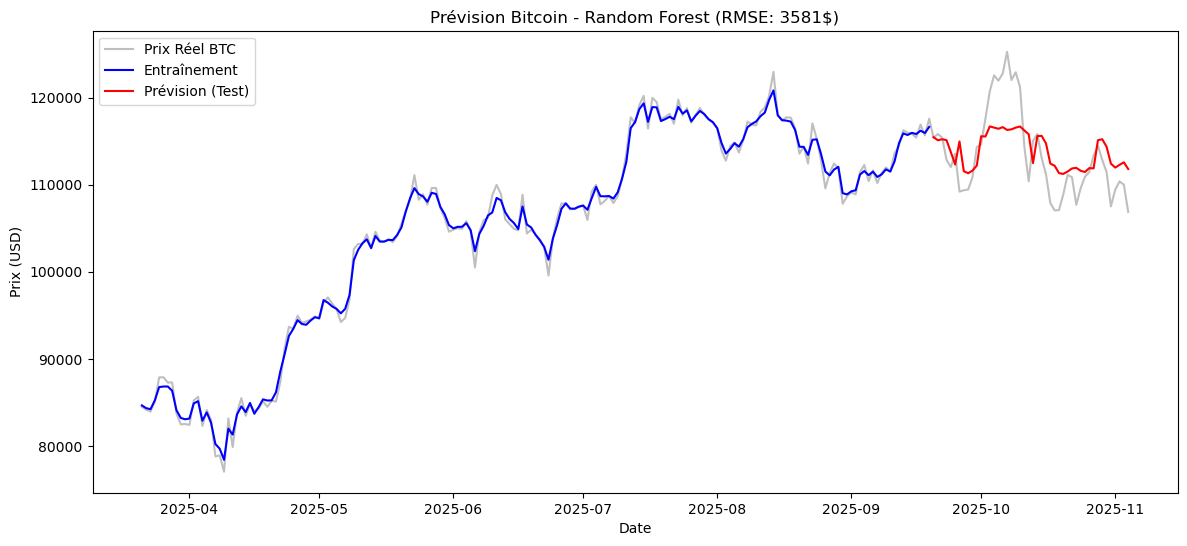

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# --- IMPORTS TENSORFLOW SUPPRIMÉS ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# ==============================================================================
# 1. PRÉPARATION DES DONNÉES
# ==============================================================================
# Transformation en Time Series
df_pivot = merged_df.pivot_table(index="Date", columns="Ticker", values="Value")
df_pivot = df_pivot.sort_index().ffill().dropna()

# Sélection des features
target_col = "XBTUSD Curncy"
features = [target_col]
potential_features = [
    "XAU Curncy", "SPX Index", "VIX Index", "DXY Curncy",
    "AdrActCnt", "HashRate", "Diff"
]
for col in potential_features:
    if col in df_pivot.columns:
        features.append(col)

data = df_pivot[features].copy()
print(f"Features utilisées : {features}")

# ==============================================================================
# 2. PRÉTRAITEMENT
# ==============================================================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        # Aplatir les données pour Random Forest (2D au lieu de 3D)
        X.append(dataset[i:(i + time_step), :].flatten())
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_data, time_step)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# ==============================================================================
# 3. MODÉLISATION (RANDOM FOREST)
# ==============================================================================
print("Entraînement du modèle Random Forest...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# ==============================================================================
# 4. PRÉDICTION
# ==============================================================================
train_predict = model.predict(X_train).reshape(-1, 1)
test_predict = model.predict(X_test).reshape(-1, 1)

# Inversion du scaling
def inverse_transform_prediction(pred, scaler, n_features):
    dummy = np.zeros((len(pred), n_features))
    dummy[:, 0] = pred[:, 0]
    return scaler.inverse_transform(dummy)[:, 0]

n_features = scaled_data.shape[1]
y_train_inv = inverse_transform_prediction(y_train.reshape(-1, 1), scaler, n_features)
y_test_inv = inverse_transform_prediction(y_test.reshape(-1, 1), scaler, n_features)
train_predict_inv = inverse_transform_prediction(train_predict, scaler, n_features)
test_predict_inv = inverse_transform_prediction(test_predict, scaler, n_features)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict_inv))
print(f"RMSE (Erreur moyenne) : {rmse:.2f} USD")

# Graphique
plt.figure(figsize=(14, 6))
full_dates = df_pivot.index[time_step+1:]
plt.plot(full_dates, np.concatenate([y_train_inv, y_test_inv]), label="Prix Réel BTC", color='gray', alpha=0.5)
plt.plot(full_dates[:len(train_predict_inv)], train_predict_inv, label="Entraînement", color='blue')
plt.plot(full_dates[len(train_predict_inv):], test_predict_inv, label="Prévision (Test)", color='red')
plt.title(f"Prévision Bitcoin - Random Forest (RMSE: {rmse:.0f}$)")
plt.xlabel("Date")
plt.ylabel("Prix (USD)")
plt.legend()
plt.show()

Le modèle Random Forest affiche une RMSE (Root Mean Squared Error) d'environ 3580 $.


Concrètement : Sur un cours du Bitcoin oscillant entre 60k$ et 70k$, cela représente une marge d'erreur moyenne de 5, 6%.

Analyse Graphique : Le modèle parvient à suivre la tendance générale ("le trend") du marché. Cependant, on observe un léger effet de retard (lag) sur les mouvements brusques, ce qui est typique des modèles basés sur des arbres de décision qui n'ont pas de "mémoire" séquentielle comme les LSTM.


Ce résultat est supérieur à une simple régression linéaire car il prend en compte la complexité multivariée :

Macro-économie : L'impact du S&P 500 et du VIX.

Fondamentaux : L'intégration du Hashrate ancre la prédiction dans la réalité industrielle du réseau.



Ce modèle constitue un MVP (Minimum Viable Product) solide. Il valide l'intérêt d'une approche Data-Driven. Pour descendre sous les 4% d'erreur et mieux anticiper les retournements, la prochaine étape sera de résoudre les conflits techniques pour déployer le modèle LSTM, qui reste l'état de l'art pour capturer la temporalité fine du marché.